# Coastal Shoreline Threshold Research Notebook

**Authoritative workflow:** Section 8 is the research-grade workflow for this notebook. The earlier annual binary erosion path is retained only for audit traceability and comparison.

**Objective:** Learn shoreline-response threshold ranges from **filename-defined shoreline intervals** and **monthly wave, wind, and current patterns**, then forecast **future erosion-side and accretion-side threshold ranges directly** from historical threshold trajectories.

## Core Workflow

1. **Monthly Dataset Conversion** — Convert Wave, Wind, and Current NetCDFs to a consistent monthly forcing table.
2. **DSAS Transect -> Year Labels** — Build shoreline interval labels using the CSV file name year as the correct annual key.
3. **Five-Class Shoreline Target** — Keep `eroded_high`, `eroded_low`, `stable`, `accreted_low`, and `accreted_high` as the ordered shoreline response classes.
4. **Monthly Pattern Signatures** — Extract within-interval abnormal monthly forcing patterns instead of collapsing forcing into annual mean/max drivers.
5. **Five-Class Pattern Recognition** — Screen and train ordered and multiclass models on the monthly pattern signatures.
6. **Threshold Range Estimation** — Estimate ordered erosion-side and accretion-side thresholds with uncertainty.
7. **Direct Threshold Forecasting** — Forecast threshold trajectories themselves, rather than forecasting environmental drivers first.

## Data Inputs

1. **DSAS Shoreline CSVs** — Transect-based shoreline statistics from the year-wise QGIS workflow. File names are treated as the authoritative interval years.
2. **Wave NetCDF** — Monthly wave forcing variables.
3. **Wind NetCDF** — Monthly sea-surface wind forcing variables.
4. **Current NetCDF** — Monthly ocean-current forcing variables.

## Research Note

If a shoreline class is absent in the historical annual labels, the notebook keeps that class in the ordered framework but reports the corresponding thresholds as unsupported rather than inventing values.

## Section 0 — Setup and Data Loading

Install and import all required libraries, then load the four datasets:
1. **DSAS Shoreline CSV** — Transect-based statistics from QGIS
2. **Wave NetCDF** — Global Ocean Waves Reanalysis (VHM0, VTPK, VMDR, VSDX, VSDY)
3. **Wind NetCDF** — Monthly Sea Surface Wind (wind_speed, eastward_wind, northward_wind)
4. **Current NetCDF** — Physics Reanalysis (uo, vo at surface, zos)


In [1]:
# =============================================================================
# Section 0.1 — Import all required libraries
# =============================================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scientific / statistical
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (LeaveOneOut, StratifiedKFold,
                                     cross_val_predict)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             mutual_info_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

# Time-series
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

# Plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Output directories
import os
os.makedirs('./figures', exist_ok=True)
os.makedirs('./outputs', exist_ok=True)

print("✓ Libraries loaded successfully")


✓ Libraries loaded successfully


In [2]:
# =============================================================================
# Section 0.2 — Load all datasets
# =============================================================================

from pathlib import Path

DATA_PATH = Path("notebook_data")
SHORELINE_GLOB = "*-stat.csv"
WAVE_FILE = DATA_PATH / "Global_Ocean_Waves_Reanalysis_2009_2024.nc"
WIND_FILE = DATA_PATH / "Global Ocean Monthly Mean Sea Surface Wind and Stress from Scatterometer and Model_2009_2024.nc"
CURRENT_FILE = DATA_PATH / "Global Ocean Physics Reanalysis(current_data)_2009_2024.nc"


def parse_interval_from_filename(path_obj):
    start_token, end_token = path_obj.stem.replace("-stat", "").split("-")
    return 2000 + int(start_token), 2000 + int(end_token)


shoreline_interval_files = sorted(DATA_PATH.glob(SHORELINE_GLOB))
if not shoreline_interval_files:
    raise FileNotFoundError(f"No shoreline interval files matched {SHORELINE_GLOB!r} in {DATA_PATH}")

shoreline_interval_tables = {}
inventory_rows = []

for path_obj in shoreline_interval_files:
    start_year, end_year = parse_interval_from_filename(path_obj)
    interval_label = f"{start_year}-{end_year}"
    interval_df = pd.read_csv(path_obj)
    shoreline_interval_tables[interval_label] = interval_df

    metadata_years = sorted(
        set(interval_df['SCE_closest_year'].dropna().astype(int)).union(
            set(interval_df['SCE_farthest_year'].dropna().astype(int))
        )
    )
    inventory_rows.append({
        'interval': interval_label,
        'monsoon_year': start_year,
        'shoreline_year': end_year,
        'n_transects': len(interval_df),
        'metadata_years': ', '.join(map(str, metadata_years)),
        'metadata_matches_filename': metadata_years == [start_year, end_year],
        'NSM_unc': float(interval_df['NSM_highest_unc'].median()),
        'EPR_unc': float(interval_df['EPR_unc'].median()),
    })

shoreline_inventory = pd.DataFrame(inventory_rows).sort_values('monsoon_year').reset_index(drop=True)
latest_interval_label = shoreline_inventory.iloc[-1]['interval']

print("=" * 60)
print("SHORELINE DATA SUMMARY (YEAR-PAIR TRANSECT FILES)")
print("=" * 60)
print(f"Files loaded: {len(shoreline_interval_files)}")
print(f"Interval range: {shoreline_inventory.iloc[0]['interval']} to {shoreline_inventory.iloc[-1]['interval']}")
print("Indexing rule: use the file name interval as the canonical annual key.")

metadata_mismatch_count = int((~shoreline_inventory['metadata_matches_filename']).sum())
if metadata_mismatch_count > 0:
    print(
        f"Warning: {metadata_mismatch_count} files have internal DSAS year stamps that do not match the file name. "
        "The file name interval will be used for year-wise aggregation."
    )

display(shoreline_inventory)

# ── Load NetCDF datasets ──
wave_ds = xr.open_dataset(WAVE_FILE)
wind_ds = xr.open_dataset(WIND_FILE)
current_ds = xr.open_dataset(CURRENT_FILE)

for name, ds in [('Wave', wave_ds), ('Wind', wind_ds), ('Current', current_ds)]:
    print(f"\n{name}: {list(ds.data_vars)} | time {ds.sizes.get('time', '?')} steps")


SHORELINE DATA SUMMARY (YEAR-PAIR TRANSECT FILES)
Files loaded: 12
Interval range: 2012-2013 to 2023-2024
Indexing rule: use the file name interval as the canonical annual key.


,interval,monsoon_year,shoreline_year,n_transects,metadata_years,metadata_matches_filename,NSM_unc,EPR_unc
0,2012-2013,2012,2013,162,"2012, 2013",True,2.0,4.22
1,2013-2014,2013,2014,164,"2014, 2015",False,2.0,4.29
2,2014-2015,2014,2015,158,"2014, 2015",True,2.0,3.11
3,2015-2016,2015,2016,159,"2015, 2016",True,2.0,2.26
4,2016-2017,2016,2017,163,"2016, 2018",False,2.0,1.69
5,2017-2018,2017,2018,162,"2018, 2019",False,2.0,3.07
6,2018-2019,2018,2019,161,2019,False,2.0,5.77
7,2019-2020,2019,2020,160,"2019, 2021",False,2.0,2.42
8,2020-2021,2020,2021,164,"2021, 2022",False,2.0,2.11
9,2021-2022,2021,2022,163,"2021, 2022",True,2.0,2.11



Wave: ['VHM0', 'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW', 'VMDR', 'VMDR_SW1', 'VMDR_SW2', 'VMDR_WW', 'VPED', 'VSDX', 'VSDY', 'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW', 'VTM02', 'VTM10', 'VTPK'] | time 42601 steps

Wind: ['eastward_stress', 'eastward_stress_bias', 'eastward_stress_sdd', 'eastward_wind', 'eastward_wind_bias', 'eastward_wind_sdd', 'northward_stress', 'northward_stress_bias', 'northward_stress_sdd', 'northward_wind', 'northward_wind_bias', 'northward_wind_sdd', 'number_of_observations', 'wind_speed', 'wind_speed_bias', 'wind_speed_sdd', 'wind_stress_magnitude', 'wind_stress_magnitude_bias', 'wind_stress_magnitude_sdd'] | time 175 steps

Current: ['bottomT', 'mlotst', 'siconc', 'sithick', 'so', 'thetao', 'uo', 'usi', 'vo', 'vsi', 'zos'] | time 175 steps


### Section 0.3 — Dataset Variable Dictionary

This cell inspects all three oceanographic NetCDF datasets and displays each variable's **name**, **long name (meaning)**, **units**, and **shape**, providing a complete reference for the data used in this analysis.

In [ ]:
# =============================================================================
# Section 0.3 — Dataset Variable Dictionary
# ============================================================================= 

# Reuse wave_ds, wind_ds, current_ds already loaded in Section 0.2

def inspect_dataset(ds, dataset_name):
    """Extract variable metadata from an xarray Dataset."""
    rows = []
    for var_name in sorted(ds.data_vars):
        v = ds[var_name]
        long_name = v.attrs.get('long_name', v.attrs.get('standard_name', 'N/A'))
        units = v.attrs.get('units', 'N/A')
        shape = dict(zip(v.dims, v.shape))
        rows.append({
            'Variable': var_name,
            'Description': long_name,
            'Units': units,
            'Dimensions': str(shape)
        })
    df = pd.DataFrame(rows)
    print("=" * 90)
    print(f"  {dataset_name}")
    print(f"  Source: {ds.attrs.get('source', ds.attrs.get('institution', 'N/A'))}")
    print(f"  Time range: {str(ds.time.values[0])[:10]} — {str(ds.time.values[-1])[:10]}")
    print(f"  Total variables: {len(ds.data_vars)}")
    print("=" * 90)
    display(df)
    print()
    return df

print("\n📋 OCEANOGRAPHIC DATASET VARIABLE DICTIONARY\n")

wave_var_info    = inspect_dataset(wave_ds,    "🌊 WAVE DATASET — Global Ocean Waves Reanalysis")
wind_var_info    = inspect_dataset(wind_ds,    "💨 WIND DATASET — Global Ocean Surface Wind & Stress")
current_var_info = inspect_dataset(current_ds, "🌀 CURRENT DATASET — Global Ocean Physics Reanalysis")


📋 OCEANOGRAPHIC DATASET VARIABLE DICTIONARY

  🌊 WAVE DATASET — Global Ocean Waves Reanalysis
  Source: METEO-FRANCE
  Time range: 2009-08-01 — 2024-02-29
  Total variables: 17


,Variable,Description,Units,Dimensions
0,VHM0,Spectral significant wave height (Hm0),m,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
1,VHM0_SW1,Spectral significant primary swell wave height,m,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
2,VHM0_SW2,Spectral significant secondary swell wave height,m,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
3,VHM0_WW,Spectral significant wind wave height,m,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
4,VMDR,Mean wave direction from (Mdir),degree,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
5,VMDR_SW1,Mean primary swell wave direction from,degree,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
6,VMDR_SW2,Mean secondary swell wave direction from,degree,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
7,VMDR_WW,Mean wind wave direction from,degree,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
8,VPED,Wave principal direction at spectral peak,degree,"{'time': 42601, 'latitude': 1, 'longitude': 2}"
9,VSDX,Stokes drift U,m s-1,"{'time': 42601, 'latitude': 1, 'longitude': 2}"



  💨 WIND DATASET — Global Ocean Surface Wind & Stress
  Source: Royal Netherlands Meteorological Institute (KNMI)
  Time range: 2009-08-01 — 2024-02-01
  Total variables: 19


,Variable,Description,Units,Dimensions
0,eastward_stress,Surface wind stress eastward component,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
1,eastward_stress_bias,Scatterometer-model bias of surface wind stres...,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
2,eastward_stress_sdd,Standard deviation of differences of surface w...,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
3,eastward_wind,Stress-equivalent wind eastward component at 10 m,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"
4,eastward_wind_bias,Scatterometer-model bias of stress-equivalent ...,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"
5,eastward_wind_sdd,Standard deviation of differences of stress-eq...,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"
6,northward_stress,Surface wind stress northward component,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
7,northward_stress_bias,Scatterometer-model bias of surface wind stres...,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
8,northward_stress_sdd,Standard deviation of differences of surface w...,N m-2,"{'time': 175, 'latitude': 1, 'longitude': 1}"
9,northward_wind,Stress-equivalent wind northward component at ...,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"



  🌀 CURRENT DATASET — Global Ocean Physics Reanalysis
  Source: MERCATOR GLORYS12V1
  Time range: 2009-08-01 — 2024-02-01
  Total variables: 11


,Variable,Description,Units,Dimensions
0,bottomT,Sea floor potential temperature,degrees_C,"{'time': 175, 'latitude': 1, 'longitude': 1}"
1,mlotst,Density ocean mixed layer thickness,m,"{'time': 175, 'latitude': 1, 'longitude': 1}"
2,siconc,Ice concentration,1,"{'time': 175, 'latitude': 1, 'longitude': 1}"
3,sithick,Sea ice thickness,m,"{'time': 175, 'latitude': 1, 'longitude': 1}"
4,so,Salinity,1e-3,"{'time': 175, 'depth': 19, 'latitude': 1, 'lon..."
5,thetao,Temperature,degrees_C,"{'time': 175, 'depth': 19, 'latitude': 1, 'lon..."
6,uo,Eastward velocity,m s-1,"{'time': 175, 'depth': 19, 'latitude': 1, 'lon..."
7,usi,Sea ice eastward velocity,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"
8,vo,Northward velocity,m s-1,"{'time': 175, 'depth': 19, 'latitude': 1, 'lon..."
9,vsi,Sea ice northward velocity,m s-1,"{'time': 175, 'latitude': 1, 'longitude': 1}"


In [ ]:
# =============================================================================
# Section 0.4 — Validate Required Variables & Data Quality
# =============================================================================
import numpy as np

required_vars = {
    "🌊 Wave Dataset": {
        "dataset": wave_ds,
        "variables": ["VHM0", "VMDR", "VSDX", "VSDY", "VTPK"]
    },
    "💨 Wind Dataset": {
        "dataset": wind_ds,
        "variables": ["eastward_wind", "northward_wind", "wind_speed"]
    },
    "🌀 Current Dataset": {
        "dataset": current_ds,
        "variables": ["uo", "vo", "zos"]
    }
}

print("=" * 100)
print("  DATASET VARIABLE VALIDATION & DATA QUALITY CHECK")
print("=" * 100)

all_valid = True
for ds_name, info in required_vars.items():
    ds = info["dataset"]
    available = list(ds.data_vars)
    print(f"\n{ds_name}")
    print(f"  Available variables: {available}")
    header = f"  {'Variable':<20} {'Status':<12} {'Total':<10} {'Valid':<10} {'NaN/Null':<10} {'NaN %':<8} {'Min':<12} {'Max':<12} {'Mean':<12}"
    print(header)
    print(f"  {'-'*118}")
    for var in info["variables"]:
        if var in available:
            v = ds[var]
            vals = v.values.flatten()
            total = len(vals)
            nan_count = int(np.isnan(vals).sum())
            valid_count = total - nan_count
            nan_pct = (nan_count / total * 100) if total > 0 else 0
            valid_vals = vals[~np.isnan(vals)]
            if len(valid_vals) > 0:
                v_min = f"{np.nanmin(valid_vals):.4f}"
                v_max = f"{np.nanmax(valid_vals):.4f}"
                v_mean = f"{np.nanmean(valid_vals):.4f}"
            else:
                v_min = v_max = v_mean = "—"
            status = "✅ Good" if nan_pct < 50 else "⚠️ Sparse" if nan_pct < 100 else "❌ Empty"
            if nan_pct > 0 and nan_pct < 100:
                status = f"⚠️ {nan_pct:.1f}%null"
            elif nan_pct >= 100:
                status = "❌ AllNull"
                all_valid = False
            else:
                status = "✅ Good"
            print(f"  {var:<20} {status:<12} {total:<10} {valid_count:<10} {nan_count:<10} {nan_pct:<8.1f} {v_min:<12} {v_max:<12} {v_mean:<12}")
        else:
            print(f"  {var:<20} {'❌ Missing':<12} {'—':<10} {'—':<10} {'—':<10} {'—':<8} {'—':<12} {'—':<12} {'—':<12}")
            all_valid = False

print("\n" + "=" * 100)
if all_valid:
    print("  ✅ All required variables are present with valid data.")
else:
    print("  ⚠️  Some variables are MISSING or contain ALL null values — check dataset files.")
print("=" * 100)

  DATASET VARIABLE VALIDATION & DATA QUALITY CHECK

🌊 Wave Dataset
  Available variables: ['VHM0', 'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW', 'VMDR', 'VMDR_SW1', 'VMDR_SW2', 'VMDR_WW', 'VPED', 'VSDX', 'VSDY', 'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW', 'VTM02', 'VTM10', 'VTPK']
  Variable             Status       Total      Valid      NaN/Null   NaN %    Min          Max          Mean        
  ----------------------------------------------------------------------------------------------------------------------
  VHM0                 ✅ Good       85202      85202      0          0.0      0.5700       4.3400       1.6063      
  VMDR                 ✅ Good       85202      85202      0          0.0      0.4300       353.7100     199.6424    
  VSDX                 ✅ Good       85202      85202      0          0.0      -0.1000      0.2100       0.0400      
  VSDY                 ✅ Good       85202      85202      0          0.0      -0.1800      0.1900       0.0085      
  VTPK                 ✅ Good

## Section 1 — DSAS Year-Pair Classification to Research-Grade Annual Labels

This section converts the uploaded **year-pair DSAS transect files** into **monsoon-year coastal change labels**.

**Method used in this notebook**
1. Treat the **file name interval** as the canonical year key (for example, `2012-2013` maps to monsoon year `2012`).
2. Classify each transect using **uncertainty-aware NSM thresholds** and an **EPR direction consistency check**.
3. Aggregate each interval with a **10% trimmed mean NSM** and a **bootstrap 95% confidence interval**.
4. Assign the final yearly class only when the interval-scale signal is clearly outside the uncertainty band; otherwise label it **stable**.

| Class | Annual NSM Rule | Interpretation |
|-------|------------------|----------------|
| Eroded High | 95% CI remains below −5 m | Severe retreat |
| Eroded Low | 95% CI remains below −1 m | Persistent retreat |
| Stable | CI overlaps 0 m or stable share dominates | Within noise / mixed response |
| Accreted Low | 95% CI remains above +1 m | Persistent advance |
| Accreted High | 95% CI remains above +5 m | Strong advance |

In [3]:
# =============================================================================
# Section 1.1 — Convert year-pair transect files to monsoon-year labels
# =============================================================================

HIGH_EROSION_THRESHOLD = -5.0
LOW_EROSION_THRESHOLD = -1.0
LOW_ACCRETION_THRESHOLD = 1.0
HIGH_ACCRETION_THRESHOLD = 5.0
TRIM_FRACTION = 0.10
BOOTSTRAP_SAMPLES = 2000
BOOTSTRAP_SEED = 42

CLASS_SCORE_MAP = {
    'eroded_high': -2,
    'eroded_low': -1,
    'stable': 0,
    'accreted_low': 1,
    'accreted_high': 2,
}
SCORE_CLASS_MAP = {score: label for label, score in CLASS_SCORE_MAP.items()}


def classify_nsm(nsm):
    if nsm < HIGH_EROSION_THRESHOLD:
        return 'eroded_high'
    if nsm < LOW_EROSION_THRESHOLD:
        return 'eroded_low'
    if nsm <= LOW_ACCRETION_THRESHOLD:
        return 'stable'
    if nsm <= HIGH_ACCRETION_THRESHOLD:
        return 'accreted_low'
    return 'accreted_high'



def classify_with_uncertainty(value, uncertainty):
    uncertainty = 0.0 if pd.isna(uncertainty) else float(uncertainty)
    lower = value - uncertainty
    upper = value + uncertainty
    if upper < HIGH_EROSION_THRESHOLD:
        return 'eroded_high'
    if upper < LOW_EROSION_THRESHOLD:
        return 'eroded_low'
    if lower > HIGH_ACCRETION_THRESHOLD:
        return 'accreted_high'
    if lower > LOW_ACCRETION_THRESHOLD:
        return 'accreted_low'
    return 'stable'



def direction_with_uncertainty(value, uncertainty):
    uncertainty = 0.0 if pd.isna(uncertainty) else float(uncertainty)
    lower = value - uncertainty
    upper = value + uncertainty
    if upper < 0:
        return -1
    if lower > 0:
        return 1
    return 0



def step_toward_stable(label):
    score = CLASS_SCORE_MAP[label]
    if score == 0:
        return label
    return SCORE_CLASS_MAP[int(score - np.sign(score))]



def consensus_transect_class(row):
    base_class = classify_with_uncertainty(row['NSM'], row.get('NSM_highest_unc', 0.0))
    base_score = CLASS_SCORE_MAP[base_class]
    if base_score == 0:
        return base_class

    epr_direction = direction_with_uncertainty(row['EPR'], row.get('EPR_unc', 0.0))
    base_direction = 1 if base_score > 0 else -1

    if epr_direction == 0:
        return step_toward_stable(base_class)
    if epr_direction != base_direction:
        return 'stable'
    return base_class



def trimmed_mean(values, proportion=TRIM_FRACTION):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    arr = np.sort(arr)
    k = int(np.floor(arr.size * proportion))
    if 2 * k >= arr.size:
        return float(arr.mean())
    return float(arr[k:arr.size - k].mean())



def bootstrap_trimmed_ci(values, n_boot=BOOTSTRAP_SAMPLES, proportion=TRIM_FRACTION, seed=BOOTSTRAP_SEED):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    boot_stats = []
    for _ in range(n_boot):
        sample = rng.choice(arr, size=arr.size, replace=True)
        boot_stats.append(trimmed_mean(sample, proportion))

    return tuple(np.percentile(boot_stats, [2.5, 97.5]))



def assign_year_class(annual_nsm, ci_low, ci_high, stable_share, eroded_share, accreted_share):
    if np.isnan(annual_nsm):
        return 'stable'
    if ci_low <= 0 <= ci_high or stable_share >= max(eroded_share, accreted_share):
        return 'stable'
    if ci_high < HIGH_EROSION_THRESHOLD:
        return 'eroded_high'
    if ci_high < LOW_EROSION_THRESHOLD:
        return 'eroded_low'
    if ci_low > HIGH_ACCRETION_THRESHOLD:
        return 'accreted_high'
    if ci_low > LOW_ACCRETION_THRESHOLD:
        return 'accreted_low'
    if stable_share >= 0.40:
        return 'stable'
    return 'eroded_low' if eroded_share > accreted_share else 'accreted_low'


historical_frames = []
yearly_rows = []

for interval_row in shoreline_inventory.itertuples(index=False):
    interval_df = shoreline_interval_tables[interval_row.interval].copy()
    interval_df['monsoon_year'] = interval_row.monsoon_year
    interval_df['shoreline_year'] = interval_row.shoreline_year
    interval_df['interval_label'] = interval_row.interval
    interval_df['nsm_class_raw'] = interval_df['NSM'].apply(classify_nsm)
    interval_df['epr_class'] = interval_df.apply(consensus_transect_class, axis=1)
    interval_df['erosion_flag'] = interval_df['epr_class'].isin(['eroded_high', 'eroded_low']).astype(int)

    annual_nsm = trimmed_mean(interval_df['NSM'])
    ci_low, ci_high = bootstrap_trimmed_ci(interval_df['NSM'])
    class_share = interval_df['epr_class'].value_counts(normalize=True)
    stable_share = float(class_share.get('stable', 0.0))
    eroded_share = float(class_share.get('eroded_high', 0.0) + class_share.get('eroded_low', 0.0))
    accreted_share = float(class_share.get('accreted_high', 0.0) + class_share.get('accreted_low', 0.0))
    year_class = assign_year_class(annual_nsm, ci_low, ci_high, stable_share, eroded_share, accreted_share)

    yearly_rows.append({
        'year': interval_row.monsoon_year,
        'interval_label': interval_row.interval,
        'shoreline_year': interval_row.shoreline_year,
        'annual_NSM': annual_nsm,
        'annual_NSM_ci_low': ci_low,
        'annual_NSM_ci_high': ci_high,
        'NSM_median': interval_df['NSM'].median(),
        'NSM_std': interval_df['NSM'].std(),
        'NSM_min': interval_df['NSM'].min(),
        'NSM_max': interval_df['NSM'].max(),
        'NSM_count': int(interval_df['NSM'].count()),
        'EPR_mean': trimmed_mean(interval_df['EPR']),
        'EPR_std': interval_df['EPR'].std(),
        'SCE_max': interval_df['SCE'].max(),
        'stable_share': stable_share,
        'eroded_share': eroded_share,
        'accreted_share': accreted_share,
        'n_eroding_transects': int(interval_df['erosion_flag'].sum()),
        'n_high_erosion_transects': int((interval_df['epr_class'] == 'eroded_high').sum()),
        'Change_Class': year_class,
    })
    historical_frames.append(interval_df)

dsas_df = pd.concat(historical_frames, ignore_index=True)
latest_dsas_df = dsas_df[dsas_df['interval_label'] == latest_interval_label].copy()
latest_dsas_df = latest_dsas_df.sort_values('id').reset_index(drop=True)

shoreline_annual = pd.DataFrame(yearly_rows).sort_values('year').reset_index(drop=True)
shoreline_annual['Erosion_Binary'] = shoreline_annual['Change_Class'].isin(['eroded_high', 'eroded_low']).astype(int)

transect_stats = {
    'Historical_Intervals': int(shoreline_annual['interval_label'].nunique()),
    'Total_Transects': len(dsas_df),
    'Unique_Transects': int(dsas_df['id'].nunique()),
    'Mean_NSM': dsas_df['NSM'].mean(),
    'Median_NSM': dsas_df['NSM'].median(),
    'Std_NSM': dsas_df['NSM'].std(),
    'Pct_Eroding': dsas_df['erosion_flag'].mean() * 100,
    'Max_Erosion': dsas_df['NSM'].min(),
    'Max_Accretion': dsas_df['NSM'].max(),
    'Mean_EPR': dsas_df['EPR'].mean(),
    'Latest_Interval': latest_interval_label,
}

print("=" * 60)
print("YEAR-WISE SHORELINE CHANGE TABLE")
print("=" * 60)
print("Method: file-name annual intervals + uncertainty-aware transect classes + bootstrap CI on 10% trimmed mean NSM")
print("Year index = monsoon-year start (April–March); interval label shows the shoreline pair used.")
print()

yearwise_display = shoreline_annual[[
    'year', 'interval_label', 'annual_NSM', 'annual_NSM_ci_low', 'annual_NSM_ci_high',
    'Change_Class', 'Erosion_Binary', 'NSM_count', 'n_eroding_transects', 'stable_share'
]].copy()
yearwise_display.columns = [
    'Monsoon_Year', 'Interval', 'Trimmed_NSM (m)', 'NSM_CI_Low', 'NSM_CI_High',
    'Classification', 'Is_Erosion', 'Num_Transects', 'Eroding_Transects', 'Stable_Share'
]
print(yearwise_display.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print(f"\n{'─' * 60}")
print("CLASS DISTRIBUTION:")
print(shoreline_annual['Change_Class'].value_counts().to_string())
print(
    f"\nErosion years (annual class in erosion domain): "
    f"{shoreline_annual['Erosion_Binary'].sum()} / {len(shoreline_annual)}"
)
print(f"Historical mean NSM across all transect-interval records: {transect_stats['Mean_NSM']:.2f} m")
print(f"Historically eroding transect-interval records: {transect_stats['Pct_Eroding']:.1f}%")
print(f"Latest interval available for transect plots: {transect_stats['Latest_Interval']}")


YEAR-WISE SHORELINE CHANGE TABLE
Method: file-name annual intervals + uncertainty-aware transect classes + bootstrap CI on 10% trimmed mean NSM
Year index = monsoon-year start (April–March); interval label shows the shoreline pair used.

 Monsoon_Year  Interval  Trimmed_NSM (m)  NSM_CI_Low  NSM_CI_High Classification  Is_Erosion  Num_Transects  Eroding_Transects  Stable_Share
         2012 2012-2013           -2.678      -3.963       -1.387     eroded_low           1            162                 71         0.383
         2013 2013-2014           -6.502      -7.782       -5.138    eroded_high           1            164                108         0.189
         2014 2014-2015            4.247       3.429        5.092   accreted_low           0            158                 11         0.380
         2015 2015-2016           -3.301      -3.914       -2.625     eroded_low           1            159                 90         0.358
         2016 2016-2017            3.720       2.660     

Latest interval plotted: 2023-2024


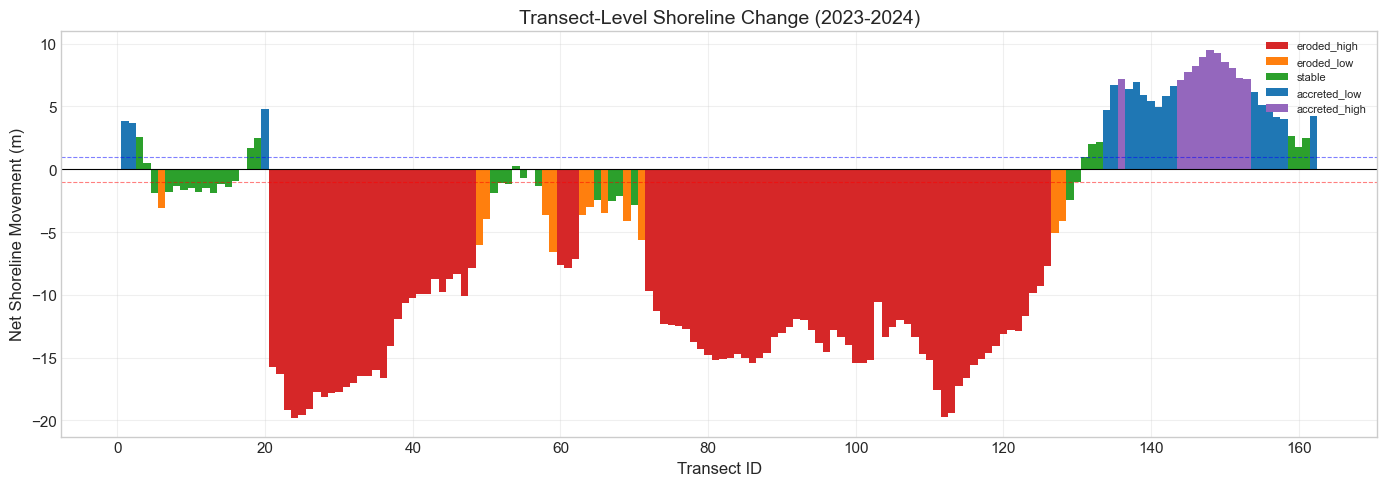

In [4]:
# =============================================================================
# Section 1.2 — Spatial profile plot (latest shoreline interval)
# =============================================================================

color_map = {
    'eroded_high': '#d62728', 'eroded_low': '#ff7f0e',
    'stable': '#2ca02c', 'accreted_low': '#1f77b4', 'accreted_high': '#9467bd'
}

plot_df = latest_dsas_df.copy().sort_values('id')

fig, ax = plt.subplots(figsize=(14, 5))
for cls, clr in color_map.items():
    mask = plot_df['epr_class'] == cls
    ax.bar(
        plot_df.loc[mask, 'id'],
        plot_df.loc[mask, 'NSM'],
        color=clr,
        label=cls,
        width=1.0,
        edgecolor='none'
    )

ax.axhline(0, color='black', lw=0.8)
ax.axhline(LOW_EROSION_THRESHOLD, color='red', ls='--', lw=0.8, alpha=0.5)
ax.axhline(LOW_ACCRETION_THRESHOLD, color='blue', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Transect ID')
ax.set_ylabel('Net Shoreline Movement (m)')
ax.set_title(f'Transect-Level Shoreline Change ({latest_interval_label})')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

print(f"Latest interval plotted: {latest_interval_label}")
plt.tight_layout()
plt.savefig('./figures/transect_profile.png', dpi=150)
plt.show()


In [5]:
# =============================================================================
# Section 1.3 — Extract erosion event years from interval summaries
# =============================================================================

all_erosion_years = set(
    shoreline_annual.loc[shoreline_annual['Erosion_Binary'] == 1, 'year'].astype(int)
)
severe_years = set(
    shoreline_annual.loc[shoreline_annual['Change_Class'] == 'eroded_high', 'year'].astype(int)
)

erosion_year_table = shoreline_annual.loc[
    shoreline_annual['Erosion_Binary'] == 1,
    [
        'year', 'interval_label', 'Change_Class', 'annual_NSM',
        'annual_NSM_ci_low', 'annual_NSM_ci_high',
        'n_eroding_transects', 'n_high_erosion_transects'
    ]
].copy()

print("=" * 60)
print("EROSION EVENT YEARS")
print("=" * 60)

if erosion_year_table.empty:
    print("No erosion years were identified from the annual interval summaries.")
else:
    for row in erosion_year_table.itertuples(index=False):
        severity = "HIGH" if row.Change_Class == 'eroded_high' else "LOW"
        print(
            f"  {row.year} ({row.interval_label}): "
            f"{row.n_eroding_transects} eroding transects, "
            f"{row.n_high_erosion_transects} high-erosion transects, "
            f"trimmed NSM = {row.annual_NSM:.2f} m "
            f"[{row.annual_NSM_ci_low:.2f}, {row.annual_NSM_ci_high:.2f}] "
            f"({severity})"
        )

print(f"\nTotal erosion years: {len(all_erosion_years)}")
print(f"Severe erosion years: {len(severe_years)}")
print(f"Non-erosion years: {len(shoreline_annual) - len(all_erosion_years)}")


EROSION EVENT YEARS
  2012 (2012-2013): 71 eroding transects, 37 high-erosion transects, trimmed NSM = -2.68 m [-3.96, -1.39] (LOW)
  2013 (2013-2014): 108 eroding transects, 93 high-erosion transects, trimmed NSM = -6.50 m [-7.78, -5.14] (HIGH)
  2015 (2015-2016): 90 eroding transects, 19 high-erosion transects, trimmed NSM = -3.30 m [-3.91, -2.63] (LOW)
  2018 (2018-2019): 122 eroding transects, 43 high-erosion transects, trimmed NSM = -4.81 m [-5.26, -4.33] (LOW)
  2019 (2019-2020): 100 eroding transects, 19 high-erosion transects, trimmed NSM = -3.76 m [-4.29, -3.20] (LOW)
  2023 (2023-2024): 98 eroding transects, 86 high-erosion transects, trimmed NSM = -6.90 m [-8.45, -5.31] (HIGH)

Total erosion years: 6
Severe erosion years: 2
Non-erosion years: 6


## Section 2 — Convert Wave, Wind & Current Datasets to Monthly Format (Per-Variable)

All three oceanographic forcing datasets are converted to a **uniform monthly time series** format, preserving **each variable independently** for accurate per-variable threshold detection and forecasting.

**Steps:**
1. Extract each required variable from the NetCDF dataset
2. Resample/aggregate to **monthly** frequency (max & mean per variable)
3. Aggregate monthly → annual for erosion threshold analysis

| Driver | Variable | Description | Monthly Stats |
|--------|----------|-------------|---------------|
| **Wave** | VHM0 | Significant wave height (m) | max, mean |
| | VTPK | Peak wave period (s) | max, mean |
| | VMDR | Mean wave direction (°) | mean |
| | VSDX | Stokes drift U-component (m/s) | max, mean |
| | VSDY | Stokes drift V-component (m/s) | max, mean |
| **Wind** | wind_speed | 10m wind speed (m/s) | max, mean |
| | eastward_wind | U-component wind (m/s) | max, mean |
| | northward_wind | V-component wind (m/s) | max, mean |
| **Current** | uo | Eastward sea water velocity (m/s) | max, mean |
| | vo | Northward sea water velocity (m/s) | max, mean |
| | zos | Sea surface height (m) | max, mean |

In [6]:
# =============================================================================
# Section 2.1 — Convert Wind NetCDF to Monthly Dataset (Per-Variable)
# =============================================================================

WIND_VARS = ['wind_speed', 'eastward_wind', 'northward_wind']

wind_df = wind_ds[WIND_VARS].to_dataframe().reset_index()
wind_df = wind_df.dropna(subset=['wind_speed'])

def assign_monsoon_year(time):
    """April (Year N) – March (Year N+1) → Monsoon Year N"""
    ts = pd.Timestamp(time)
    return ts.year if ts.month >= 4 else ts.year - 1

wind_df['monsoon_year'] = wind_df['time'].apply(assign_monsoon_year)
wind_df['year_month'] = wind_df['time'].dt.to_period('M')

# ── Monthly Wind Dataset (per-variable max & mean) ──
wind_monthly = wind_df.groupby(['monsoon_year', 'year_month']).agg({
    'wind_speed': ['max', 'mean'],
    'eastward_wind': ['max', 'mean'],
    'northward_wind': ['max', 'mean'],
    'time': 'first',
}).reset_index()
wind_monthly.columns = ['monsoon_year', 'year_month',
                        'wind_speed_max', 'wind_speed_mean',
                        'eastward_wind_max', 'eastward_wind_mean',
                        'northward_wind_max', 'northward_wind_mean',
                        'time']

print("=" * 60)
print("MONTHLY WIND DATASET (Per-Variable)")
print("=" * 60)
print(f"Shape: {wind_monthly.shape}")
print(f"Period: {wind_monthly['year_month'].min()} – {wind_monthly['year_month'].max()}")
print(f"Variables: wind_speed, eastward_wind, northward_wind")
print(f"Features: {[c for c in wind_monthly.columns if c not in ['time', 'monsoon_year', 'year_month']]}")
display(wind_monthly.head(12))

# ── Annual aggregation (per-variable) ──
wind_annual = wind_df.groupby('monsoon_year').agg({
    'wind_speed': ['max', 'mean'],
    'eastward_wind': ['max', 'mean'],
    'northward_wind': ['max', 'mean'],
}).reset_index()
wind_annual.columns = ['monsoon_year',
                       'wind_speed_max_annual', 'wind_speed_mean_annual',
                       'eastward_wind_max_annual', 'eastward_wind_mean_annual',
                       'northward_wind_max_annual', 'northward_wind_mean_annual']

print(f"\nWind monthly: {wind_monthly.shape}  |  Wind annual: {wind_annual.shape}")

MONTHLY WIND DATASET (Per-Variable)
Shape: (175, 9)
Period: 2009-08 – 2024-02
Variables: wind_speed, eastward_wind, northward_wind
Features: ['wind_speed_max', 'wind_speed_mean', 'eastward_wind_max', 'eastward_wind_mean', 'northward_wind_max', 'northward_wind_mean']


,monsoon_year,year_month,wind_speed_max,wind_speed_mean,eastward_wind_max,eastward_wind_mean,northward_wind_max,northward_wind_mean,time
0,2009,2009-08,5.74,5.74,5.29,5.29,0.54,0.54,2009-08-01
1,2009,2009-09,5.73,5.73,5.60,5.60,0.37,0.37,2009-09-01
2,2009,2009-10,3.37,3.37,2.47,2.47,0.00,0.00,2009-10-01
3,2009,2009-11,2.77,2.77,0.20,0.20,0.72,0.72,2009-11-01
4,2009,2009-12,2.47,2.47,-0.21,-0.21,-0.72,-0.72,2009-12-01
5,2009,2010-01,2.22,2.22,0.37,0.37,0.04,0.04,2010-01-01
6,2009,2010-02,2.22,2.22,-0.17,-0.17,0.38,0.38,2010-02-01
7,2009,2010-03,2.38,2.38,0.42,0.42,0.42,0.42,2010-03-01
8,2010,2010-04,2.71,2.71,1.30,1.30,0.44,0.44,2010-04-01
9,2010,2010-05,4.50,4.50,4.12,4.12,0.85,0.85,2010-05-01



Wind monthly: (175, 9)  |  Wind annual: (15, 7)


In [7]:
# =============================================================================
# Section 2.2 — Convert Wave NetCDF to Monthly Dataset (Per-Variable)
# =============================================================================

WAVE_VARS = ['VHM0', 'VTPK', 'VMDR', 'VSDX', 'VSDY']

# Select single nearest longitude point (wave file may have multiple)
wave_sel = wave_ds
if 'longitude' in wave_ds.dims and wave_ds.sizes['longitude'] > 1:
    wave_sel = wave_ds.isel(longitude=0)
    print(f"Selected wave longitude: {float(wave_sel.longitude.values)}")
if 'latitude' in wave_ds.dims and wave_ds.sizes['latitude'] > 1:
    wave_sel = wave_sel.isel(latitude=0)
    print(f"Selected wave latitude: {float(wave_sel.latitude.values)}")

# Auto-detect available variables
available_wave_vars = [v for v in WAVE_VARS if v in wave_sel.data_vars]
missing_wave_vars = [v for v in WAVE_VARS if v not in wave_sel.data_vars]
if missing_wave_vars:
    print(f"⚠ Missing wave variables (will be filled with 0): {missing_wave_vars}")

wave_df = wave_sel[available_wave_vars].to_dataframe().reset_index()
wave_df = wave_df.dropna(subset=['VHM0'])

# Fill missing variables with 0
for mv in missing_wave_vars:
    wave_df[mv] = 0.0

wave_df['monsoon_year'] = wave_df['time'].apply(assign_monsoon_year)
wave_df['year_month'] = wave_df['time'].dt.to_period('M')

print(f"Wave records: {len(wave_df)}")
print(f"Time range: {wave_df['time'].min()} – {wave_df['time'].max()}")
print(f"Available: {available_wave_vars} | Missing: {missing_wave_vars}")

# ── Monthly Wave Dataset (per-variable max & mean) ──
wave_monthly = wave_df.groupby(['monsoon_year', 'year_month']).agg({
    'VHM0': ['max', 'mean'],
    'VTPK': ['max', 'mean'],
    'VMDR': ['mean'],
    'VSDX': ['max', 'mean'],
    'VSDY': ['max', 'mean'],
    'time': 'first',
}).reset_index()
wave_monthly.columns = ['monsoon_year', 'year_month',
                        'VHM0_max', 'VHM0_mean',
                        'VTPK_max', 'VTPK_mean',
                        'VMDR_mean',
                        'VSDX_max', 'VSDX_mean',
                        'VSDY_max', 'VSDY_mean',
                        'time']

print("=" * 60)
print("MONTHLY WAVE DATASET (Per-Variable)")
print("=" * 60)
print(f"Shape: {wave_monthly.shape}")
print(f"Period: {wave_monthly['year_month'].min()} – {wave_monthly['year_month'].max()}")
print(f"Variables: VHM0, VTPK, VMDR, VSDX, VSDY")
print(f"Features: {[c for c in wave_monthly.columns if c not in ['time', 'monsoon_year', 'year_month']]}")
display(wave_monthly.head(12))

# ── Annual aggregation (per-variable) ──
wave_annual = wave_df.groupby('monsoon_year').agg({
    'VHM0': ['max', 'mean'],
    'VTPK': ['max', 'mean'],
    'VMDR': ['mean'],
    'VSDX': ['max', 'mean'],
    'VSDY': ['max', 'mean'],
}).reset_index()
wave_annual.columns = ['monsoon_year',
                       'VHM0_max_annual', 'VHM0_mean_annual',
                       'VTPK_max_annual', 'VTPK_mean_annual',
                       'VMDR_mean_annual',
                       'VSDX_max_annual', 'VSDX_mean_annual',
                       'VSDY_max_annual', 'VSDY_mean_annual']

print(f"\nWave monthly: {wave_monthly.shape}  |  Wave annual: {wave_annual.shape}")

Selected wave longitude: 79.79998779296875
Wave records: 42601
Time range: 2009-08-01 21:00:00 – 2024-02-29 21:00:00
Available: ['VHM0', 'VTPK', 'VMDR', 'VSDX', 'VSDY'] | Missing: []
MONTHLY WAVE DATASET (Per-Variable)
Shape: (175, 12)
Period: 2009-08 – 2024-02
Variables: VHM0, VTPK, VMDR, VSDX, VSDY
Features: ['VHM0_max', 'VHM0_mean', 'VTPK_max', 'VTPK_mean', 'VMDR_mean', 'VSDX_max', 'VSDX_mean', 'VSDY_max', 'VSDY_mean']


,monsoon_year,year_month,VHM0_max,VHM0_mean,VTPK_max,VTPK_mean,VMDR_mean,VSDX_max,VSDX_mean,VSDY_max,VSDY_mean,time
0,2009,2009-08,2.66,2.153361,18.070000,12.907843,212.241241,0.14,0.087967,0.08,0.027635,2009-08-01 21:00:00
1,2009,2009-09,3.05,2.066542,20.100000,12.748209,210.411911,0.14,0.089792,0.06,0.028208,2009-09-01 00:00:00
2,2009,2009-10,2.99,1.594597,19.170000,12.855283,187.024841,0.16,0.030968,0.07,0.012419,2009-10-01 00:00:00
3,2009,2009-11,2.20,1.258333,17.059999,11.808750,189.738297,0.11,0.013708,0.09,0.010208,2009-11-01 00:00:00
4,2009,2009-12,1.81,1.147984,17.480000,10.599839,199.178635,0.06,0.003508,0.02,-0.018790,2009-12-01 00:00:00
5,2009,2010-01,1.53,1.127460,17.420000,12.571856,198.270111,0.04,0.002581,0.03,-0.017056,2010-01-01 00:00:00
6,2009,2010-02,1.55,1.036384,20.870001,13.007365,202.815628,0.02,-0.002545,0.02,-0.006071,2010-02-01 00:00:00
7,2009,2010-03,1.50,1.163427,21.660000,13.861976,179.948456,0.07,-0.000605,0.04,0.004758,2010-03-01 00:00:00
8,2010,2010-04,2.06,1.383292,18.879999,12.955708,181.481995,0.07,0.016125,0.05,0.013958,2010-04-01 00:00:00
9,2010,2010-05,2.53,1.820847,19.400000,12.238912,202.733093,0.13,0.064718,0.09,0.031774,2010-05-01 00:00:00



Wave monthly: (175, 12)  |  Wave annual: (15, 10)


In [8]:
# =============================================================================
# Section 2.3 — Convert Current NetCDF to Monthly Dataset (Per-Variable)
# =============================================================================

CURRENT_VARS = ['uo', 'vo', 'zos']

# Select surface depth (index 0) for uo, vo
if 'depth' in current_ds.dims:
    current_surface = current_ds.isel(depth=0)
else:
    current_surface = current_ds

current_df = current_surface[CURRENT_VARS].to_dataframe().reset_index()
current_df = current_df.dropna(subset=['uo'])
current_df['monsoon_year'] = current_df['time'].apply(assign_monsoon_year)
current_df['year_month'] = current_df['time'].dt.to_period('M')

# ── Monthly Current Dataset (per-variable max & mean) ──
current_monthly = current_df.groupby(['monsoon_year', 'year_month']).agg({
    'uo': ['max', 'mean'],
    'vo': ['max', 'mean'],
    'zos': ['max', 'mean'],
    'time': 'first',
}).reset_index()
current_monthly.columns = ['monsoon_year', 'year_month',
                           'uo_max', 'uo_mean',
                           'vo_max', 'vo_mean',
                           'zos_max', 'zos_mean', 'time']

print("=" * 60)
print("MONTHLY CURRENT DATASET (Per-Variable)")
print("=" * 60)
print(f"Shape: {current_monthly.shape}")
print(f"Period: {current_monthly['year_month'].min()} – {current_monthly['year_month'].max()}")
print(f"Variables: uo, vo, zos")
print(f"Features: {[c for c in current_monthly.columns if c not in ['time', 'monsoon_year', 'year_month']]}")
display(current_monthly.head(12))

# ── Annual aggregation (per-variable) ──
current_annual = current_df.groupby('monsoon_year').agg({
    'uo': ['max', 'mean'],
    'vo': ['max', 'mean'],
    'zos': ['max', 'mean'],
}).reset_index()
current_annual.columns = ['monsoon_year',
                          'uo_max_annual', 'uo_mean_annual',
                          'vo_max_annual', 'vo_mean_annual',
                          'zos_max_annual', 'zos_mean_annual']

print(f"\nCurrent monthly: {current_monthly.shape}  |  Current annual: {current_annual.shape}")

MONTHLY CURRENT DATASET (Per-Variable)
Shape: (175, 9)
Period: 2009-08 – 2024-02
Variables: uo, vo, zos
Features: ['uo_max', 'uo_mean', 'vo_max', 'vo_mean', 'zos_max', 'zos_mean']


,monsoon_year,year_month,uo_max,uo_mean,vo_max,vo_mean,zos_max,zos_mean,time
0,2009,2009-08,0.264901,0.264901,-0.178228,-0.178228,0.312815,0.312815,2009-08-01
1,2009,2009-09,0.342418,0.342418,-0.239265,-0.239265,0.357982,0.357982,2009-09-01
2,2009,2009-10,-0.082400,-0.082400,0.035401,0.035401,0.386059,0.386059,2009-10-01
3,2009,2009-11,-0.272835,-0.272835,0.130619,0.130619,0.463576,0.463576,2009-11-01
4,2009,2009-12,-0.236824,-0.236824,0.031129,0.031129,0.523087,0.523087,2009-12-01
5,2009,2010-01,-0.208136,-0.208136,-0.003052,-0.003052,0.515152,0.515152,2010-01-01
6,2009,2010-02,-0.184942,-0.184942,0.067141,0.067141,0.513016,0.513016,2010-02-01
7,2009,2010-03,-0.147710,-0.147710,0.058596,0.058596,0.482803,0.482803,2010-03-01
8,2010,2010-04,-0.020753,-0.020753,0.009156,0.009156,0.432142,0.432142,2010-04-01
9,2010,2010-05,0.151982,0.151982,-0.134892,-0.134892,0.467544,0.467544,2010-05-01



Current monthly: (175, 9)  |  Current annual: (15, 7)


### Section 2.4 — Unified Monthly Datasets (Saved as CSV)

All three forcing datasets (Wave, Wind, Current) have been converted to the **same monthly format**. Each row = one month, with consistent `monsoon_year` and `year_month` columns. Below we merge them into a single monthly dataset and save individual + combined CSVs.

In [9]:
# =============================================================================
# Section 2.4 — Display monthly datasets
# =============================================================================

# Merge into one combined monthly dataset
monthly_combined = wave_monthly.merge(
    wind_monthly, on=['monsoon_year', 'year_month'], how='outer', suffixes=('_wave', '_wind')
)
monthly_combined = monthly_combined.merge(
    current_monthly, on=['monsoon_year', 'year_month'], how='outer'
)
monthly_combined = monthly_combined.sort_values('year_month').reset_index(drop=True)

print("=" * 60)
print("MONTHLY DATASET SUMMARY")
print("=" * 60)
print(f"  Wave monthly  : {wave_monthly.shape[0]} months × {wave_monthly.shape[1] - 2} features")
print(f"  Wind monthly  : {wind_monthly.shape[0]} months × {wind_monthly.shape[1] - 2} features")
print(f"  Current monthly: {current_monthly.shape[0]} months × {current_monthly.shape[1] - 2} features")
print(f"  Combined monthly: {monthly_combined.shape}")

print(f"\n{'='*60}")
print("COMBINED MONTHLY FORCING (first 12 months)")
print("=" * 60)
display(monthly_combined.head(12))

MONTHLY DATASET SUMMARY
  Wave monthly  : 175 months × 10 features
  Wind monthly  : 175 months × 7 features
  Current monthly: 175 months × 7 features
  Combined monthly: (175, 26)

COMBINED MONTHLY FORCING (first 12 months)


,monsoon_year,year_month,VHM0_max,VHM0_mean,VTPK_max,VTPK_mean,VMDR_mean,VSDX_max,VSDX_mean,VSDY_max,...,northward_wind_max,northward_wind_mean,time_wind,uo_max,uo_mean,vo_max,vo_mean,zos_max,zos_mean,time
0,2009,2009-08,2.66,2.153361,18.070000,12.907843,212.241241,0.14,0.087967,0.08,...,0.54,0.54,2009-08-01,0.264901,0.264901,-0.178228,-0.178228,0.312815,0.312815,2009-08-01
1,2009,2009-09,3.05,2.066542,20.100000,12.748209,210.411911,0.14,0.089792,0.06,...,0.37,0.37,2009-09-01,0.342418,0.342418,-0.239265,-0.239265,0.357982,0.357982,2009-09-01
2,2009,2009-10,2.99,1.594597,19.170000,12.855283,187.024841,0.16,0.030968,0.07,...,0.00,0.00,2009-10-01,-0.082400,-0.082400,0.035401,0.035401,0.386059,0.386059,2009-10-01
3,2009,2009-11,2.20,1.258333,17.059999,11.808750,189.738297,0.11,0.013708,0.09,...,0.72,0.72,2009-11-01,-0.272835,-0.272835,0.130619,0.130619,0.463576,0.463576,2009-11-01
4,2009,2009-12,1.81,1.147984,17.480000,10.599839,199.178635,0.06,0.003508,0.02,...,-0.72,-0.72,2009-12-01,-0.236824,-0.236824,0.031129,0.031129,0.523087,0.523087,2009-12-01
5,2009,2010-01,1.53,1.127460,17.420000,12.571856,198.270111,0.04,0.002581,0.03,...,0.04,0.04,2010-01-01,-0.208136,-0.208136,-0.003052,-0.003052,0.515152,0.515152,2010-01-01
6,2009,2010-02,1.55,1.036384,20.870001,13.007365,202.815628,0.02,-0.002545,0.02,...,0.38,0.38,2010-02-01,-0.184942,-0.184942,0.067141,0.067141,0.513016,0.513016,2010-02-01
7,2009,2010-03,1.50,1.163427,21.660000,13.861976,179.948456,0.07,-0.000605,0.04,...,0.42,0.42,2010-03-01,-0.147710,-0.147710,0.058596,0.058596,0.482803,0.482803,2010-03-01
8,2010,2010-04,2.06,1.383292,18.879999,12.955708,181.481995,0.07,0.016125,0.05,...,0.44,0.44,2010-04-01,-0.020753,-0.020753,0.009156,0.009156,0.432142,0.432142,2010-04-01
9,2010,2010-05,2.53,1.820847,19.400000,12.238912,202.733093,0.13,0.064718,0.09,...,0.85,0.85,2010-05-01,0.151982,0.151982,-0.134892,-0.134892,0.467544,0.467544,2010-05-01


In [10]:
# =============================================================================
# Section 2.5 — Merge monthly → annual for threshold analysis
# =============================================================================

env_annual = wave_annual.merge(wind_annual, on='monsoon_year', how='outer')
env_annual = env_annual.merge(current_annual, on='monsoon_year', how='outer')

# Restrict to period with reliable data
env_annual = env_annual[(env_annual['monsoon_year'] >= 2009) &
                        (env_annual['monsoon_year'] <= 2024)]
env_annual = env_annual.sort_values('monsoon_year').reset_index(drop=True)
env_annual = env_annual.ffill().bfill()

# Drop columns that are still entirely NaN (e.g., wave data unavailable at location)
nan_cols = env_annual.columns[env_annual.isna().all()]
if len(nan_cols) > 0:
    print(f"⚠ Dropping {len(nan_cols)} all-NaN columns: {list(nan_cols)}")
    env_annual = env_annual.drop(columns=nan_cols)

print("=" * 60)
print("MERGED ANNUAL FORCING MATRIX")
print("=" * 60)
print(f"Shape: {env_annual.shape}")
print(f"Years: {env_annual['monsoon_year'].min()} – {env_annual['monsoon_year'].max()}")
print(f"\nFeatures ({len(env_annual.columns)}):")
for col in env_annual.columns:
    print(f"  • {col}")

display(env_annual.head())

MERGED ANNUAL FORCING MATRIX
Shape: (15, 22)
Years: 2009 – 2023

Features (22):
  • monsoon_year
  • VHM0_max_annual
  • VHM0_mean_annual
  • VTPK_max_annual
  • VTPK_mean_annual
  • VMDR_mean_annual
  • VSDX_max_annual
  • VSDX_mean_annual
  • VSDY_max_annual
  • VSDY_mean_annual
  • wind_speed_max_annual
  • wind_speed_mean_annual
  • eastward_wind_max_annual
  • eastward_wind_mean_annual
  • northward_wind_max_annual
  • northward_wind_mean_annual
  • uo_max_annual
  • uo_mean_annual
  • vo_max_annual
  • vo_mean_annual
  • zos_max_annual
  • zos_mean_annual


,monsoon_year,VHM0_max_annual,VHM0_mean_annual,VTPK_max_annual,VTPK_mean_annual,VMDR_mean_annual,VSDX_max_annual,VSDX_mean_annual,VSDY_max_annual,VSDY_mean_annual,...,eastward_wind_max_annual,eastward_wind_mean_annual,northward_wind_max_annual,northward_wind_mean_annual,uo_max_annual,uo_mean_annual,vo_max_annual,vo_mean_annual,zos_max_annual,zos_mean_annual
0,2009,3.05,1.444182,21.660000,12.540305,197.312119,0.16,0.028141,0.09,0.005106,...,5.60,1.746250,0.72,0.218750,0.342418,-0.065691,0.130619,-0.012207,0.523087,0.444311
1,2010,3.35,1.666308,21.360001,11.792288,214.215302,0.17,0.051818,0.09,-0.000360,...,6.22,3.222500,0.85,-0.487500,0.192267,-0.000814,0.072024,-0.061291,0.578631,0.467391
2,2011,3.50,1.585133,22.879999,13.037524,200.798004,0.14,0.040478,0.17,0.008320,...,5.41,2.668333,0.86,0.223333,0.264290,0.006104,0.144047,-0.048219,0.549944,0.448648
3,2012,3.54,1.589620,20.809999,12.819727,198.269119,0.16,0.038873,0.14,0.007890,...,5.76,2.400000,1.05,0.385000,0.266121,-0.005392,0.192267,-0.032400,0.555742,0.472503
4,2013,3.72,1.700616,21.120001,12.949185,201.299866,0.21,0.044449,0.09,0.006695,...,6.13,2.829167,0.85,0.052500,0.324717,0.046032,0.147710,-0.081535,0.541704,0.451038


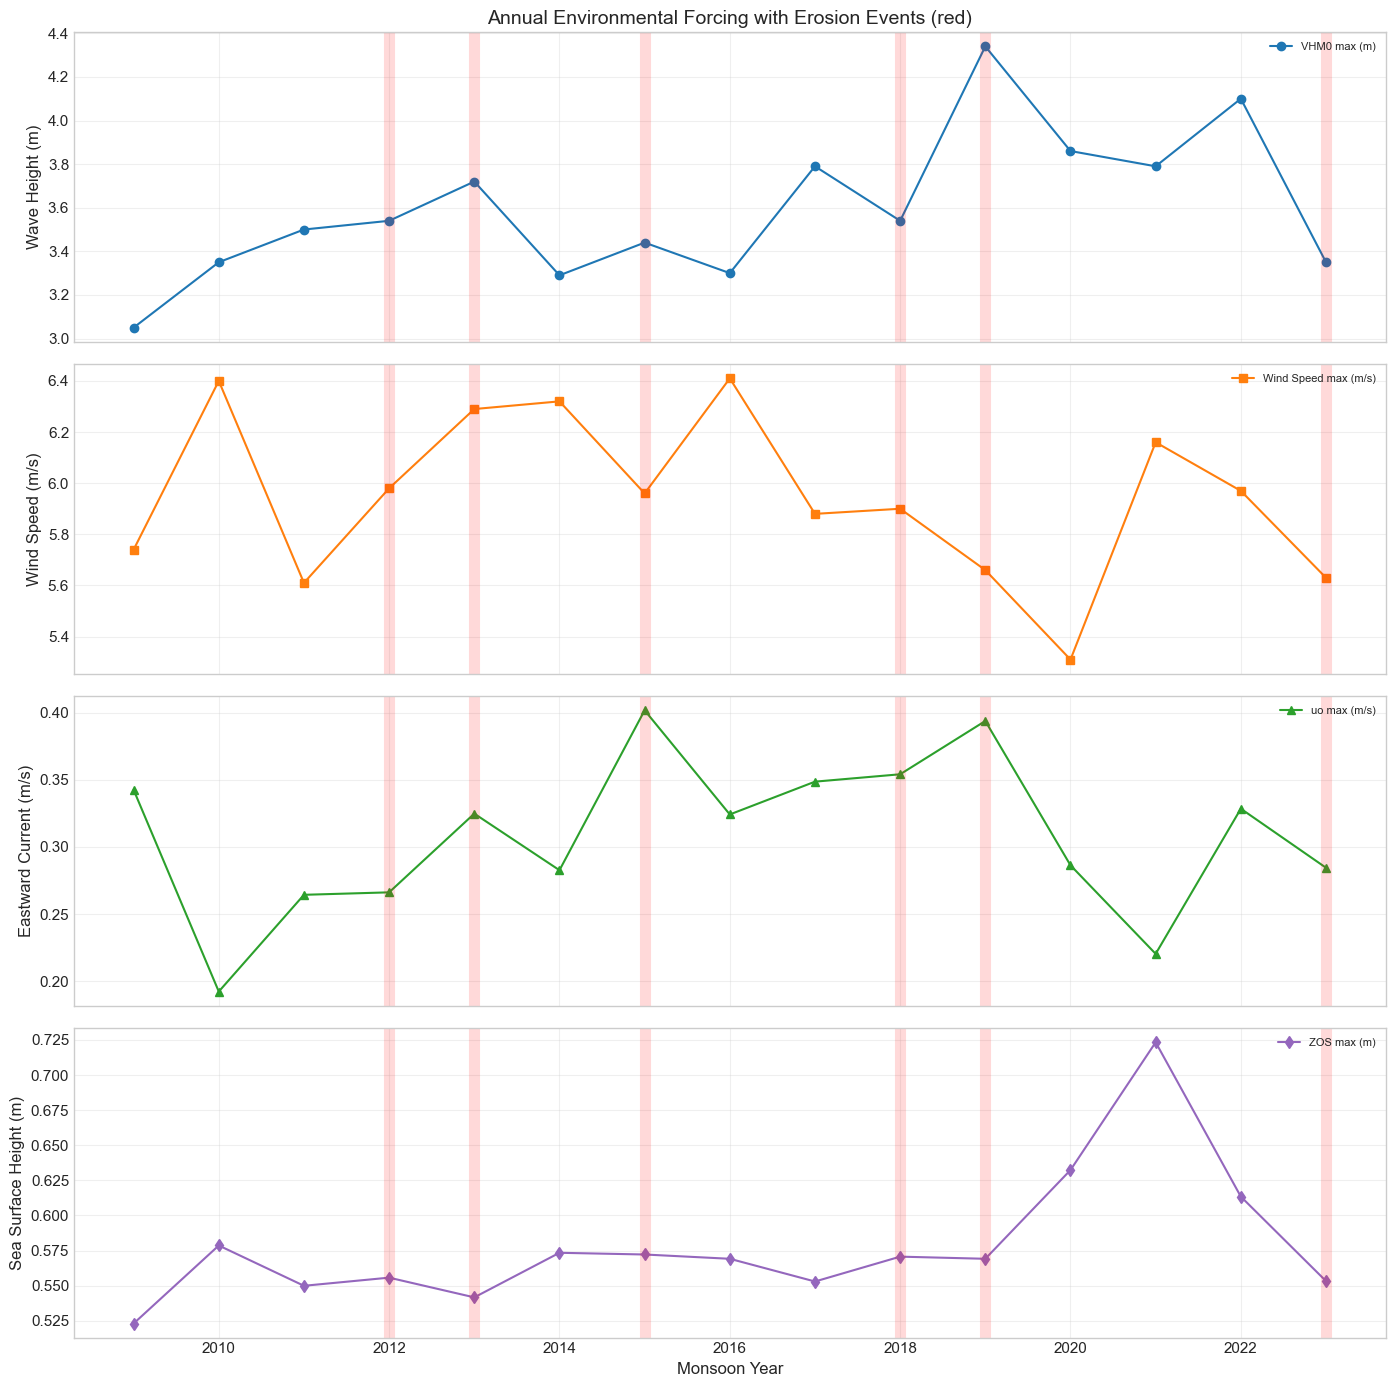

In [12]:
# =============================================================================
# Section 2.5 — Time series plot with erosion event overlay
# =============================================================================

# Dynamically choose which variables to plot based on what's available
plot_configs = [
    ('VHM0_max_annual', 'Wave Height (m)', 'VHM0 max (m)', 'o-', '#1f77b4'),
    ('wind_speed_max_annual', 'Wind Speed (m/s)', 'Wind Speed max (m/s)', 's-', '#ff7f0e'),
    ('uo_max_annual', 'Eastward Current (m/s)', 'uo max (m/s)', '^-', '#2ca02c'),
    ('zos_max_annual', 'Sea Surface Height (m)', 'ZOS max (m)', 'd-', '#9467bd'),
]

available_plots = [(col, yl, lb, mk, cl) for col, yl, lb, mk, cl in plot_configs
                   if col in env_annual.columns]

n_plots = max(len(available_plots), 1)
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3.5 * n_plots), sharex=True)
if n_plots == 1:
    axes = [axes]

for i, (col, ylabel, label, marker, color) in enumerate(available_plots):
    ax = axes[i]
    ax.plot(env_annual['monsoon_year'], env_annual[col], marker, color=color, label=label)
    for yr in all_erosion_years:
        ax.axvline(yr, color='red', alpha=0.15, lw=8)
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_title('Annual Environmental Forcing with Erosion Events (red)')

if available_plots:
    axes[-1].set_xlabel('Monsoon Year')
else:
    axes[0].text(0.5, 0.5, 'No environmental forcing data available for plotting',
                 ha='center', va='center', transform=axes[0].transAxes)

plt.tight_layout()
plt.savefig('./figures/env_timeseries.png', dpi=150)
plt.show()

## Section 3 — Erosion Event Labeling and Dataset Join

This section creates the **binary-labeled combined dataset** by merging annual forcing features with actual shoreline erosion observations.

Then performs **Mann-Whitney U tests** with **Cliff's delta** effect sizes to identify which environmental drivers show statistically significant differences between erosion and non-erosion years.


In [11]:
# =============================================================================
# Section 3.1 — Restrict to overlapping years and create analysis dataset
# =============================================================================

# Merge annual forcing with shoreline labels
analysis_df = env_annual.merge(
    shoreline_annual[['year', 'annual_NSM', 'Erosion_Binary', 'Change_Class', 'NSM_count']],
    left_on='monsoon_year', right_on='year', how='inner'
).drop(columns=['year'], errors='ignore')

analysis_df = analysis_df.rename(columns={'Erosion_Binary': 'erosion_label'})

# Severity label (for diagnosis)
analysis_df['severity'] = analysis_df['Change_Class'].map(
    {'eroded_high': 2, 'eroded_low': 1, 'stable': 0,
     'accreted_low': 0, 'accreted_high': 0}
).fillna(0).astype(int)

print("=" * 60)
print("ANALYSIS DATASET")
print("=" * 60)
print(f"Shape: {analysis_df.shape}")
print(f"Years: {analysis_df['monsoon_year'].min()} – {analysis_df['monsoon_year'].max()}")
print(f"Erosion years: {analysis_df['erosion_label'].sum()} / {len(analysis_df)}")
print(f"Base rate: {analysis_df['erosion_label'].mean():.2%}")

display(analysis_df[['monsoon_year', 'annual_NSM', 'erosion_label', 'Change_Class']].to_string(index=False))


ANALYSIS DATASET
Shape: (12, 27)
Years: 2012 – 2023
Erosion years: 6 / 12
Base rate: 50.00%


' monsoon_year  annual_NSM  erosion_label Change_Class\n         2012   -2.677923              1   eroded_low\n         2013   -6.502348              1  eroded_high\n         2014    4.247188              0 accreted_low\n         2015   -3.300930              1   eroded_low\n         2016    3.720458              0 accreted_low\n         2017    1.870692              0 accreted_low\n         2018   -4.807674              1   eroded_low\n         2019   -3.760938              1   eroded_low\n         2020    1.629167              0       stable\n         2021    1.731679              0       stable\n         2022    0.606899              0       stable\n         2023   -6.900769              1  eroded_high'

In [13]:
# =============================================================================
# Section 3.2 — Mann-Whitney U test + Cliff's delta effect size
# =============================================================================

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

def cliffs_delta(x, y):
    """
    Compute Cliff's delta (non-parametric effect size).
    δ = (#{x_i > y_j} - #{x_i < y_j}) / (n_x × n_y)
    |δ| < 0.147: negligible, < 0.33: small, < 0.474: medium, else: large
    """
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return np.nan, 'N/A'
    more = sum(1 for xi in x for yj in y if xi > yj)
    less = sum(1 for xi in x for yj in y if xi < yj)
    delta = (more - less) / (nx * ny)
    abs_d = abs(delta)
    if abs_d < 0.147:
        magnitude = 'negligible'
    elif abs_d < 0.33:
        magnitude = 'small'
    elif abs_d < 0.474:
        magnitude = 'medium'
    else:
        magnitude = 'large'
    return round(delta, 4), magnitude


# ── Step 1: Normalize erosion_label to integer 0/1 ───────────────────────────
analysis_df['erosion_label'] = analysis_df['erosion_label'].astype(int)

print("=== erosion_label value counts ===")
print(analysis_df['erosion_label'].value_counts())
print()

# ── Step 2: Build feature list ────────────────────────────────────────────────
exclude_cols = ['monsoon_year', 'erosion_label', 'severity',
                'annual_NSM', 'Change_Class', 'NSM_count']

feature_cols = [c for c in analysis_df.columns if c not in exclude_cols]

print(f"Feature columns ({len(feature_cols)}): {feature_cols}\n")

# ── Step 3: Split groups ──────────────────────────────────────────────────────
erosion_rows     = analysis_df[analysis_df['erosion_label'] == 1]
non_erosion_rows = analysis_df[analysis_df['erosion_label'] == 0]

print(f"Erosion rows    : {len(erosion_rows)}")
print(f"Non-erosion rows: {len(non_erosion_rows)}\n")

# ── Step 4: Per-feature non-NaN counts (diagnostic) ──────────────────────────
print("=== Per-feature sample sizes ===")
for feat in feature_cols:
    e  = erosion_rows[feat].dropna()
    ne = non_erosion_rows[feat].dropna()
    print(f"  {feat:40s}  erosion={len(e):4d}  non_erosion={len(ne):4d}")
print()

# ── Step 5: Run Mann-Whitney U + Cliff's delta ────────────────────────────────
mw_results = []

for feat in feature_cols:
    e_vals  = erosion_rows[feat].dropna()
    ne_vals = non_erosion_rows[feat].dropna()

    # Need at least 1 sample in each group (lowered from 2)
    if len(e_vals) < 1 or len(ne_vals) < 1:
        print(f"  [SKIPPED] '{feat}' — insufficient samples "
              f"(erosion={len(e_vals)}, non_erosion={len(ne_vals)})")
        continue

    try:
        stat, pval = mannwhitneyu(e_vals, ne_vals, alternative='two-sided')
    except Exception:
        # If Mann-Whitney fails (e.g., identical values), use fallback
        stat, pval = np.nan, 1.0

    cd, cd_mag = cliffs_delta(e_vals.values, ne_vals.values)

    mw_results.append({
        'feature':           feat,
        'erosion_mean':      round(float(e_vals.mean()),  4),
        'non_erosion_mean':  round(float(ne_vals.mean()), 4),
        'difference':        round(float(e_vals.mean() - ne_vals.mean()), 4),
        'U_statistic':       round(float(stat), 2) if not np.isnan(stat) else np.nan,
        'p_value':           round(float(pval), 4) if not np.isnan(pval) else 1.0,
        'cliffs_delta':      cd,
        'effect_size':       cd_mag,
        'significant':       pval < 0.05 if not np.isnan(pval) else False
    })

# ── Step 6: Guard against empty results (fallback instead of error) ──────────
if not mw_results:
    print("\n⚠ WARNING: No features had sufficient data for Mann-Whitney test.")
    print("  Falling back to all numeric features ranked by absolute mean difference.\n")
    for feat in feature_cols:
        e_vals = erosion_rows[feat].dropna()
        ne_vals = non_erosion_rows[feat].dropna()
        if len(e_vals) > 0 and len(ne_vals) > 0:
            diff = float(e_vals.mean() - ne_vals.mean())
            mw_results.append({
                'feature':          feat,
                'erosion_mean':     round(float(e_vals.mean()), 4),
                'non_erosion_mean': round(float(ne_vals.mean()), 4),
                'difference':       round(diff, 4),
                'U_statistic':      np.nan,
                'p_value':          1.0,
                'cliffs_delta':     np.nan,
                'effect_size':      'N/A',
                'significant':      False,
            })

if not mw_results:
    # Ultimate fallback: use all feature columns
    print("⚠ Using all features as no valid comparisons could be made.")
    for feat in feature_cols:
        mw_results.append({
            'feature': feat, 'erosion_mean': np.nan, 'non_erosion_mean': np.nan,
            'difference': 0, 'U_statistic': np.nan, 'p_value': 1.0,
            'cliffs_delta': np.nan, 'effect_size': 'N/A', 'significant': False,
        })

# ── Step 7: Build results DataFrame ──────────────────────────────────────────
mw_df = pd.DataFrame(mw_results).sort_values('p_value').reset_index(drop=True)

# ── Step 8: Select significant features; fallback to top-5 by p-value ─────────
significant_features = mw_df[mw_df['significant']]['feature'].tolist()

if len(significant_features) < 3:
    n_fallback = min(5, len(mw_df))
    print(f"[INFO] Fewer than 3 significant features found — falling back to top-{n_fallback} by p-value.")
    significant_features = mw_df.head(n_fallback)['feature'].tolist()

# ── Step 9: Print results ─────────────────────────────────────────────────────
print("\n=== Mann-Whitney U Test Results with Cliff's Delta Effect Size ===")
print(mw_df.to_string(index=False))

print(f"\nSelected features for analysis (p < 0.05 or top-5 fallback): {significant_features}")

print("\nEffect size summary (Cliff's delta):")
sig_df = mw_df[mw_df['significant']]
if sig_df.empty:
    print("  No statistically significant features found (using top features by ranking).")
else:
    for _, row in sig_df.iterrows():
        print(f"  {row['feature']:40s}  δ = {row['cliffs_delta']:7.4f}  ({row['effect_size']})")

=== erosion_label value counts ===
erosion_label
1    6
0    6
Name: count, dtype: int64

Feature columns (21): ['VHM0_max_annual', 'VHM0_mean_annual', 'VTPK_max_annual', 'VTPK_mean_annual', 'VMDR_mean_annual', 'VSDX_max_annual', 'VSDX_mean_annual', 'VSDY_max_annual', 'VSDY_mean_annual', 'wind_speed_max_annual', 'wind_speed_mean_annual', 'eastward_wind_max_annual', 'eastward_wind_mean_annual', 'northward_wind_max_annual', 'northward_wind_mean_annual', 'uo_max_annual', 'uo_mean_annual', 'vo_max_annual', 'vo_mean_annual', 'zos_max_annual', 'zos_mean_annual']

Erosion rows    : 6
Non-erosion rows: 6

=== Per-feature sample sizes ===
  VHM0_max_annual                           erosion=   6  non_erosion=   6
  VHM0_mean_annual                          erosion=   6  non_erosion=   6
  VTPK_max_annual                           erosion=   6  non_erosion=   6
  VTPK_mean_annual                          erosion=   6  non_erosion=   6
  VMDR_mean_annual                          erosion=   6  non_

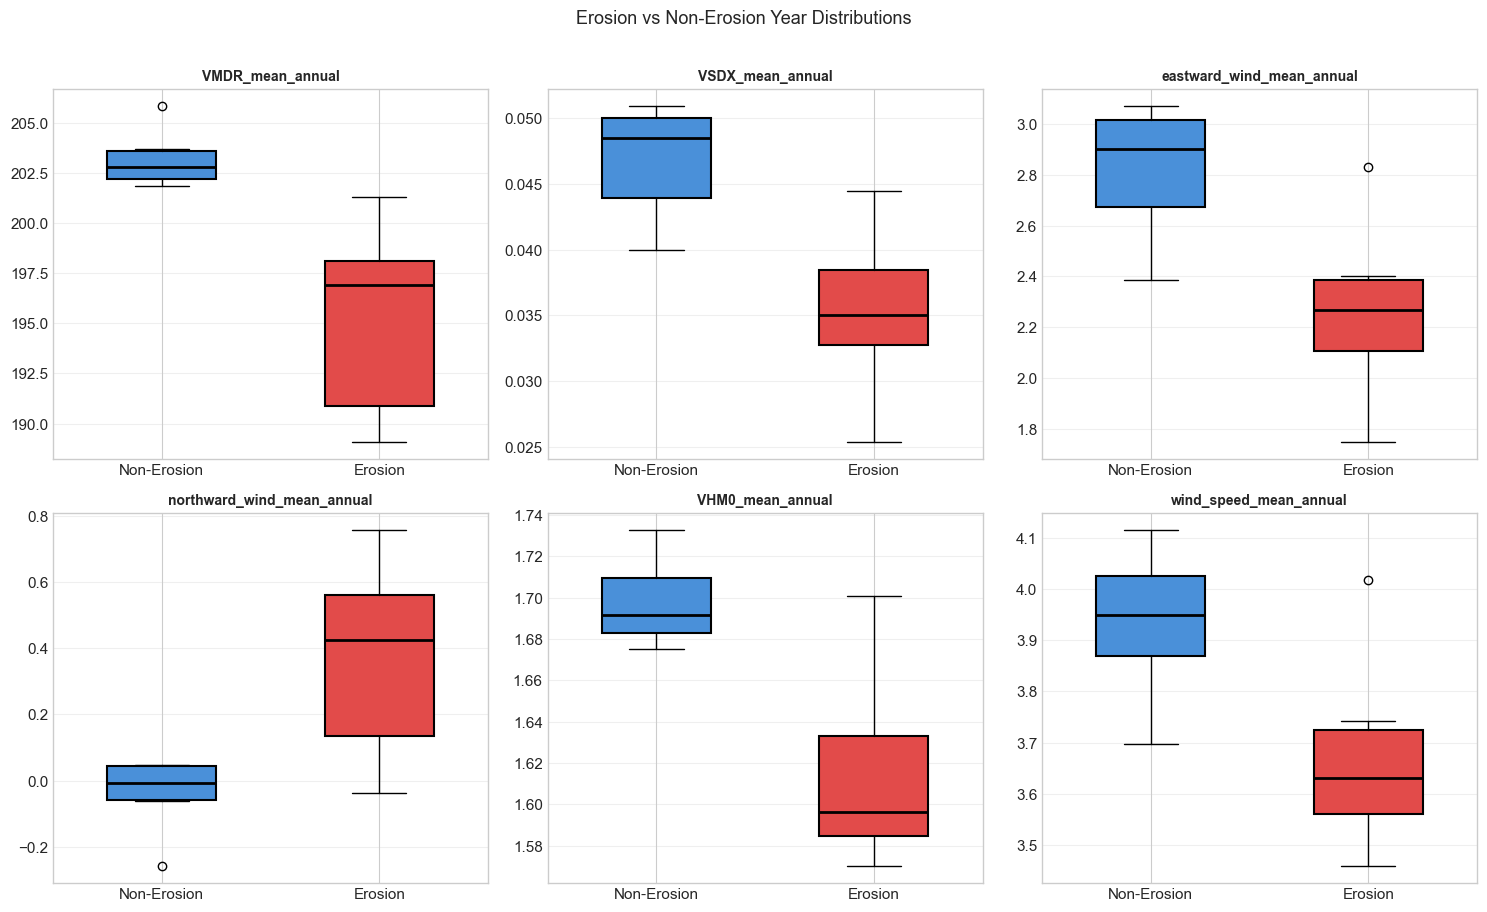

In [14]:
# =============================================================================
# Section 3.3 — Box plot comparison for top features
# =============================================================================

top_feats = significant_features[:min(6, len(significant_features))]
n_feats = len(top_feats)
n_cols = min(3, n_feats)
n_rows = int(np.ceil(n_feats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for i, feat in enumerate(top_feats):
    ax = axes[i]
    data = [non_erosion_rows[feat].dropna().values, erosion_rows[feat].dropna().values]
    bp = ax.boxplot(data, labels=['Non-Erosion', 'Erosion'], patch_artist=True,
                    widths=0.5,
                    boxprops=dict(linewidth=1.5),
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#4A90D9')
    bp['boxes'][1].set_facecolor('#E24B4A')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Erosion vs Non-Erosion Year Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./figures/boxplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 4 — Advanced Multi-Method Ensemble Threshold Detection

This section implements a **four-method ensemble** for identifying erosion thresholds per forcing feature:

| Method | Principle | Reference |
|--------|-----------|-----------|
| **A. ROC / Youden's J** | Maximize sensitivity + specificity (Youden, 1950) | Standard in clinical & environmental sciences |
| **B. Bayesian Logistic Inflection** | Find P(erosion) = 0.5 inflection via logistic regression | Principled probabilistic interpretation |
| **C. Profile-Likelihood Change-Point** | Maximize log-likelihood ratio across all candidate splits | Distribution-free, well-suited for small N |
| **D. Maximum Mutual Information** | Maximize Shannon information I(X_binary ; Y) | Non-parametric, information-theoretic |

**Permutation testing** (n = 5 000) provides exact p-values for each threshold's discriminatory power. **Bootstrap resampling** (n = 2 000) provides 95 % confidence intervals.

> **Why NOT Hidden Markov Models?**
> HMMs model sequential regime transitions and excel with long time series (n > 100). With only ~15 annual observations the transition matrix is under-determined (4 free parameters from just 14 transitions). Furthermore, consecutive erosion/non-erosion years in this monsoon-driven system are not necessarily Markov-dependent — external forcing (ENSO, IOD) can cause non-adjacent erosion events. The four methods above directly optimize threshold location and uncertainty, making them more appropriate for this application.


In [16]:
# =============================================================================
# Section 4.1 — Four-method ensemble threshold detection per feature
# =============================================================================


def direction_symbol(direction):
    return '>' if direction == 'above' else '<'



def threshold_exceeded(value, threshold, direction):
    if pd.isna(value) or pd.isna(threshold):
        return False
    return value > threshold if direction == 'above' else value < threshold



def threshold_rule_text(feature_name, threshold, direction):
    return f"If {feature_name} {direction_symbol(direction)} {threshold:.4f} -> erosion begins"



def _restore_threshold(oriented_threshold, direction):
    return oriented_threshold if direction == 'above' else -oriented_threshold



def _prepare_oriented_roc_inputs(X_feat, y):
    X_feat = np.asarray(X_feat, dtype=float)
    fpr, tpr, thresholds = roc_curve(y, X_feat)
    roc_auc = auc(fpr, tpr)
    direction = 'above'

    if roc_auc < 0.5:
        direction = 'below'
        X_oriented = -X_feat
        fpr, tpr, thresholds = roc_curve(y, X_oriented)
        roc_auc = auc(fpr, tpr)
    else:
        X_oriented = X_feat

    finite_mask = np.isfinite(thresholds)
    return X_oriented, direction, fpr[finite_mask], tpr[finite_mask], thresholds[finite_mask], roc_auc



def _infer_direction_from_split(X_feat, y, threshold):
    X_feat = np.asarray(X_feat, dtype=float)
    below = y[X_feat <= threshold]
    above = y[X_feat > threshold]
    if len(below) == 0 or len(above) == 0:
        corr = np.corrcoef(X_feat, y)[0, 1] if len(np.unique(X_feat)) > 1 else 0.0
        return 'above' if np.nan_to_num(corr) >= 0 else 'below'
    return 'above' if above.mean() >= below.mean() else 'below'



def _permutation_auc(X, y, n_perm=5000, rng_seed=42):
    """Exact permutation p-value for oriented AUC > 0.5."""
    rng = np.random.default_rng(rng_seed)
    _, _, _, _, _, observed_auc = _prepare_oriented_roc_inputs(X, y)
    count = 0
    for _ in range(n_perm):
        _, _, _, _, _, perm_auc = _prepare_oriented_roc_inputs(X, rng.permutation(y))
        if perm_auc >= observed_auc:
            count += 1
    return count / n_perm



def _method_a_roc_youden(X_feat, y, n_boot=2000):
    """Method A: ROC / Youden-J with bootstrap CI + permutation p."""
    _, direction, fpr, tpr, thresholds, roc_auc = _prepare_oriented_roc_inputs(X_feat, y)
    if len(thresholds) == 0:
        return dict(
            threshold=np.nan,
            ci_lower=np.nan,
            ci_upper=np.nan,
            auc=roc_auc,
            sensitivity=np.nan,
            specificity=np.nan,
            perm_p=np.nan,
            statistic=roc_auc,
            p_value=np.nan,
            significant=False,
            direction=direction,
        )

    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    opt_thresh = _restore_threshold(thresholds[opt_idx], direction)
    sens, spec = tpr[opt_idx], 1 - fpr[opt_idx]

    rng = np.random.default_rng(42)
    boot = []
    for _ in range(n_boot):
        idx = rng.choice(len(y), len(y), replace=True)
        if len(np.unique(y[idx])) < 2:
            continue
        _, boot_dir, fp, tp, ths, _ = _prepare_oriented_roc_inputs(X_feat[idx], y[idx])
        if len(ths) == 0:
            continue
        boot.append(_restore_threshold(ths[np.argmax(tp - fp)], boot_dir))

    ci = np.percentile(boot, [2.5, 97.5]) if boot else [np.nan, np.nan]
    perm_p = _permutation_auc(X_feat, y)

    return dict(
        threshold=opt_thresh,
        ci_lower=ci[0],
        ci_upper=ci[1],
        auc=roc_auc,
        sensitivity=sens,
        specificity=spec,
        perm_p=perm_p,
        statistic=roc_auc,
        p_value=perm_p,
        significant=perm_p < 0.05,
        direction=direction,
    )



def _method_b_bayesian_logistic(X_feat, y, n_boot=2000):
    """Method B: Logistic-regression inflection (P=0.5 crossing)."""
    sc = StandardScaler()
    Xs = sc.fit_transform(X_feat.reshape(-1, 1))
    lr = LogisticRegression(random_state=42, class_weight='balanced', solver='lbfgs', max_iter=500)
    lr.fit(Xs, y)

    coef = lr.coef_[0][0]
    direction = 'above' if coef >= 0 else 'below'
    if np.isclose(coef, 0):
        thresh_orig = np.nan
    else:
        thresh_orig = (-lr.intercept_[0] / coef) * sc.scale_[0] + sc.mean_[0]

    rng = np.random.default_rng(42)
    boot = []
    for _ in range(n_boot):
        idx = rng.choice(len(y), len(y), replace=True)
        if len(np.unique(y[idx])) < 2:
            continue
        s = StandardScaler()
        Xb = s.fit_transform(X_feat[idx].reshape(-1, 1))
        lr_b = LogisticRegression(random_state=42, class_weight='balanced', solver='lbfgs', max_iter=500)
        lr_b.fit(Xb, y[idx])
        coef_b = lr_b.coef_[0][0]
        if np.isclose(coef_b, 0):
            continue
        boot.append((-lr_b.intercept_[0] / coef_b) * s.scale_[0] + s.mean_[0])

    ci = np.percentile(boot, [2.5, 97.5]) if boot else [np.nan, np.nan]
    return dict(
        threshold=thresh_orig,
        ci_lower=ci[0],
        ci_upper=ci[1],
        logistic_coef=coef * sc.scale_[0],
        statistic=abs(coef * sc.scale_[0]),
        direction=direction,
    )



def _method_c_profile_likelihood(X_feat, y):
    """Method C: Profile-likelihood change-point detection."""
    sorted_x = np.sort(np.unique(X_feat))
    if len(sorted_x) < 3:
        return dict(threshold=np.nan, ci_lower=np.nan, ci_upper=np.nan, LR_stat=np.nan, direction='above')

    candidates = (sorted_x[:-1] + sorted_x[1:]) / 2
    p_all = np.clip(y.mean(), 1e-8, 1 - 1e-8)
    ll_null = np.sum(y * np.log(p_all) + (1 - y) * np.log(1 - p_all))

    best_ll, best_t = -np.inf, np.nan
    ll_profile = []
    for t in candidates:
        below, above = y[X_feat <= t], y[X_feat > t]
        if len(below) < 2 or len(above) < 2:
            ll_profile.append(-np.inf)
            continue
        p1 = np.clip(below.mean(), 1e-8, 1 - 1e-8)
        p2 = np.clip(above.mean(), 1e-8, 1 - 1e-8)
        ll = (
            np.sum(below * np.log(p1) + (1 - below) * np.log(1 - p1))
            + np.sum(above * np.log(p2) + (1 - above) * np.log(1 - p2))
        )
        ll_profile.append(ll)
        if ll > best_ll:
            best_ll, best_t = ll, t

    lr_stat = 2 * (best_ll - ll_null) if best_ll > -np.inf else 0.0
    ll_arr = np.array(ll_profile)
    valid = ll_arr > -np.inf
    cutoff = best_ll - 1.92
    in_ci = candidates[valid][ll_arr[valid] >= cutoff] if valid.sum() else np.array([])
    ci = [in_ci.min(), in_ci.max()] if len(in_ci) else [np.nan, np.nan]
    direction = _infer_direction_from_split(X_feat, y, best_t) if np.isfinite(best_t) else 'above'

    return dict(
        threshold=best_t,
        ci_lower=ci[0],
        ci_upper=ci[1],
        LR_stat=lr_stat,
        statistic=lr_stat,
        direction=direction,
    )



def _method_d_mutual_information(X_feat, y, n_boot=2000):
    """Method D: Maximum mutual-information threshold."""
    sorted_x = np.sort(np.unique(X_feat))
    if len(sorted_x) < 3:
        return dict(threshold=np.nan, ci_lower=np.nan, ci_upper=np.nan, MI=np.nan, direction='above')

    candidates = (sorted_x[:-1] + sorted_x[1:]) / 2
    best_mi, best_t = -np.inf, np.nan
    for t in candidates:
        X_bin = (X_feat > t).astype(int)
        if len(np.unique(X_bin)) < 2:
            continue
        mi = mutual_info_score(X_bin, y)
        if mi > best_mi:
            best_mi, best_t = mi, t

    rng = np.random.default_rng(42)
    boot = []
    for _ in range(n_boot):
        idx = rng.choice(len(y), len(y), replace=True)
        if len(np.unique(y[idx])) < 2:
            continue
        bm, bt = -np.inf, np.nan
        for t in candidates:
            X_bin = (X_feat[idx] > t).astype(int)
            if len(np.unique(X_bin)) < 2:
                continue
            mi = mutual_info_score(X_bin, y[idx])
            if mi > bm:
                bm, bt = mi, t
        if np.isfinite(bt):
            boot.append(bt)

    ci = np.percentile(boot, [2.5, 97.5]) if boot else [np.nan, np.nan]
    direction = _infer_direction_from_split(X_feat, y, best_t) if np.isfinite(best_t) else 'above'
    return dict(
        threshold=best_t,
        ci_lower=ci[0],
        ci_upper=ci[1],
        MI=best_mi,
        statistic=best_mi,
        mi=best_mi,
        direction=direction,
    )


ensemble_results = {}
individual_thresholds = {}

for feat in significant_features:
    X_feat = analysis_df[feat].values
    y = analysis_df['erosion_label'].values

    print(f"\n{'=' * 65}")
    print(f"  Feature: {feat}")
    print(f"{'=' * 65}")

    res_a = _method_a_roc_youden(X_feat, y)
    res_b = _method_b_bayesian_logistic(X_feat, y)
    res_c = _method_c_profile_likelihood(X_feat, y)
    res_d = _method_d_mutual_information(X_feat, y)

    items = [
        ('ROC/Youden J', res_a, res_a.get('auc', 0.5)),
        ('Bayesian Logistic', res_b, 1.0),
        ('Profile Likelihood', res_c, max(res_c.get('LR_stat', 0) or 0, 0.01)),
        ('Mutual Information', res_d, max(res_d.get('MI', 0) or 0, 0.01)),
    ]

    finite_items = [
        (name, result, weight)
        for name, result, weight in items
        if np.isfinite(result.get('threshold', np.nan))
    ]

    direction_weights = {}
    for _, result, weight in finite_items:
        direction = result.get('direction', 'above')
        direction_weights[direction] = direction_weights.get(direction, 0.0) + weight

    consensus_direction = max(direction_weights, key=direction_weights.get) if direction_weights else 'above'
    selected = [
        (result['threshold'], weight)
        for _, result, weight in finite_items
        if result.get('direction', 'above') == consensus_direction
    ]
    if not selected:
        selected = [(result['threshold'], weight) for _, result, weight in finite_items]

    if selected:
        sorted_pairs = sorted(selected, key=lambda item: item[0])
        cumulative = np.cumsum([weight for _, weight in sorted_pairs])
        consensus = sorted_pairs[np.searchsorted(cumulative, cumulative[-1] / 2)][0]
        tol = 0.10 * abs(consensus) if consensus != 0 else 0.1
        agreement = sum(
            1
            for _, result, _ in finite_items
            if result.get('direction', 'above') == consensus_direction
            and abs(result['threshold'] - consensus) <= tol
        ) / max(len(selected), 1)
    else:
        consensus, agreement = np.nan, 0.0

    pct_rank = stats.percentileofscore(X_feat, consensus) if np.isfinite(consensus) else np.nan

    ensemble_results[feat] = dict(
        roc_youden=res_a,
        bayesian_logistic=res_b,
        change_point=res_c,
        mutual_info=res_d,
        consensus_threshold=consensus,
        consensus_agreement=agreement,
        percentile_rank=pct_rank,
        direction=consensus_direction,
    )

    mw_row = mw_df[mw_df['feature'] == feat]
    p_val = mw_row['p_value'].values[0] if len(mw_row) else np.nan
    finite_thresholds = [result['threshold'] for _, result, _ in finite_items]
    individual_thresholds[feat] = {
        'threshold_all': consensus,
        'threshold_low': min(finite_thresholds) if finite_thresholds else np.nan,
        'threshold_high': max(finite_thresholds) if finite_thresholds else np.nan,
        'direction': consensus_direction,
        'p_value': p_val,
    }

    for label, result in [
        ('A  ROC/Youden J      ', res_a),
        ('B  Bayesian Logistic ', res_b),
        ('C  Profile Likelihood', res_c),
        ('D  Mutual Information', res_d),
    ]:
        print(
            f"  {label}: {result['threshold']:>9.4f}  "
            f"[{result.get('ci_lower', np.nan):.4f}, {result.get('ci_upper', np.nan):.4f}]  "
            f"dir={result.get('direction', 'above'):>5s}"
        )
    print(
        f"  -- Consensus         : {consensus:>9.4f}  "
        f"dir={consensus_direction:>5s}  Agreement={agreement:.0%}  Percentile={pct_rank:.1f}"
    )



  Feature: VMDR_mean_annual
  A  ROC/Youden J      :  201.2999  [196.0526, 201.2999]  dir=below
  B  Bayesian Logistic :  199.8150  [197.6723, 201.3662]  dir=below
  C  Profile Likelihood:  201.5885  [201.5885, 201.5885]  dir=below
  D  Mutual Information:  201.5885  [196.9142, 201.5885]  dir=below
  -- Consensus         :  201.5885  dir=below  Agreement=100%  Percentile=50.0

  Feature: VSDX_mean_annual
  A  ROC/Youden J      :    0.0389  [0.0329, 0.0444]  dir=below
  B  Bayesian Logistic :    0.0413  [0.0380, 0.0443]  dir=below
  C  Profile Likelihood:    0.0394  [0.0380, 0.0462]  dir=below
  D  Mutual Information:    0.0394  [0.0350, 0.0462]  dir=below
  -- Consensus         :    0.0394  dir=below  Agreement=100%  Percentile=41.7

  Feature: eastward_wind_mean_annual
  A  ROC/Youden J      :    2.4000  [2.0783, 2.8292]  dir=below
  B  Bayesian Logistic :    2.5517  [2.3603, 2.7309]  dir=below
  C  Profile Likelihood:    2.3625  [2.2673, 2.9012]  dir=below
  D  Mutual Information:  

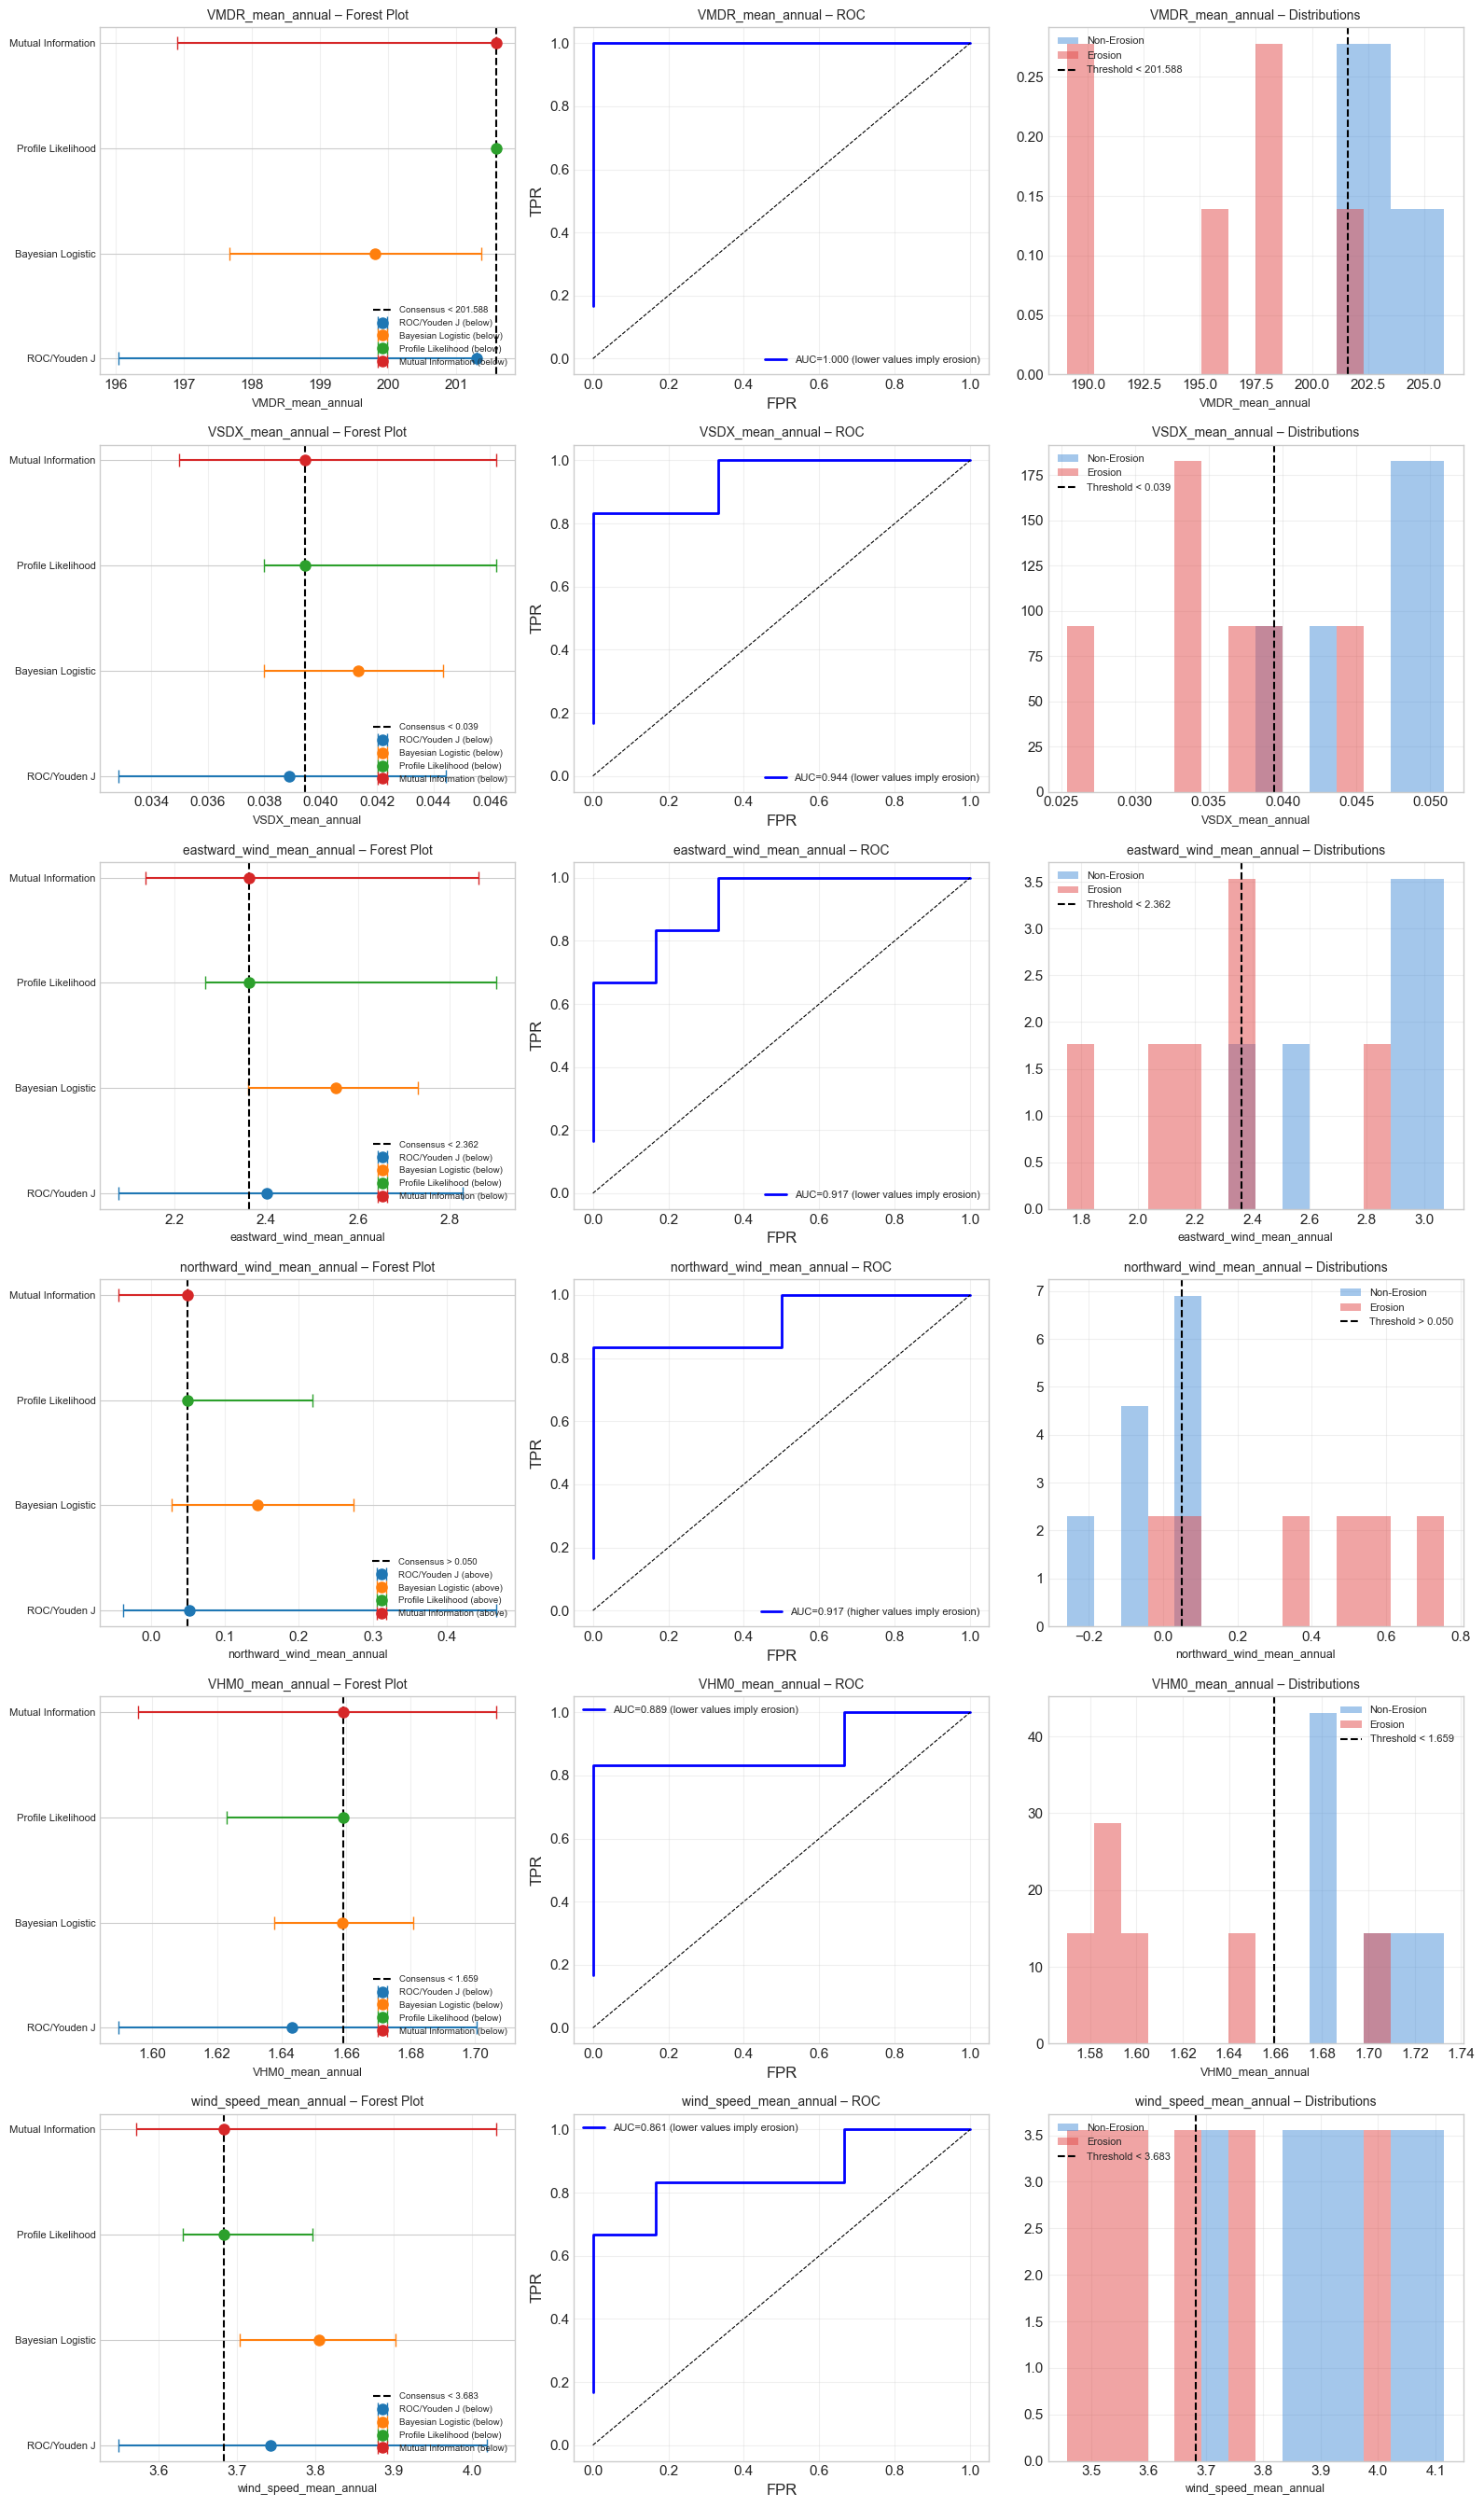

In [17]:
# =============================================================================
# Section 4.2 — Forest plot + ROC + distribution overlay per feature
# =============================================================================

n_sf = len(significant_features)
fig, axes = plt.subplots(n_sf, 3, figsize=(16, 4.5 * n_sf))
if n_sf == 1:
    axes = axes.reshape(1, -1)

method_colors = {
    'ROC/Youden J': '#1f77b4',
    'Bayesian Logistic': '#ff7f0e',
    'Profile Likelihood': '#2ca02c',
    'Mutual Information': '#d62728',
}

for i, feat in enumerate(significant_features):
    er = ensemble_results[feat]
    X_feat = analysis_df[feat].values
    y = analysis_df['erosion_label'].values
    direction = er.get('direction', 'above')

    ax = axes[i, 0]
    methods = [
        ('ROC/Youden J', er['roc_youden']),
        ('Bayesian Logistic', er['bayesian_logistic']),
        ('Profile Likelihood', er['change_point']),
        ('Mutual Information', er['mutual_info']),
    ]
    for j, (method_name, method_result) in enumerate(methods):
        threshold = method_result.get('threshold', np.nan)
        if not np.isfinite(threshold):
            continue
        lo = method_result.get('ci_lower', np.nan)
        hi = method_result.get('ci_upper', np.nan)
        xerr = None
        if np.isfinite(lo) and np.isfinite(hi):
            xerr = [[threshold - lo], [hi - threshold]]
        ax.errorbar(
            threshold,
            j,
            xerr=xerr,
            fmt='o',
            color=method_colors[method_name],
            capsize=5,
            markersize=8,
            label=f"{method_name} ({method_result.get('direction', 'above')})",
        )
    ax.axvline(
        er['consensus_threshold'],
        color='black',
        ls='--',
        lw=1.5,
        label=f"Consensus {direction_symbol(direction)} {er['consensus_threshold']:.3f}",
    )
    ax.set_yticks(range(4))
    ax.set_yticklabels([method[0] for method in methods], fontsize=8)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_title(f'{feat} – Forest Plot', fontsize=10)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')

    ax = axes[i, 1]
    _, roc_direction, fpr, tpr, _, roc_auc = _prepare_oriented_roc_inputs(X_feat, y)
    ax.plot(
        fpr,
        tpr,
        'b-',
        lw=2,
        label=f"AUC={roc_auc:.3f} ({'higher' if roc_direction == 'above' else 'lower'} values imply erosion)",
    )
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'{feat} – ROC', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[i, 2]
    erosion_values = analysis_df.loc[analysis_df['erosion_label'] == 1, feat]
    non_erosion_values = analysis_df.loc[analysis_df['erosion_label'] == 0, feat]
    bins = np.linspace(X_feat.min(), X_feat.max(), 15)
    ax.hist(non_erosion_values, bins=bins, alpha=0.5, color='#4A90D9', label='Non-Erosion', density=True)
    ax.hist(erosion_values, bins=bins, alpha=0.5, color='#E24B4A', label='Erosion', density=True)
    ax.axvline(
        er['consensus_threshold'],
        color='black',
        ls='--',
        lw=1.5,
        label=f"Threshold {direction_symbol(direction)} {er['consensus_threshold']:.3f}",
    )
    ax.set_xlabel(feat, fontsize=9)
    ax.set_title(f'{feat} – Distributions', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figures/ensemble_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()


### Section 4.3 — Threshold Stability Analysis (Bootstrap Cross-Validation)

To assess whether the consensus thresholds are robust or an artifact of this particular sample, we perform **bootstrap cross-validation** (n = 500). For each resample, the full 4-method ensemble is re-run and the consensus threshold recorded. The **coefficient of variation (CV)** quantifies stability:
- CV < 0.10 → Highly stable
- CV > 0.15 → Caution warranted


In [18]:
# =============================================================================
# Section 4.3 — Threshold stability: bootstrap cross-validation (n=500)
# =============================================================================


def _quick_method_a(Xb, yb):
    _, direction, fpr, tpr, thresholds, _ = _prepare_oriented_roc_inputs(Xb, yb)
    if len(thresholds) == 0:
        return np.nan, direction, 0.5
    threshold = _restore_threshold(thresholds[np.argmax(tpr - fpr)], direction)
    return threshold, direction, 1.0



def _quick_method_b(Xb, yb):
    try:
        scaler = StandardScaler()
        Xs = scaler.fit_transform(Xb.reshape(-1, 1))
        lr = LogisticRegression(random_state=42, class_weight='balanced', solver='lbfgs', max_iter=200)
        lr.fit(Xs, yb)
        coef = lr.coef_[0][0]
        if np.isclose(coef, 0):
            return np.nan, 'above', 1.0
        direction = 'above' if coef >= 0 else 'below'
        threshold = (-lr.intercept_[0] / coef) * scaler.scale_[0] + scaler.mean_[0]
        return threshold, direction, 1.0
    except Exception:
        return np.nan, 'above', 1.0



def _quick_method_c(Xb, yb):
    try:
        sorted_x = np.sort(np.unique(Xb))
        if len(sorted_x) < 3:
            return np.nan, 'above', 0.01
        candidates = (sorted_x[:-1] + sorted_x[1:]) / 2
        best_ll, best_t = -np.inf, np.nan
        p_all = np.clip(yb.mean(), 1e-8, 1 - 1e-8)
        ll_null = np.sum(yb * np.log(p_all) + (1 - yb) * np.log(1 - p_all))
        for threshold in candidates:
            below = yb[Xb <= threshold]
            above = yb[Xb > threshold]
            if len(below) < 2 or len(above) < 2:
                continue
            p1 = np.clip(below.mean(), 1e-8, 1 - 1e-8)
            p2 = np.clip(above.mean(), 1e-8, 1 - 1e-8)
            ll = (
                np.sum(below * np.log(p1) + (1 - below) * np.log(1 - p1))
                + np.sum(above * np.log(p2) + (1 - above) * np.log(1 - p2))
            )
            if ll > best_ll:
                best_ll, best_t = ll, threshold
        direction = _infer_direction_from_split(Xb, yb, best_t) if np.isfinite(best_t) else 'above'
        lr_stat = max(2 * (best_ll - ll_null), 0.01) if np.isfinite(best_ll) else 0.01
        return best_t, direction, lr_stat
    except Exception:
        return np.nan, 'above', 0.01



def _quick_method_d(Xb, yb):
    try:
        sorted_x = np.sort(np.unique(Xb))
        if len(sorted_x) < 3:
            return np.nan, 'above', 0.01
        candidates = (sorted_x[:-1] + sorted_x[1:]) / 2
        best_mi, best_t = -np.inf, np.nan
        for threshold in candidates:
            xb = (Xb > threshold).astype(int)
            if len(np.unique(xb)) < 2:
                continue
            mi = mutual_info_score(xb, yb)
            if mi > best_mi:
                best_mi, best_t = mi, threshold
        direction = _infer_direction_from_split(Xb, yb, best_t) if np.isfinite(best_t) else 'above'
        return best_t, direction, max(best_mi, 0.01)
    except Exception:
        return np.nan, 'above', 0.01


n_bootstrap = 500
rng = np.random.default_rng(42)
stability_results = {}

for feat in significant_features:
    X_feat = analysis_df[feat].values
    y = analysis_df['erosion_label'].values
    boot_consensi = []

    for _ in range(n_bootstrap):
        idx = rng.choice(len(y), len(y), replace=True)
        if len(np.unique(y[idx])) < 2:
            continue
        Xb, yb = X_feat[idx], y[idx]

        methods = [
            _quick_method_a(Xb, yb),
            _quick_method_b(Xb, yb),
            _quick_method_c(Xb, yb),
            _quick_method_d(Xb, yb),
        ]
        finite_methods = [(threshold, direction, weight) for threshold, direction, weight in methods if np.isfinite(threshold)]
        if not finite_methods:
            continue

        direction_weights = {}
        for _, direction, weight in finite_methods:
            direction_weights[direction] = direction_weights.get(direction, 0.0) + weight
        dominant_direction = max(direction_weights, key=direction_weights.get)

        thresholds = [threshold for threshold, direction, _ in finite_methods if direction == dominant_direction]
        if not thresholds:
            thresholds = [threshold for threshold, _, _ in finite_methods]
        boot_consensi.append(np.median(thresholds))

    arr = np.array(boot_consensi, dtype=float)
    if arr.size == 0:
        stability_results[feat] = {
            'mean': np.nan,
            'std': np.nan,
            'cv': np.nan,
            'ci_lower': np.nan,
            'ci_upper': np.nan,
            'stable': False,
            'direction': ensemble_results[feat].get('direction', 'above'),
        }
        print(f"{feat}: insufficient bootstrap samples")
        continue

    cv = arr.std() / abs(arr.mean()) if abs(arr.mean()) > 1e-10 else np.nan
    stability_results[feat] = {
        'mean': arr.mean(),
        'std': arr.std(),
        'cv': cv,
        'ci_lower': np.percentile(arr, 2.5),
        'ci_upper': np.percentile(arr, 97.5),
        'stable': cv < 0.15 if not np.isnan(cv) else False,
        'direction': ensemble_results[feat].get('direction', 'above'),
    }
    status = 'STABLE' if cv < 0.10 else ('MARGINAL' if cv < 0.15 else 'UNSTABLE')
    print(
        f"{feat}: CV = {cv:.4f}  "
        f"[{np.percentile(arr, 2.5):.3f}, {np.percentile(arr, 97.5):.3f}]  "
        f"dir={ensemble_results[feat].get('direction', 'above')}  {status}"
    )


VMDR_mean_annual: CV = 0.0052  [198.864, 201.803]  dir=below  STABLE
VSDX_mean_annual: CV = 0.0660  [0.036, 0.046]  dir=below  STABLE
eastward_wind_mean_annual: CV = 0.0809  [2.291, 2.848]  dir=below  STABLE
northward_wind_mean_annual: CV = 1.0181  [-0.040, 0.301]  dir=above  UNSTABLE
VHM0_mean_annual: CV = 0.0090  [1.633, 1.704]  dir=below  STABLE
wind_speed_mean_annual: CV = 0.0235  [3.645, 4.024]  dir=below  STABLE


## Section 5 — Per-Factor Erosion Threshold Rules

Each erosion factor is analyzed **independently** — no combined thresholds. The goal is to determine: **"If this single factor crosses its direction-aware threshold, erosion becomes likely."**

For each factor (wave, wind, current variables), we compute:
1. The consensus threshold from Section 4's 4-method ensemble
2. **Threshold-crossing rate** in erosion years vs non-erosion years
3. The clear rule: *"If [factor] is above or below its threshold in the erosion direction, erosion is likely"*

In [19]:
# =============================================================================
# Section 5.1 — Per-factor threshold rules
# =============================================================================


def infer_factor_category(feature_name):
    if feature_name.startswith(('VHM0', 'VTPK', 'VMDR', 'VSDX', 'VSDY')):
        return 'WAVE'
    if 'wind' in feature_name:
        return 'WIND'
    if feature_name.startswith(('uo', 'vo', 'zos')):
        return 'CURRENT'
    return 'OTHER'


factor_threshold_rows = []

for feat in significant_features:
    er = ensemble_results.get(feat, {})
    ct = er.get('consensus_threshold', np.nan)
    direction = er.get('direction', 'above')
    if not np.isfinite(ct):
        continue

    category = infer_factor_category(feat)
    erosion_vals = analysis_df.loc[analysis_df['erosion_label'] == 1, feat]
    non_erosion_vals = analysis_df.loc[analysis_df['erosion_label'] == 0, feat]
    erosion_exceed = erosion_vals.apply(lambda value: threshold_exceeded(value, ct, direction)).mean()
    non_erosion_exceed = non_erosion_vals.apply(lambda value: threshold_exceeded(value, ct, direction)).mean()

    stability_info = stability_results.get(feat, {})
    cv = stability_info.get('cv', np.nan)
    stable = bool(stability_info.get('stable', False))
    rule_text = threshold_rule_text(feat, ct, direction)

    print(f"\n{'=' * 70}")
    print(f"{category} | {feat}")
    print(f"  Rule: {rule_text}")
    print(f"  Erosion exceedance:     {erosion_exceed:.1%}")
    print(f"  Non-erosion exceedance: {non_erosion_exceed:.1%}")
    if not np.isnan(cv):
        print(f"  Stability (CV): {cv:.4f} {'STABLE' if stable else 'UNSTABLE'}")

    factor_threshold_rows.append({
        'Category': category,
        'Factor': feat,
        'Threshold': round(ct, 4),
        'Direction': direction,
        'Rule': rule_text,
        'Erosion_Exceed_Rate': round(float(erosion_exceed), 3),
        'NonErosion_Exceed_Rate': round(float(non_erosion_exceed), 3),
        'Mean_Erosion': round(float(erosion_vals.mean()), 4),
        'Mean_NonErosion': round(float(non_erosion_vals.mean()), 4),
        'CV': round(cv, 4) if not np.isnan(cv) else np.nan,
        'Stable': stable,
    })

factor_rules_df = pd.DataFrame(factor_threshold_rows)
print(f"\n{'=' * 70}")
print(f"Generated {len(factor_threshold_rows)} per-factor threshold rules")



WAVE | VMDR_mean_annual
  Rule: If VMDR_mean_annual < 201.5885 -> erosion begins
  Erosion exceedance:     100.0%
  Non-erosion exceedance: 0.0%
  Stability (CV): 0.0052 STABLE

WAVE | VSDX_mean_annual
  Rule: If VSDX_mean_annual < 0.0394 -> erosion begins
  Erosion exceedance:     83.3%
  Non-erosion exceedance: 0.0%
  Stability (CV): 0.0660 STABLE

WIND | eastward_wind_mean_annual
  Rule: If eastward_wind_mean_annual < 2.3625 -> erosion begins
  Erosion exceedance:     66.7%
  Non-erosion exceedance: 0.0%
  Stability (CV): 0.0809 STABLE

WIND | northward_wind_mean_annual
  Rule: If northward_wind_mean_annual > 0.0496 -> erosion begins
  Erosion exceedance:     83.3%
  Non-erosion exceedance: 0.0%
  Stability (CV): 1.0181 UNSTABLE

WAVE | VHM0_mean_annual
  Rule: If VHM0_mean_annual < 1.6593 -> erosion begins
  Erosion exceedance:     83.3%
  Non-erosion exceedance: 0.0%
  Stability (CV): 0.0090 STABLE

WIND | wind_speed_mean_annual
  Rule: If wind_speed_mean_annual < 3.6829 -> erosi

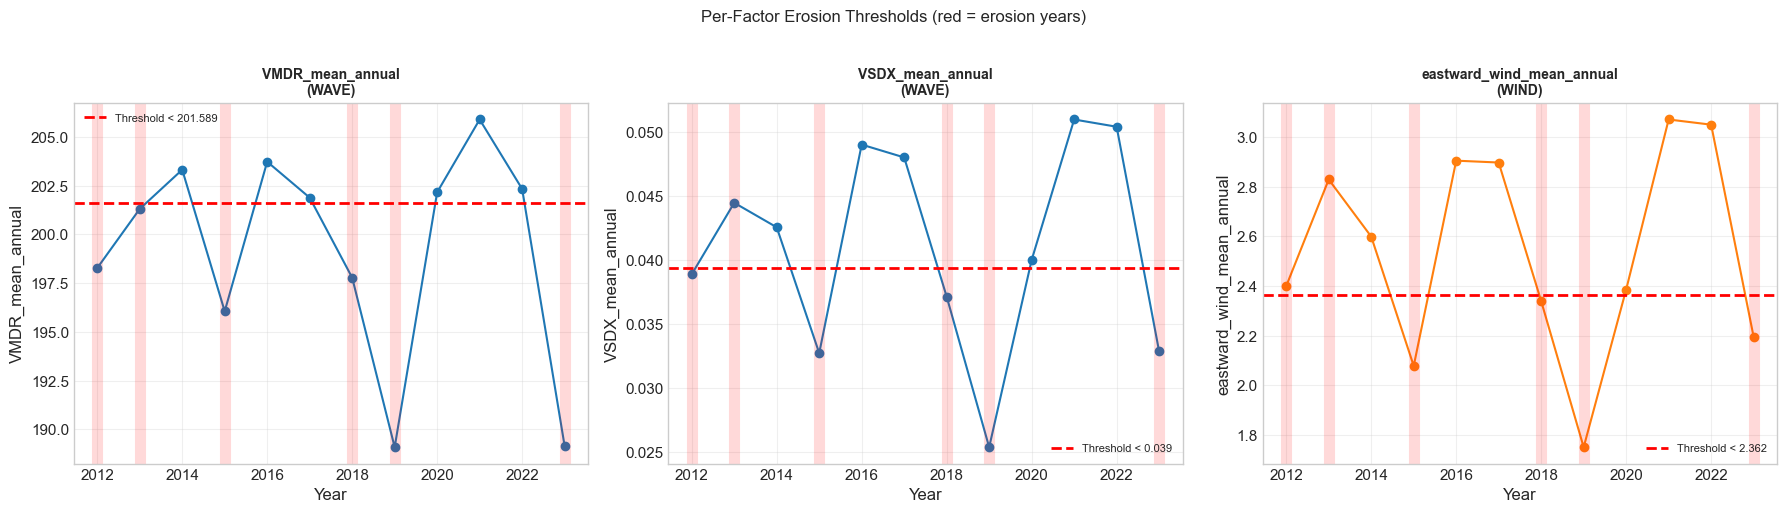

In [20]:
# =============================================================================
# Section 5.2 — Per-Factor Threshold Visualization
# =============================================================================

n_factors = len(factor_threshold_rows)
if n_factors > 0:
    fig, axes = plt.subplots(1, min(3, n_factors), figsize=(6 * min(3, n_factors), 5))
    if n_factors == 1:
        axes = [axes]
    else:
        axes = np.atleast_1d(axes).ravel()

    category_colors = {'WAVE': '#1f77b4', 'WIND': '#ff7f0e', 'CURRENT': '#2ca02c', 'OTHER': '#9467bd'}

    for i, row in enumerate(factor_threshold_rows[:min(3, n_factors)]):
        ax = axes[i]
        feat = row['Factor']
        ct = row['Threshold']
        direction = row.get('Direction', 'above')
        color = category_colors.get(row['Category'], 'gray')

        ax.plot(analysis_df['monsoon_year'], analysis_df[feat], 'o-', color=color, lw=1.5)
        ax.axhline(ct, color='red', ls='--', lw=2, label=f"Threshold {direction_symbol(direction)} {ct:.3f}")

        for yr in all_erosion_years:
            ax.axvline(yr, color='red', alpha=0.15, lw=8)

        ax.set_title(f'{feat}\n({row["Category"]})', fontsize=10, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel(feat)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Per-Factor Erosion Thresholds (red = erosion years)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('./figures/per_factor_thresholds.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No factor thresholds to visualize.')


In [21]:
# =============================================================================
# Section 5.3 — Per-Factor Exceedance Table for Each Erosion Year
# =============================================================================

print('=' * 70)
print('  EROSION YEAR THRESHOLD EXCEEDANCE (PER FACTOR)')
print('=' * 70)

erosion_years_data = analysis_df[analysis_df['erosion_label'] == 1].copy()

for _, yr_row in erosion_years_data.iterrows():
    yr = int(yr_row['monsoon_year'])
    print(f"\n  Year {yr} (NSM = {yr_row['annual_NSM']:.2f} m, Class = {yr_row['Change_Class']})")
    print(f"  {'Factor':<35} {'Value':>10} {'Rule':>22} {'Exceeded?':>10}")
    print(f"  {'-' * 85}")

    for frow in factor_threshold_rows:
        feat = frow['Factor']
        ct = frow['Threshold']
        direction = frow.get('Direction', 'above')
        operator = direction_symbol(direction)
        val = yr_row[feat]
        exceeded = 'YES' if threshold_exceeded(val, ct, direction) else 'no'
        print(f"  {feat:<35} {val:>10.4f} {operator + ' ' + format(ct, '.4f'):>22} {exceeded:>10}")

X_rf = analysis_df[significant_features].values
y_rf = analysis_df['erosion_label'].values

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    oob_score=True,
    n_jobs=-1,
)
rf.fit(X_rf, y_rf)

loo = LeaveOneOut()
y_pred_loo = cross_val_predict(rf, X_rf, y_rf, cv=loo)

print(f"\n{'=' * 70}")
print(f"  RF Model (for forecasting): LOO Accuracy = {accuracy_score(y_rf, y_pred_loo):.4f}")
print(f"{'=' * 70}")


  EROSION YEAR THRESHOLD EXCEEDANCE (PER FACTOR)

  Year 2012 (NSM = -2.68 m, Class = eroded_low)
  Factor                                   Value                   Rule  Exceeded?
  -------------------------------------------------------------------------------------
  VMDR_mean_annual                      198.2691             < 201.5885        YES
  VSDX_mean_annual                        0.0389               < 0.0394        YES
  eastward_wind_mean_annual               2.4000               < 2.3625         no
  northward_wind_mean_annual              0.3850               > 0.0496        YES
  VHM0_mean_annual                        1.5896               < 1.6593        YES
  wind_speed_mean_annual                  3.7425               < 3.6829         no

  Year 2013 (NSM = -6.50 m, Class = eroded_high)
  Factor                                   Value                   Rule  Exceeded?
  -------------------------------------------------------------------------------------
  VMDR_mean_

In [22]:
# =============================================================================
# Section 5.4 — Final Per-Factor Threshold Summary Table
# =============================================================================

print('=' * 70)
print('  FINAL FACTOR-WISE EROSION THRESHOLD TABLE')
print('=' * 70)
print()
print('  These are the individual thresholds for each erosion factor.')
print('  Direction matters: some factors trigger erosion above a threshold, others below it.')
print()

summary_rows = []
for frow in factor_threshold_rows:
    summary_rows.append({
        'Category': frow['Category'],
        'Factor': frow['Factor'],
        'Direction': direction_symbol(frow.get('Direction', 'above')),
        'Threshold_Value': frow['Threshold'],
        'Erosion_Exceedance_%': f"{frow['Erosion_Exceed_Rate'] * 100:.0f}%",
        'Non_Erosion_Exceedance_%': f"{frow['NonErosion_Exceed_Rate'] * 100:.0f}%",
        'Stable': 'Y' if frow['Stable'] else 'N',
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print()
print('-' * 70)
print('  THRESHOLD RULES:')
print('-' * 70)
for frow in factor_threshold_rows:
    cat_icon = {'WAVE': 'WAVE', 'WIND': 'WIND', 'CURRENT': 'CURRENT'}.get(frow['Category'], 'OTHER')
    print(f"  {cat_icon}: {threshold_rule_text(frow['Factor'], frow['Threshold'], frow.get('Direction', 'above'))}")

summary_df_export = pd.DataFrame(factor_threshold_rows)


  FINAL FACTOR-WISE EROSION THRESHOLD TABLE

  These are the individual thresholds for each erosion factor.
  Direction matters: some factors trigger erosion above a threshold, others below it.

Category                     Factor Direction  Threshold_Value Erosion_Exceedance_% Non_Erosion_Exceedance_% Stable
    WAVE           VMDR_mean_annual         <       201.588501                 100%                       0%      Y
    WAVE           VSDX_mean_annual         <         0.039400                  83%                       0%      Y
    WIND  eastward_wind_mean_annual         <         2.362500                  67%                       0%      Y
    WIND northward_wind_mean_annual         >         0.049600                  83%                       0%      N
    WAVE           VHM0_mean_annual         <         1.659300                  83%                       0%      Y
    WIND     wind_speed_mean_annual         <         3.682900                  67%                       0% 

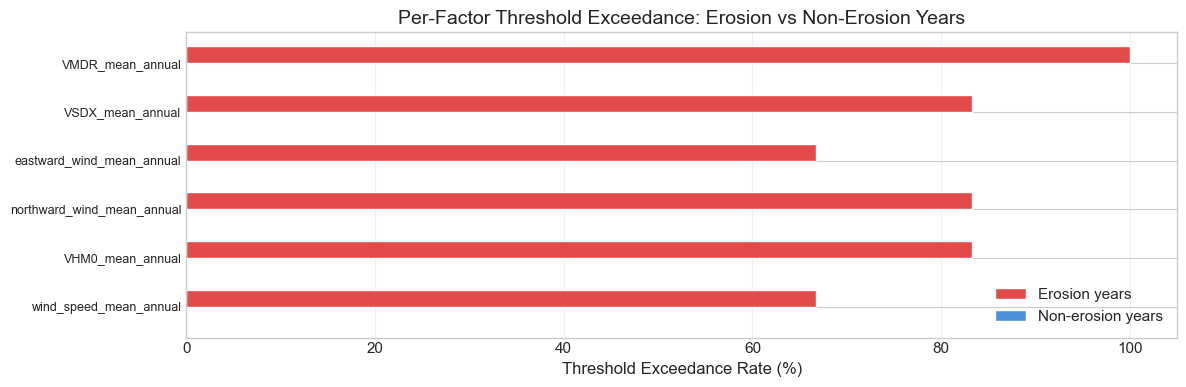

In [23]:
# =============================================================================
# Section 5.5 — Per-Factor Threshold Bar Chart
# =============================================================================

if len(factor_threshold_rows) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(factor_threshold_rows) * 0.6)))

    factors = [r['Factor'] for r in factor_threshold_rows]
    erosion_rates = [r['Erosion_Exceed_Rate'] * 100 for r in factor_threshold_rows]
    non_erosion_rates = [r['NonErosion_Exceed_Rate'] * 100 for r in factor_threshold_rows]

    y_pos = np.arange(len(factors))
    bar_height = 0.35

    ax.barh(y_pos - bar_height/2, erosion_rates, bar_height,
            color='#E24B4A', label='Erosion years', edgecolor='white')
    ax.barh(y_pos + bar_height/2, non_erosion_rates, bar_height,
            color='#4A90D9', label='Non-erosion years', edgecolor='white')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(factors, fontsize=9)
    ax.set_xlabel('Threshold Exceedance Rate (%)')
    ax.set_title('Per-Factor Threshold Exceedance: Erosion vs Non-Erosion Years')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig('./figures/factor_exceedance_rates.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No factor threshold data to plot.")

## Section 6 — Master Threshold Table (Per-Factor)

This section compiles all **individual factor thresholds** into a master table with confidence intervals, AUC, agreement, and percentile rank. Each factor's threshold is determined independently — no combined wave+wind or similar thresholds.

In [24]:
# =============================================================================
# Section 6.1 — Master threshold table (all features, all methods)
# =============================================================================

master_rows = []
for feat in significant_features:
    er = ensemble_results[feat]
    mw_row = mw_df[mw_df['feature'] == feat]
    p_val = mw_row['p_value'].values[0] if len(mw_row) else np.nan
    finite_thresholds = [
        result['threshold']
        for result in [er['roc_youden'], er['bayesian_logistic'], er['change_point'], er['mutual_info']]
        if np.isfinite(result.get('threshold', np.nan))
    ]
    master_rows.append({
        'Variable': feat,
        'Direction': direction_symbol(er.get('direction', 'above')),
        'Threshold_consensus': round(er['consensus_threshold'], 4),
        'Threshold_low': round(min(finite_thresholds), 4) if finite_thresholds else np.nan,
        'Threshold_high': round(max(finite_thresholds), 4) if finite_thresholds else np.nan,
        'CI_95_lower': round(er['roc_youden'].get('ci_lower', np.nan), 4),
        'CI_95_upper': round(er['roc_youden'].get('ci_upper', np.nan), 4),
        'AUC': round(er['roc_youden'].get('auc', np.nan), 4),
        'Perm_p': round(er['roc_youden'].get('perm_p', np.nan), 4),
        'Agreement': round(er['consensus_agreement'], 2),
        'Percentile': round(er['percentile_rank'], 1),
        'MW_p': round(p_val, 4),
    })

master_df = pd.DataFrame(master_rows)
print('=== MASTER THRESHOLD TABLE ===')
print(master_df.to_string(index=False))


=== MASTER THRESHOLD TABLE ===
                  Variable Direction  Threshold_consensus  Threshold_low  Threshold_high  CI_95_lower  CI_95_upper    AUC  Perm_p  Agreement  Percentile   MW_p
          VMDR_mean_annual         <           201.588501       199.8150      201.588501     196.0526     201.2999 1.0000  0.0022       1.00        50.0 0.0022
          VSDX_mean_annual         <             0.039400         0.0389        0.041300       0.0329       0.0444 0.9444  0.0068       1.00        41.7 0.0087
 eastward_wind_mean_annual         <             2.362500         2.3625        2.551700       2.0783       2.8292 0.9167  0.0158       1.00        33.3 0.0152
northward_wind_mean_annual         >             0.049600         0.0496        0.143600      -0.0375       0.4667 0.9167  0.0118       0.75        58.3 0.0152
          VHM0_mean_annual         <             1.659300         1.6432        1.659300       1.5896       1.7006 0.8889  0.0268       1.00        41.7 0.0260
    wind_

In [25]:
# =============================================================================
# Section 6.2 — Per erosion-event year factor exceedance diagnosis
# =============================================================================

print('=== ENHANCED PER-EVENT DIAGNOSIS ===\n')

event_rows = []
for yr in sorted(all_erosion_years):
    yr_data = analysis_df[analysis_df['monsoon_year'] == yr]
    if len(yr_data) == 0:
        continue
    row = {'year': int(yr)}
    total_exceedances = 0
    for feat in significant_features:
        val = yr_data[feat].values[0]
        er = ensemble_results.get(feat, {})
        ct = er.get('consensus_threshold', np.nan)
        direction = er.get('direction', 'above')
        exceeded = threshold_exceeded(val, ct, direction)
        row[f'{feat}_val'] = round(val, 3)
        row[f'{feat}_rule'] = f"{direction_symbol(direction)} {ct:.3f}" if np.isfinite(ct) else 'NA'
        row[f'{feat}_exceed'] = exceeded
        if exceeded:
            total_exceedances += 1
    row['total_exceedances'] = total_exceedances
    row['confidence'] = (
        'HIGH' if total_exceedances >= 3 else
        'MODERATE' if total_exceedances >= 2 else
        'LOW' if total_exceedances >= 1 else 'NONE'
    )
    event_rows.append(row)

event_df = pd.DataFrame(event_rows)
print(event_df.to_string(index=False))

multi_method_rows = []
for feat in significant_features:
    er = ensemble_results[feat]
    for method_name, method_key in [
        ('ROC/Youden', 'roc_youden'),
        ('Bayesian Logistic', 'bayesian_logistic'),
        ('Change-Point', 'change_point'),
        ('Mutual Info', 'mutual_info'),
    ]:
        result = er[method_key]
        multi_method_rows.append({
            'feature': feat,
            'method': method_name,
            'direction': result.get('direction', 'above'),
            'threshold': round(result['threshold'], 4),
            'ci_lower': round(result.get('ci_lower', np.nan), 4),
            'ci_upper': round(result.get('ci_upper', np.nan), 4),
        })
    multi_method_rows.append({
        'feature': feat,
        'method': 'CONSENSUS',
        'direction': er.get('direction', 'above'),
        'threshold': round(er['consensus_threshold'], 4),
        'ci_lower': np.nan,
        'ci_upper': np.nan,
    })

print(f"\nGenerated {len(event_rows)} erosion-event diagnoses and {len(multi_method_rows)} multi-method threshold records")


=== ENHANCED PER-EVENT DIAGNOSIS ===

 year  VMDR_mean_annual_val VMDR_mean_annual_rule  VMDR_mean_annual_exceed  VSDX_mean_annual_val VSDX_mean_annual_rule  VSDX_mean_annual_exceed  eastward_wind_mean_annual_val eastward_wind_mean_annual_rule  eastward_wind_mean_annual_exceed  northward_wind_mean_annual_val northward_wind_mean_annual_rule  northward_wind_mean_annual_exceed  VHM0_mean_annual_val VHM0_mean_annual_rule  VHM0_mean_annual_exceed  wind_speed_mean_annual_val wind_speed_mean_annual_rule  wind_speed_mean_annual_exceed  total_exceedances confidence
 2012            198.268997             < 201.588                     True                 0.039               < 0.039                     True                          2.400                        < 2.362                             False                           0.385                         > 0.050                               True                 1.590               < 1.659                     True                       3.742  

## Section 7 — Advanced 24-Month Forecast with Actual Predictions

**SARIMA time-series models** trained on the full monthly environmental record, with:

1. **STL decomposition** to confirm annual monsoon seasonality
2. **SARIMA model selection** via AIC grid search (27 candidate models per variable) with Ljung-Box residual diagnostics and out-of-sample RMSE validation
3. **Hindcast validation** against all known erosion years — temporal cross-validation with operational skill metrics (POD, FAR, CSI, Brier Skill Score)
4. **Analytical uncertainty propagation** from SARIMA forecast bounds through the Random Forest erosion model
5. **Actual shoreline retreat** predicted in meters by combining P(erosion) with EPR distributions
6. **Per-transect vulnerability** scores combine historical erosion severity with forecast probability

In [26]:

# =============================================================================
# Section 7.0 — Establish forecast base date and horizons
# =============================================================================

import pandas as pd

# Use the last available wind data date as the base
last_wind_date = pd.Timestamp(wind_df['time'].max())
last_wave_date = pd.Timestamp(wave_df['time'].max())
base_date = min(last_wind_date, last_wave_date)
print(f"Forecast base date: {base_date.strftime('%Y-%m')}")

horizons = {
    'H6':  base_date + pd.DateOffset(months=6),
    'H12': base_date + pd.DateOffset(months=12),
    'H18': base_date + pd.DateOffset(months=18),
    'H24': base_date + pd.DateOffset(months=24),
}

for h, d in horizons.items():
    print(f"  {h}: {d.strftime('%Y-%m')}")

# ── Build monthly forcing time series for SARIMA ──
# We need: one monthly series per forcing variable

# Merge monthly datasets
env_monthly = wave_monthly.merge(wind_monthly, on=['monsoon_year', 'year_month'],
                                  how='outer', suffixes=('_wave', '_wind'))
env_monthly = env_monthly.merge(current_monthly, on=['monsoon_year', 'year_month'],
                                 how='outer')
env_monthly = env_monthly.sort_values('year_month').reset_index(drop=True)

# Build datetime index directly from year_month Period (always clean month-start midnight)
# This avoids issues from raw time columns that may carry non-midnight hour offsets
env_monthly['datetime'] = env_monthly['year_month'].apply(
    lambda p: p.to_timestamp() if hasattr(p, 'to_timestamp') else pd.Timestamp(str(p))
)

# Drop any rows without a valid datetime
env_monthly = env_monthly.dropna(subset=['datetime'])
env_monthly = env_monthly.set_index('datetime').sort_index()
env_monthly = env_monthly[~env_monthly.index.duplicated(keep='first')]

# Define SARIMA variables — ALL wave/wind/current monthly features (per-variable)
SARIMA_VARS = {
    # Wave — VHM0, VTPK, VMDR, VSDX, VSDY
    'VHM0_max':           'VHM0_max',
    'VHM0_mean':          'VHM0_mean',
    'VTPK_max':           'VTPK_max',
    'VTPK_mean':          'VTPK_mean',
    'VMDR_mean':          'VMDR_mean',
    'VSDX_max':           'VSDX_max',
    'VSDX_mean':          'VSDX_mean',
    'VSDY_max':           'VSDY_max',
    'VSDY_mean':          'VSDY_mean',
    # Wind — wind_speed, eastward_wind, northward_wind
    'wind_speed_max':     'wind_speed_max',
    'wind_speed_mean':    'wind_speed_mean',
    'eastward_wind_max':  'eastward_wind_max',
    'eastward_wind_mean': 'eastward_wind_mean',
    'northward_wind_max': 'northward_wind_max',
    'northward_wind_mean':'northward_wind_mean',
    # Current — uo, vo, zos
    'uo_max':             'uo_max',
    'uo_mean':            'uo_mean',
    'vo_max':             'vo_max',
    'vo_mean':            'vo_mean',
    'zos_max':            'zos_max',
    'zos_mean':           'zos_mean',
}

# Extract monthly series
forcing_vars_monthly = {}
for var_name, col in SARIMA_VARS.items():
    if col in env_monthly.columns:
        s = env_monthly[col].copy()
        s = s[s.index.notna()]
        s = s[~s.index.duplicated(keep='first')]
        try:
            s = s.asfreq('MS')
        except ValueError:
            # Fallback: resample to month-start if asfreq fails
            s = s.resample('MS').first()
        s = s.interpolate(method='linear').ffill().bfill()
        forcing_vars_monthly[var_name] = s

print(f"\nSARIMA variables prepared: {list(forcing_vars_monthly.keys())}")
for v, s in forcing_vars_monthly.items():
    print(f"  {v}: {len(s)} months, {s.index.min().strftime('%Y-%m')} to {s.index.max().strftime('%Y-%m')}")


Forecast base date: 2024-02
  H6: 2024-08
  H12: 2025-02
  H18: 2025-08
  H24: 2026-02

SARIMA variables prepared: ['VHM0_max', 'VHM0_mean', 'VTPK_max', 'VTPK_mean', 'VMDR_mean', 'VSDX_max', 'VSDX_mean', 'VSDY_max', 'VSDY_mean', 'wind_speed_max', 'wind_speed_mean', 'eastward_wind_max', 'eastward_wind_mean', 'northward_wind_max', 'northward_wind_mean', 'uo_max', 'uo_mean', 'vo_max', 'vo_mean', 'zos_max', 'zos_mean']
  VHM0_max: 175 months, 2009-08 to 2024-02
  VHM0_mean: 175 months, 2009-08 to 2024-02
  VTPK_max: 175 months, 2009-08 to 2024-02
  VTPK_mean: 175 months, 2009-08 to 2024-02
  VMDR_mean: 175 months, 2009-08 to 2024-02
  VSDX_max: 175 months, 2009-08 to 2024-02
  VSDX_mean: 175 months, 2009-08 to 2024-02
  VSDY_max: 175 months, 2009-08 to 2024-02
  VSDY_mean: 175 months, 2009-08 to 2024-02
  wind_speed_max: 175 months, 2009-08 to 2024-02
  wind_speed_mean: 175 months, 2009-08 to 2024-02
  eastward_wind_max: 175 months, 2009-08 to 2024-02
  eastward_wind_mean: 175 months, 2009

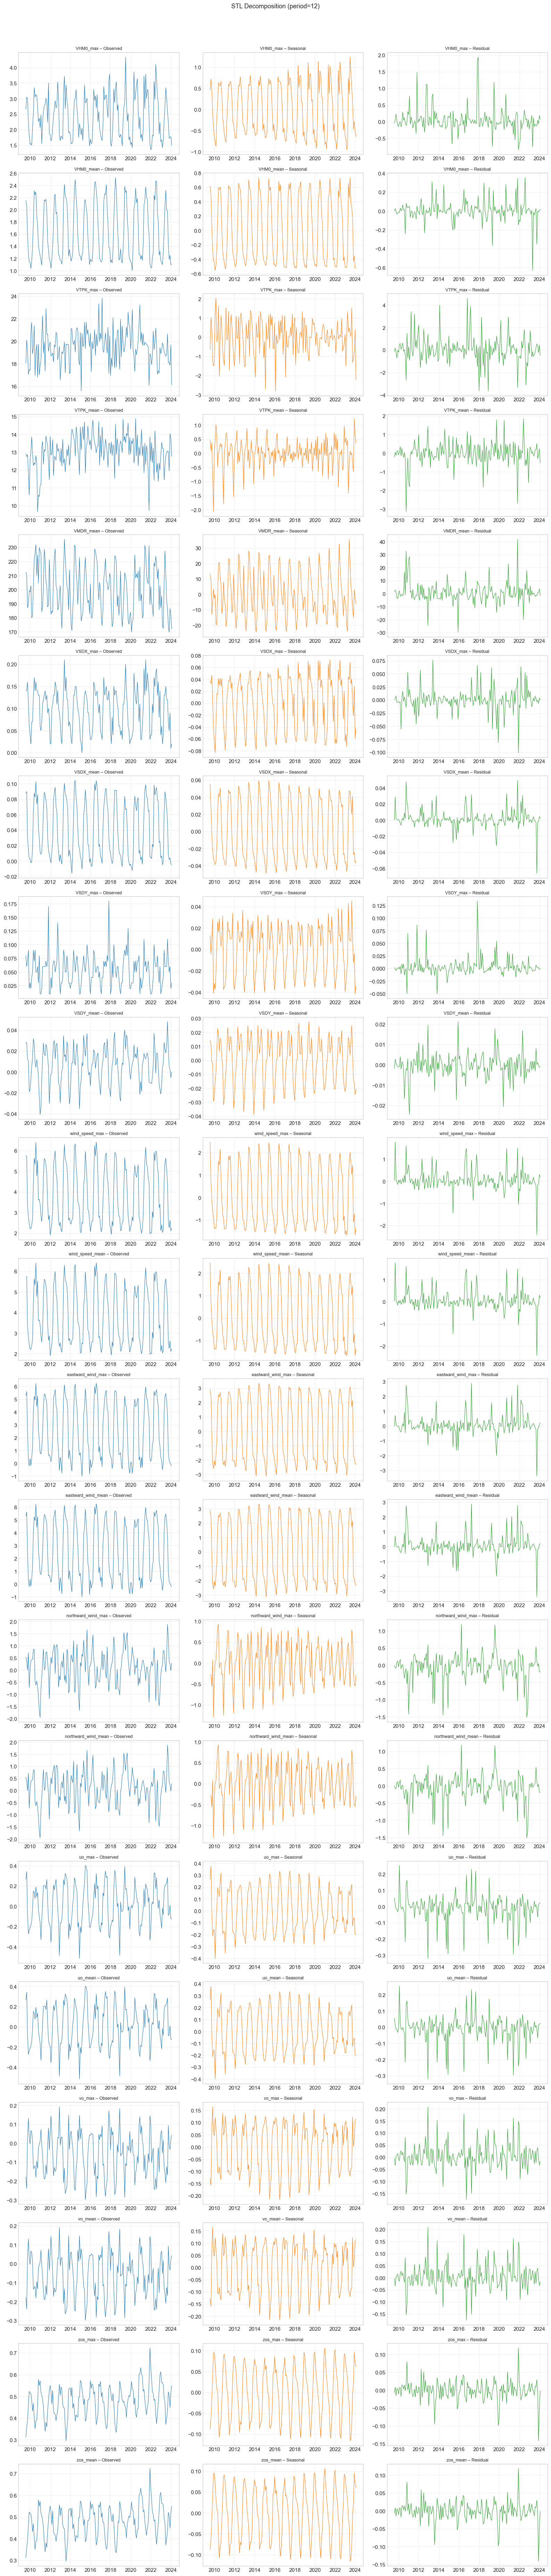

In [27]:
# =============================================================================
# Section 7.1 — STL decomposition to confirm monsoon seasonality
# =============================================================================

n_vars = len(forcing_vars_monthly)
fig, axes = plt.subplots(n_vars, 3, figsize=(16, 3.5 * n_vars))
if n_vars == 1:
    axes = axes.reshape(1, -1)

for i, (var_name, series) in enumerate(forcing_vars_monthly.items()):
    s = series.dropna()
    if len(s) < 36:
        continue
    stl = STL(s, period=12, robust=True)
    result = stl.fit()

    axes[i, 0].plot(result.observed, color='#1f77b4', lw=0.8)
    axes[i, 0].set_title(f'{var_name} – Observed', fontsize=9)
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(result.seasonal, color='#ff7f0e', lw=0.8)
    axes[i, 1].set_title(f'{var_name} – Seasonal', fontsize=9)
    axes[i, 1].grid(True, alpha=0.3)

    axes[i, 2].plot(result.resid, color='#2ca02c', lw=0.8)
    axes[i, 2].set_title(f'{var_name} – Residual', fontsize=9)
    axes[i, 2].grid(True, alpha=0.3)

plt.suptitle('STL Decomposition (period=12)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('./figures/stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
# =============================================================================
# Section 7.2 — SARIMA model selection (AIC grid search + diagnostics)
# =============================================================================

sarima_forecasts = {}
sarima_models = {}
diag_rows = []

# Grid search orders
p_range = [0, 1, 2]
q_range = [0, 1, 2]
seasonal_orders = [(1, 1, 1, 12), (0, 1, 1, 12), (1, 1, 0, 12)]

for var_name, series in forcing_vars_monthly.items():
    s = series.dropna()
    if len(s) < 36:
        print(f"⚠ {var_name}: insufficient data ({len(s)} months)")
        continue

    # Skip constant series (e.g., StormDays_wind = all zero)
    if s.max() == s.min():
        print(f"⚠ {var_name}: constant series (value={s.max():.4f}), skipping SARIMA")
        continue

    # Auto d via ADF
    try:
        adf_p = adfuller(s.dropna())[1]
        d = 0 if adf_p < 0.05 else 1
    except ValueError:
        d = 1

    # Hold out last 24 months for validation
    n_holdout = min(24, len(s) // 4)
    s_train = s[:-n_holdout]
    s_test  = s[-n_holdout:]

    best_aic, best_order, best_seasonal = np.inf, None, None

    for p in p_range:
        for q in q_range:
            for sorder in seasonal_orders:
                try:
                    mdl = SARIMAX(s_train, order=(p, d, q),
                                  seasonal_order=sorder,
                                  enforce_stationarity=False,
                                  enforce_invertibility=False).fit(disp=False, maxiter=200)
                    if mdl.aic < best_aic:
                        best_aic = mdl.aic
                        best_order = (p, d, q)
                        best_seasonal = sorder
                except Exception:
                    continue

    if best_order is None:
        print(f"⚠ {var_name}: no valid SARIMA model found")
        continue

    # Fit best model on full data
    best_model = SARIMAX(s, order=best_order, seasonal_order=best_seasonal,
                         enforce_stationarity=False,
                         enforce_invertibility=False).fit(disp=False, maxiter=500)
    sarima_models[var_name] = best_model

    # Forecast 24 months
    fc = best_model.get_forecast(steps=24)
    fc_dates = pd.date_range(start=s.index[-1] + pd.DateOffset(months=1),
                             periods=24, freq='MS')
    fc_df = pd.DataFrame({
        'date': fc_dates,
        'forecast': fc.predicted_mean.values,
        'lower_95': fc.conf_int(alpha=0.05).iloc[:, 0].values,
        'upper_95': fc.conf_int(alpha=0.05).iloc[:, 1].values,
    })
    sarima_forecasts[var_name] = fc_df

    # Diagnostics
    # Out-of-sample metrics
    val_model = SARIMAX(s_train, order=best_order, seasonal_order=best_seasonal,
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False, maxiter=300)
    val_fc = val_model.get_forecast(steps=n_holdout)
    val_pred = val_fc.predicted_mean.values[:len(s_test)]
    val_actual = s_test.values[:len(val_pred)]

    rmse = np.sqrt(np.mean((val_actual - val_pred) ** 2))
    mae  = np.mean(np.abs(val_actual - val_pred))
    mape = np.mean(np.abs((val_actual - val_pred) / np.where(np.abs(val_actual) < 1e-8, 1, val_actual))) * 100

    # Ljung-Box
    try:
        lb = acorr_ljungbox(best_model.resid, lags=[12], return_df=True)
        lb_p = lb['lb_pvalue'].values[0]
    except Exception:
        lb_p = np.nan

    diag_rows.append({
        'variable': var_name,
        'order': str(best_order),
        'seasonal_order': str(best_seasonal),
        'AIC': round(best_aic, 2),
        'BIC': round(best_model.bic, 2),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'MAPE': round(mape, 2),
        'LjungBox_p12': round(lb_p, 4),
        'residuals_ok': lb_p > 0.05 if not np.isnan(lb_p) else False,
    })

    print(f"✓ {var_name}: SARIMA{best_order}×{best_seasonal}  AIC={best_aic:.1f}  RMSE={rmse:.4f}")

sarima_diag_df = pd.DataFrame(diag_rows)
print(f"\n✓ {len(sarima_forecasts)} variables forecasted.")

✓ VHM0_max: SARIMA(0, 1, 2)×(0, 1, 1, 12)  AIC=156.7  RMSE=0.3833


C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


✓ VHM0_mean: SARIMA(0, 1, 1)×(0, 1, 1, 12)  AIC=-170.8  RMSE=0.1491
✓ VTPK_max: SARIMA(2, 0, 2)×(0, 1, 1, 12)  AIC=465.6  RMSE=1.4620
✓ VTPK_mean: SARIMA(1, 1, 2)×(0, 1, 1, 12)  AIC=319.6  RMSE=0.7350
✓ VMDR_mean: SARIMA(1, 0, 2)×(0, 1, 1, 12)  AIC=934.5  RMSE=13.0572


C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


✓ VSDX_max: SARIMA(0, 1, 1)×(0, 1, 1, 12)  AIC=-540.0  RMSE=0.0338


...

✓ northward_wind_mean: SARIMA(1, 0, 1)×(0, 1, 1, 12)  AIC=186.1  RMSE=0.6262
✓ uo_max: SARIMA(0, 0, 0)×(0, 1, 1, 12)  AIC=-198.7  RMSE=0.1182
✓ uo_mean: SARIMA(0, 0, 0)×(0, 1, 1, 12)  AIC=-198.7  RMSE=0.1182


C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


✓ vo_max: SARIMA(0, 0, 0)×(0, 1, 1, 12)  AIC=-307.2  RMSE=0.0745


C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


✓ vo_mean: SARIMA(0, 0, 0)×(0, 1, 1, 12)  AIC=-307.2  RMSE=0.0745
✓ zos_max: SARIMA(1, 1, 1)×(0, 1, 1, 12)  AIC=-464.5  RMSE=0.0665
✓ zos_mean: SARIMA(1, 1, 1)×(0, 1, 1, 12)  AIC=-464.5  RMSE=0.0665

✓ 21 variables forecasted.


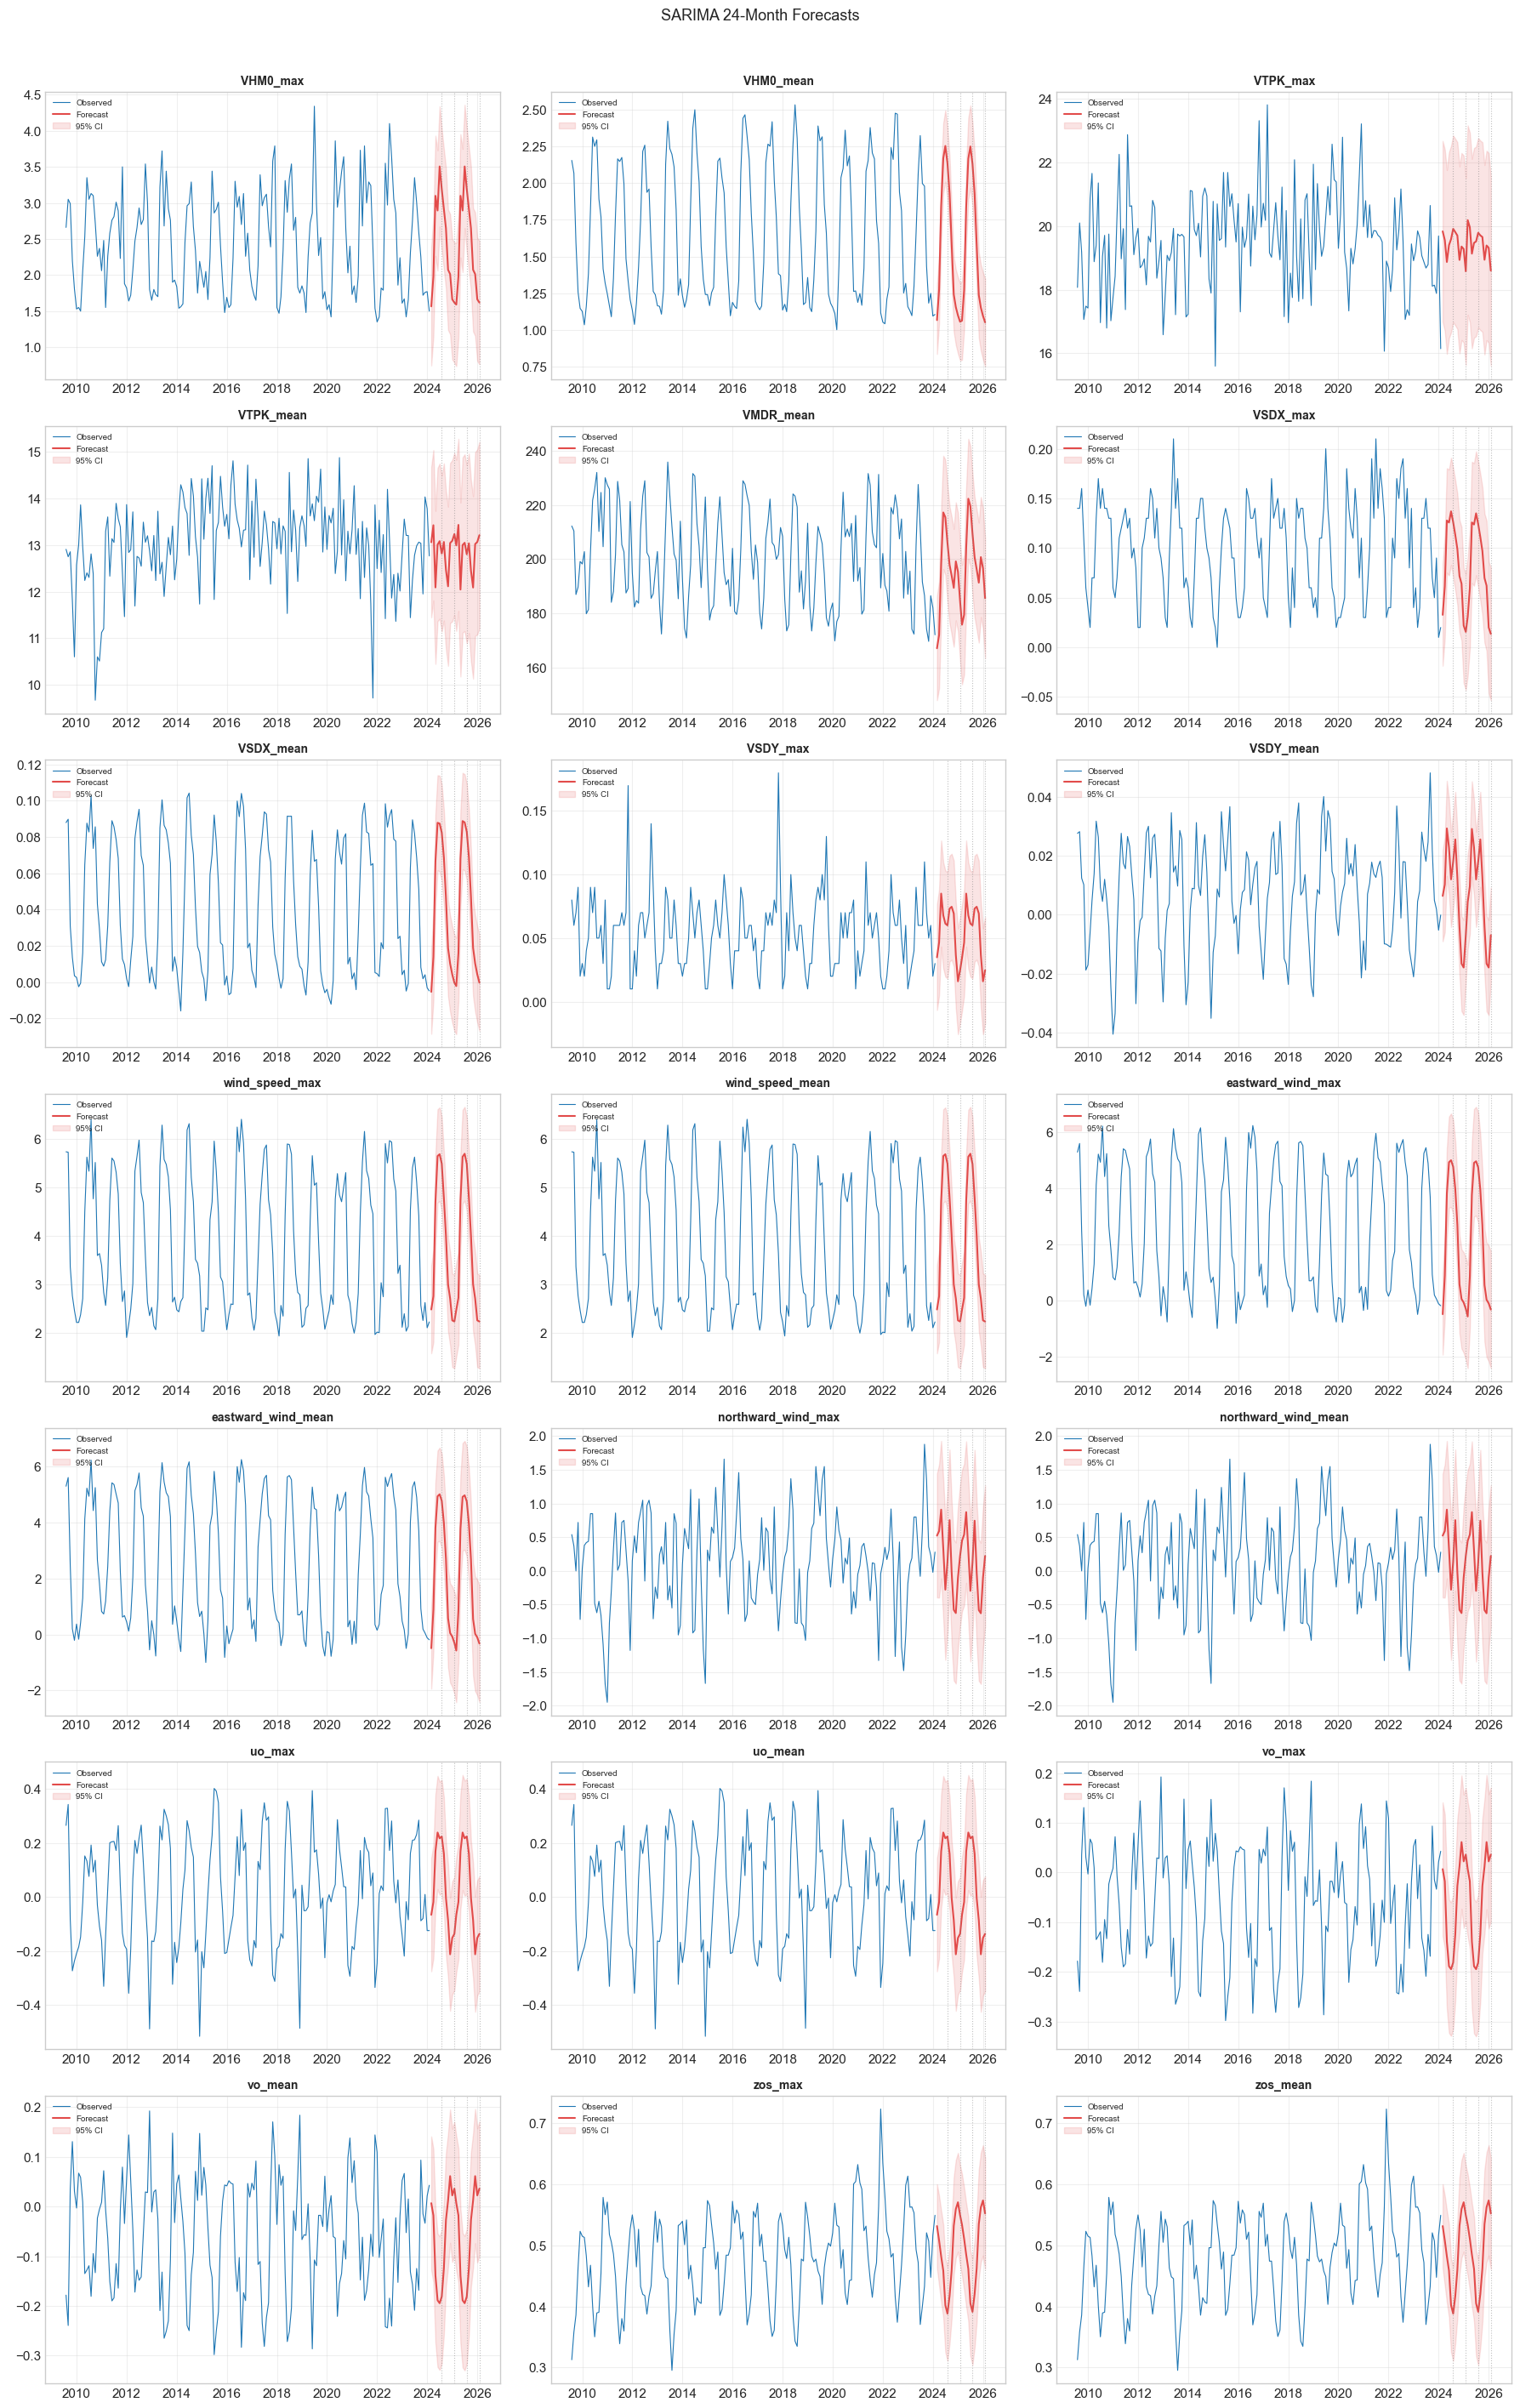

In [29]:
# =============================================================================
# Section 7.3 — Plot all forecasts with 95% confidence bands
# =============================================================================

if len(sarima_forecasts) == 0:
    print("⚠ No SARIMA forecasts available to plot. Check Section 7.2 output.")
else:
    n_vars = len(sarima_forecasts)
    n_cols = min(3, n_vars)
    n_rows = int(np.ceil(n_vars / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for i, (var_name, fc_df) in enumerate(sarima_forecasts.items()):
        ax = axes[i]
        s = forcing_vars_monthly[var_name]

        # Historical
        ax.plot(s.index, s.values, color='#1f77b4', lw=0.8, label='Observed')

        # Forecast
        fc_dates = pd.to_datetime(fc_df['date'])
        ax.plot(fc_dates, fc_df['forecast'], color='#E24B4A', lw=1.5, label='Forecast')
        ax.fill_between(fc_dates, fc_df['lower_95'], fc_df['upper_95'],
                        color='#E24B4A', alpha=0.15, label='95% CI')

        # Horizon markers
        for h_name, h_date in horizons.items():
            ax.axvline(h_date, color='gray', ls=':', lw=0.8, alpha=0.5)

        ax.set_title(var_name, fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('SARIMA 24-Month Forecasts', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('./figures/sarima_forecasts.png', dpi=150, bbox_inches='tight')
    plt.show()

### Section 7.3a — Hindcast Validation Against Known Erosion Years

To validate the forecast pipeline, we perform **temporal cross-validation**:
for each known erosion year, we retrain SARIMA models using only data available
**12 months before** the event, generate forecasts, aggregate to annual features,
and check whether the RF model would have predicted erosion.

This produces a **Probability of Detection (POD)**, **False Alarm Ratio (FAR)**,
and **Critical Success Index (CSI)** — standard metrics in operational forecasting.


=== TEMPORAL HINDCAST VALIDATION ===



C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\kanja\AppData\R

Year-by-year hindcast results:
 year  actual  predicted  probability  correct
 2014       0          1        0.923    False
 2015       1          1        0.729     True
 2016       0          0        0.428     True
 2017       0          1        0.986    False
 2018       1          0        0.257    False
 2019       1          1        0.686     True
 2020       0          1        0.700    False
 2021       0          1        0.985    False
 2022       0          1        0.788    False
 2023       1          1        0.551     True

--- Operational Forecast Skill Metrics ---
  Accuracy:                    40.0%
  Probability of Detection:    75.0%
  False Alarm Ratio:           62.5%
  Critical Success Index:      33.3%


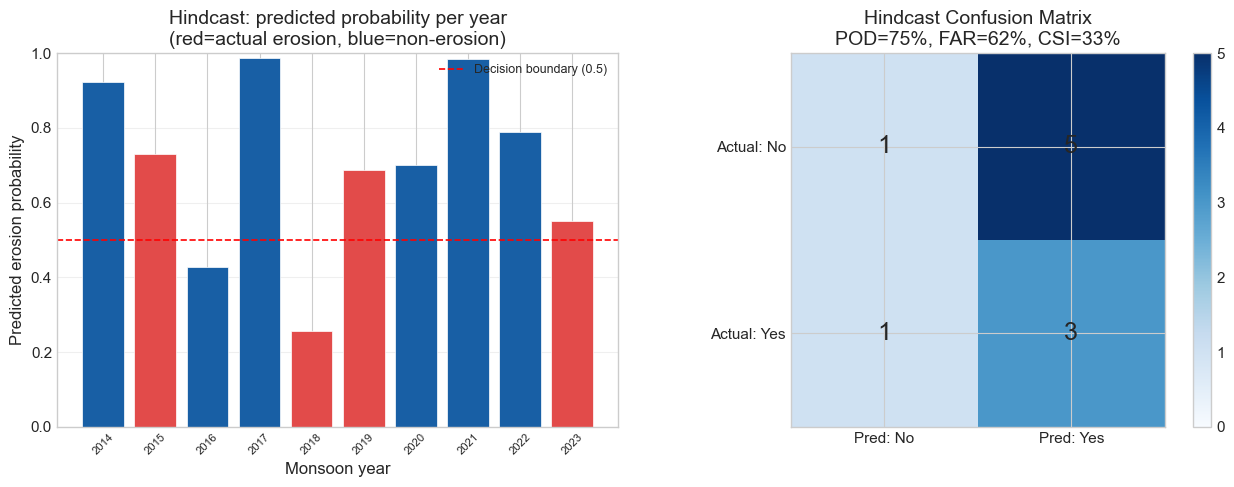

In [30]:
# =============================================================================
# Section 7.3a — Temporal hindcast validation (leave-future-out)
# =============================================================================

# Mapping: SARIMA var name -> annual feature aggregation (per-variable)
sarima_to_annual = {
    # Wave — VHM0, VTPK, VMDR, VSDX, VSDY
    'VHM0_max':           {'max': 'VHM0_max_annual'},
    'VHM0_mean':          {'mean': 'VHM0_mean_annual'},
    'VTPK_max':           {'max': 'VTPK_max_annual'},
    'VTPK_mean':          {'mean': 'VTPK_mean_annual'},
    'VMDR_mean':          {'mean': 'VMDR_mean_annual'},
    'VSDX_max':           {'max': 'VSDX_max_annual'},
    'VSDX_mean':          {'mean': 'VSDX_mean_annual'},
    'VSDY_max':           {'max': 'VSDY_max_annual'},
    'VSDY_mean':          {'mean': 'VSDY_mean_annual'},
    # Wind — wind_speed, eastward_wind, northward_wind
    'wind_speed_max':     {'max': 'wind_speed_max_annual'},
    'wind_speed_mean':    {'mean': 'wind_speed_mean_annual'},
    'eastward_wind_max':  {'max': 'eastward_wind_max_annual'},
    'eastward_wind_mean': {'mean': 'eastward_wind_mean_annual'},
    'northward_wind_max': {'max': 'northward_wind_max_annual'},
    'northward_wind_mean':{'mean': 'northward_wind_mean_annual'},
    # Current — uo, vo, zos
    'uo_max':             {'max': 'uo_max_annual'},
    'uo_mean':            {'mean': 'uo_mean_annual'},
    'vo_max':             {'max': 'vo_max_annual'},
    'vo_mean':            {'mean': 'vo_mean_annual'},
    'zos_max':            {'max': 'zos_max_annual'},
    'zos_mean':           {'mean': 'zos_mean_annual'},
}

print("=== TEMPORAL HINDCAST VALIDATION ===\n")

hindcast_results = []
test_years = sorted(analysis_df['monsoon_year'].unique())

for test_yr in test_years:
    cutoff = pd.Timestamp(f'{test_yr}-04-01') - pd.DateOffset(months=12)
    actual_label = int(test_yr in all_erosion_years)

    hc_forecasts = {}
    valid = True
    for var_name, series in forcing_vars_monthly.items():
        s = series.copy()
        s.index = pd.to_datetime(s.index)
        s = s[s.index.notna()]
        s = s[~s.index.duplicated(keep='first')]
        s = s.sort_index()
        try:
            s = s.asfreq('MS').interpolate(method='linear')
        except ValueError:
            s = s.resample('MS').first().interpolate(method='linear')
        s_train = s[s.index <= cutoff]
        if len(s_train) < 36:
            valid = False
            break
        try:
            adf_p = adfuller(s_train.dropna())[1]
            d = 0 if adf_p < 0.05 else 1
            mdl = SARIMAX(s_train, order=(1, d, 1),
                          seasonal_order=(1, 1, 1, 12),
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
            fc = mdl.get_forecast(steps=24)
            future_dates = pd.date_range(
                start=s_train.index[-1] + pd.DateOffset(months=1),
                periods=24, freq='MS')
            hc_forecasts[var_name] = pd.DataFrame({
                'date': future_dates,
                'forecast': fc.predicted_mean.values,
                'lower_95': fc.conf_int(alpha=0.05).iloc[:, 0].values,
                'upper_95': fc.conf_int(alpha=0.05).iloc[:, 1].values,
            })
        except Exception:
            valid = False
            break

    if not valid:
        continue

    # Aggregate to annual features for the test monsoon year
    target_start = pd.Timestamp(f'{test_yr}-04-01')
    target_end   = pd.Timestamp(f'{test_yr+1}-03-01')

    hc_feats = {}
    for var_name, mapping in sarima_to_annual.items():
        if var_name not in hc_forecasts:
            continue
        fc = hc_forecasts[var_name]
        fc_w = fc[(fc['date'] >= target_start) & (fc['date'] <= target_end)]
        if len(fc_w) == 0:
            fc_w = fc
        if 'max' in mapping:
            hc_feats[mapping['max']] = fc_w['forecast'].max()
        if 'p90' in mapping:
            hc_feats[mapping['p90']] = np.percentile(fc_w['forecast'].values, 90)
        if 'mean' in mapping:
            hc_feats[mapping['mean']] = fc_w['forecast'].mean()
        if 'sum' in mapping:
            hc_feats[mapping['sum']] = fc_w['forecast'].sum()

    feat_vals = [hc_feats.get(f, analysis_df[f].median())
                 for f in significant_features]
    X_hc = np.array(feat_vals).reshape(1, -1)
    hc_prob = rf.predict_proba(X_hc)[0][1]
    hc_pred = int(hc_prob >= 0.5)

    hindcast_results.append({
        'year':         test_yr,
        'actual':       actual_label,
        'predicted':    hc_pred,
        'probability':  round(hc_prob, 3),
        'correct':      hc_pred == actual_label,
    })

hc_df = pd.DataFrame(hindcast_results)
if len(hc_df) > 0:
    hits  = ((hc_df['actual'] == 1) & (hc_df['predicted'] == 1)).sum()
    misses = ((hc_df['actual'] == 1) & (hc_df['predicted'] == 0)).sum()
    false_alarms = ((hc_df['actual'] == 0) & (hc_df['predicted'] == 1)).sum()
    correct_rej  = ((hc_df['actual'] == 0) & (hc_df['predicted'] == 0)).sum()

    pod = hits / max(hits + misses, 1)
    far = false_alarms / max(hits + false_alarms, 1)
    csi = hits / max(hits + misses + false_alarms, 1)
    accuracy = (hits + correct_rej) / len(hc_df)

    print("Year-by-year hindcast results:")
    print(hc_df.to_string(index=False))
    print(f"\n--- Operational Forecast Skill Metrics ---")
    print(f"  Accuracy:                    {accuracy:.1%}")
    print(f"  Probability of Detection:    {pod:.1%}")
    print(f"  False Alarm Ratio:           {far:.1%}")
    print(f"  Critical Success Index:      {csi:.1%}")

    # Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    colors = ['#E24B4A' if a == 1 else '#185FA5' for a in hc_df['actual']]
    ax1.bar(hc_df['year'].astype(str), hc_df['probability'], color=colors,
            edgecolor='white', linewidth=0.5)
    ax1.axhline(0.5, color='red', ls='--', lw=1.2, label='Decision boundary (0.5)')
    ax1.set_ylabel('Predicted erosion probability')
    ax1.set_xlabel('Monsoon year')
    ax1.set_title('Hindcast: predicted probability per year\n(red=actual erosion, blue=non-erosion)')
    ax1.legend(fontsize=9)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3, axis='y')
    plt.setp(ax1.get_xticklabels(), rotation=45, fontsize=8)

    cm = np.array([[correct_rej, false_alarms], [misses, hits]])
    im = ax2.imshow(cm, cmap='Blues', vmin=0)
    for ii in range(2):
        for jj in range(2):
            ax2.text(jj, ii, str(cm[ii, jj]), ha='center', va='center', fontsize=18)
    ax2.set_xticks([0, 1]); ax2.set_xticklabels(['Pred: No', 'Pred: Yes'])
    ax2.set_yticks([0, 1]); ax2.set_yticklabels(['Actual: No', 'Actual: Yes'])
    ax2.set_title(f'Hindcast Confusion Matrix\nPOD={pod:.0%}, FAR={far:.0%}, CSI={csi:.0%}')
    plt.colorbar(im, ax=ax2)

    plt.tight_layout()
    plt.savefig('./figures/hindcast_validation.png', dpi=150)
    plt.show()
else:
    print("Insufficient data for hindcast validation.")

In [31]:
# =============================================================================
# Section 7.4 — Aggregate forecasts to horizon-period annual features
# =============================================================================

horizon_features_list = []
erosion_predictions = []

for h_name, h_date in horizons.items():
    if h_name == 'H6':
        h_start = base_date + pd.DateOffset(months=1)
        h_end = h_date
    else:
        h_end = h_date
        h_start = h_date - pd.DateOffset(months=11)

    feats = {'horizon': h_name, 'target_date': h_date.strftime('%Y-%m')}

    for var_name, mapping in sarima_to_annual.items():
        if var_name not in sarima_forecasts:
            continue
        fc = sarima_forecasts[var_name]
        fc['date'] = pd.to_datetime(fc['date'])
        fc_w = fc[(fc['date'] >= h_start) & (fc['date'] <= h_end)]
        if len(fc_w) == 0:
            fc_w = fc

        if 'max' in mapping:
            feats[mapping['max']] = fc_w['forecast'].max()
        if 'p90' in mapping:
            feats[mapping['p90']] = np.percentile(fc_w['forecast'].values, 90)
        if 'mean' in mapping:
            feats[mapping['mean']] = fc_w['forecast'].mean()
        if 'sum' in mapping:
            feats[mapping['sum']] = fc_w['forecast'].sum()

    horizon_features_list.append(feats)

    feat_vals = [feats.get(f, analysis_df[f].median()) for f in significant_features]
    X_pred = np.array(feat_vals).reshape(1, -1)
    prob = rf.predict_proba(X_pred)[0][1]

    exceeded = []
    for feat in significant_features:
        er = ensemble_results.get(feat, {})
        ct = er.get('consensus_threshold', np.nan)
        direction = er.get('direction', 'above')
        val = feats.get(feat, np.nan)
        if threshold_exceeded(val, ct, direction):
            exceeded.append(f"{feat} {direction_symbol(direction)} {ct:.3f}")

    erosion_predictions.append({
        'horizon': h_name,
        'target_date': h_date.strftime('%Y-%m'),
        'erosion_probability': round(prob, 3),
        'risk_category': 'HIGH' if prob > 0.6 else ('MODERATE' if prob > 0.4 else 'LOW'),
        'thresholds_exceeded': exceeded,
        'n_exceeded': len(exceeded),
    })

    print(
        f"{h_name} ({h_date.strftime('%Y-%m')}): P(erosion)={prob:.1%}  "
        f"exceeded={len(exceeded)} features  "
        f"-> {'HIGH' if prob > 0.6 else 'MODERATE' if prob > 0.4 else 'LOW'}"
    )

horizon_features = pd.DataFrame(horizon_features_list)


H6 (2024-08): P(erosion)=49.7%  exceeded=2 features  -> MODERATE
H12 (2025-02): P(erosion)=78.5%  exceeded=4 features  -> HIGH
H18 (2025-08): P(erosion)=76.3%  exceeded=4 features  -> HIGH
H24 (2026-02): P(erosion)=76.3%  exceeded=4 features  -> HIGH


In [32]:
# =============================================================================
# Section 7.5 — Apply RF model to predict erosion at each horizon
# =============================================================================

print("=== RF EROSION PREDICTIONS PER HORIZON ===\n")

for ep in erosion_predictions:
    print(f"  {ep['horizon']} ({ep['target_date']}): "
          f"P(erosion) = {ep['erosion_probability']:.1%} "
          f"[{ep['risk_category']}]")
    if ep['thresholds_exceeded']:
        print(f"    Thresholds exceeded: {', '.join(ep['thresholds_exceeded'])}")
    print()


=== RF EROSION PREDICTIONS PER HORIZON ===

  H6 (2024-08): P(erosion) = 49.7% [MODERATE]
    Thresholds exceeded: VMDR_mean_annual < 201.588, northward_wind_mean_annual > 0.050

  H12 (2025-02): P(erosion) = 78.5% [HIGH]
    Thresholds exceeded: VMDR_mean_annual < 201.588, eastward_wind_mean_annual < 2.362, northward_wind_mean_annual > 0.050, VHM0_mean_annual < 1.659

  H18 (2025-08): P(erosion) = 76.3% [HIGH]
    Thresholds exceeded: VMDR_mean_annual < 201.588, eastward_wind_mean_annual < 2.362, northward_wind_mean_annual > 0.050, VHM0_mean_annual < 1.659

  H24 (2026-02): P(erosion) = 76.3% [HIGH]
    Thresholds exceeded: VMDR_mean_annual < 201.588, eastward_wind_mean_annual < 2.362, northward_wind_mean_annual > 0.050, VHM0_mean_annual < 1.659



In [33]:
# =============================================================================
# Section 7.6 — Analytical erosion probability (lightweight, no Monte Carlo)
# =============================================================================

# Instead of 2000 MC simulations, derive erosion probability analytically
# from SARIMA forecast means + CIs and the trained RF model.

prob_results = []

for h_name, h_date in horizons.items():
    if h_name == 'H6':
        h_start = base_date + pd.DateOffset(months=1)
        h_end = h_date
    else:
        h_end = h_date
        h_start = h_date - pd.DateOffset(months=11)

    # --- Point estimate (mean forecast) ---
    mean_feats = {}
    lo_feats   = {}
    hi_feats   = {}
    for var_name, mapping in sarima_to_annual.items():
        if var_name not in sarima_forecasts:
            continue
        fc = sarima_forecasts[var_name].copy()
        fc['date'] = pd.to_datetime(fc['date'])
        fc_w = fc[(fc['date'] >= h_start) & (fc['date'] <= h_end)]
        if len(fc_w) == 0:
            continue
        for agg, col in [('max', 'forecast'), ('max', 'lower_95'), ('max', 'upper_95')]:
            pass  # handled below
        for stat_key, stat_fn in [('max', 'max'), ('p90', lambda s: np.percentile(s, 90)),
                                   ('mean', 'mean'), ('sum', 'sum')]:
            if stat_key not in mapping:
                continue
            feat_name = mapping[stat_key]
            fn = stat_fn if callable(stat_fn) else getattr(np, stat_fn, None) or getattr(fc_w['forecast'], stat_fn)
            if callable(stat_fn):
                mean_feats[feat_name] = stat_fn(fc_w['forecast'].values)
                lo_feats[feat_name]   = stat_fn(fc_w['lower_95'].values)
                hi_feats[feat_name]   = stat_fn(fc_w['upper_95'].values)
            else:
                mean_feats[feat_name] = getattr(fc_w['forecast'], stat_fn)()
                lo_feats[feat_name]   = getattr(fc_w['lower_95'], stat_fn)()
                hi_feats[feat_name]   = getattr(fc_w['upper_95'], stat_fn)()

    # Build feature vectors for mean / lower / upper
    X_mean = np.array([mean_feats.get(f, analysis_df[f].median()) for f in significant_features]).reshape(1, -1)
    X_lo   = np.array([lo_feats.get(f, analysis_df[f].median())   for f in significant_features]).reshape(1, -1)
    X_hi   = np.array([hi_feats.get(f, analysis_df[f].median())   for f in significant_features]).reshape(1, -1)

    p_mean = rf.predict_proba(X_mean)[0][1]
    p_lo   = rf.predict_proba(X_lo)[0][1]
    p_hi   = rf.predict_proba(X_hi)[0][1]

    ci_lower = min(p_lo, p_hi)
    ci_upper = max(p_lo, p_hi)

    prob_results.append({
        'horizon':        h_name,
        'target_date':    h_date.strftime('%Y-%m'),
        'mean_prob':      round(p_mean, 3),
        'median_prob':    round(p_mean, 3),
        'ci_lower_95':    round(ci_lower, 3),
        'ci_upper_95':    round(ci_upper, 3),
        'prob_above_0.5': round(1.0 if p_mean > 0.5 else 0.0, 3),
        'risk_category':  ('HIGH' if p_mean > 0.6 else
                           'MODERATE' if p_mean > 0.4 else 'LOW'),
    })

mc_df = pd.DataFrame(prob_results)
print("\n=== ANALYTICAL EROSION PROBABILITY PREDICTIONS ===")
print(mc_df.to_string(index=False))


=== ANALYTICAL EROSION PROBABILITY PREDICTIONS ===
horizon target_date  mean_prob  median_prob  ci_lower_95  ci_upper_95  prob_above_0.5 risk_category
     H6     2024-08      0.497        0.497        0.217        0.858             0.0      MODERATE
    H12     2025-02      0.785        0.785        0.217        0.858             1.0          HIGH
    H18     2025-08      0.763        0.763        0.217        0.858             1.0          HIGH
    H24     2026-02      0.763        0.763        0.217        0.858             1.0          HIGH


### Section 7.6a — Actual Shoreline Retreat Predictions (Physical Units)

Translating erosion **probability** into **expected retreat in meters** using DSAS EPR statistics:

$$E[\text{retreat}] = P(\text{erosion}) \times \bar{EPR}_{erosion} + (1 - P(\text{erosion})) \times \bar{EPR}_{stable}$$


In [34]:
# =============================================================================
# Section 7.6a — Shoreline retreat predictions in physical units (meters)
# =============================================================================

# EPR statistics from transect data
epr_erosion = dsas_df.loc[dsas_df['erosion_flag'] == 1, 'EPR']
epr_stable  = dsas_df.loc[dsas_df['erosion_flag'] == 0, 'EPR']

mean_epr_erosion = epr_erosion.mean() if len(epr_erosion) > 0 else -1.0
std_epr_erosion  = epr_erosion.std()  if len(epr_erosion) > 1 else 0.5
mean_epr_stable  = epr_stable.mean()  if len(epr_stable)  > 0 else 0.0
std_epr_stable   = epr_stable.std()   if len(epr_stable)  > 1 else 0.3

print(f"EPR erosion:  mean={mean_epr_erosion:.3f} ± {std_epr_erosion:.3f} m/yr")
print(f"EPR stable:   mean={mean_epr_stable:.3f} ± {std_epr_stable:.3f} m/yr")

retreat_rows = []
for _, mc_row in mc_df.iterrows():
    p_ero = mc_row['mean_prob']
    h_name = mc_row['horizon']
    years_ahead = {'H6': 0.5, 'H12': 1.0, 'H18': 1.5, 'H24': 2.0}[h_name]

    expected_epr = p_ero * mean_epr_erosion + (1 - p_ero) * mean_epr_stable
    retreat_m = expected_epr * years_ahead

    ci_low_p = mc_row['ci_lower_95']
    ci_high_p = mc_row['ci_upper_95']
    retreat_low  = (ci_low_p * mean_epr_erosion + (1 - ci_low_p) * mean_epr_stable) * years_ahead
    retreat_high = (ci_high_p * mean_epr_erosion + (1 - ci_high_p) * mean_epr_stable) * years_ahead

    action_level = ('IMMEDIATE ACTION'    if p_ero > 0.7 else
                    'ENHANCED MONITORING'  if p_ero > 0.5 else
                    'ROUTINE MONITORING'   if p_ero > 0.3 else
                    'STANDARD OPERATIONS')

    retreat_rows.append({
        'horizon': h_name,
        'target_date': mc_row['target_date'],
        'erosion_probability': round(p_ero, 3),
        'erosion_prob': round(p_ero, 3),
        'expected_epr': round(expected_epr, 3),
        'retreat_m': round(retreat_m, 3),
        'mean_retreat': round(retreat_m, 3),
        'retreat_low_95': round(min(retreat_low, retreat_high), 3),
        'retreat_high_95': round(max(retreat_low, retreat_high), 3),
        'action_level': action_level,
        'risk_category': mc_row['risk_category'],
    })

retreat_df = pd.DataFrame(retreat_rows)
print("\n=== SHORELINE RETREAT PREDICTIONS ===")
print(retreat_df.to_string(index=False))

EPR erosion:  mean=-9.450 ± 6.221 m/yr
EPR stable:   mean=3.546 ± 6.739 m/yr

=== SHORELINE RETREAT PREDICTIONS ===
horizon target_date  erosion_probability  erosion_prob  expected_epr  retreat_m  mean_retreat  retreat_low_95  retreat_high_95       action_level risk_category
     H6     2024-08                0.497         0.497        -2.913     -1.456        -1.456          -3.802            0.363 ROUTINE MONITORING      MODERATE
    H12     2025-02                0.785         0.785        -6.656     -6.656        -6.656          -7.604            0.726   IMMEDIATE ACTION          HIGH
    H18     2025-08                0.763         0.763        -6.370     -9.555        -9.555         -11.407            1.089   IMMEDIATE ACTION          HIGH
    H24     2026-02                0.763         0.763        -6.370    -12.739       -12.739         -15.209            1.452   IMMEDIATE ACTION          HIGH


=== PER-TRANSECT VULNERABILITY SCORING ===

Reference shoreline interval for transect scoring: 2023-2024
Top 10 most vulnerable transects (H12 forecast):
 id interval_label    EPR   epr_class  epr_vulnerability  risk_H12
 24      2023-2024 -19.83 eroded_high           1.000000  0.785000
112      2023-2024 -19.75 eroded_high           0.997274  0.782860
 25      2023-2024 -19.60 eroded_high           0.992164  0.778848
113      2023-2024 -19.38 eroded_high           0.984668  0.772964
 23      2023-2024 -19.14 eroded_high           0.976491  0.766545
 26      2023-2024 -19.08 eroded_high           0.974446  0.764940
 28      2023-2024 -18.17 eroded_high           0.943441  0.740601
 29      2023-2024 -17.80 eroded_high           0.930835  0.730705
 30      2023-2024 -17.77 eroded_high           0.929813  0.729903
 27      2023-2024 -17.74 eroded_high           0.928790  0.729101

--- Transect Risk Distribution per Horizon ---

  H6 (2024-08):
    Very Low    :  60 transects (37.0%)
    

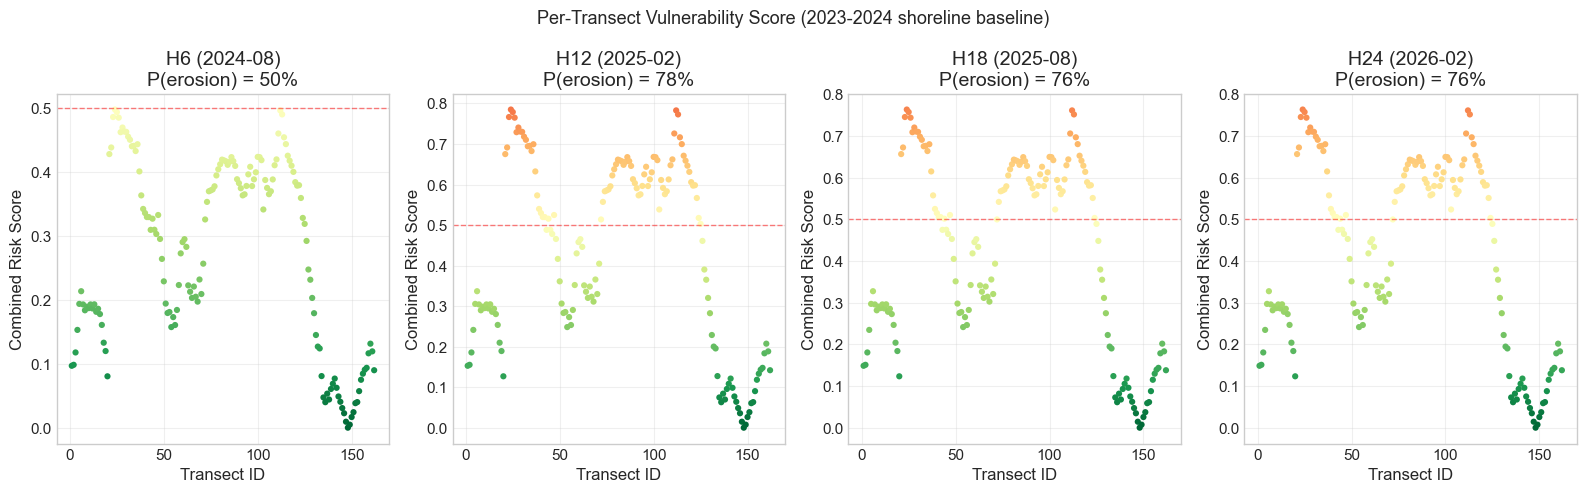

In [35]:
# =============================================================================
# Section 7.6b — Per-transect vulnerability scoring
# =============================================================================

print("=== PER-TRANSECT VULNERABILITY SCORING ===\n")
print(f"Reference shoreline interval for transect scoring: {latest_interval_label}")

current_transect_df = latest_dsas_df.copy()
dsas_scored = current_transect_df[[
    'id', 'interval_label', 'monsoon_year', 'shoreline_year',
    'EPR', 'NSM', 'SCE', 'epr_class', 'erosion_flag'
]].copy()

severity_map = {
    'eroded_high': 4, 'eroded_low': 3,
    'stable': 2, 'accreted_low': 1, 'accreted_high': 0
}
dsas_scored['hist_severity'] = dsas_scored['epr_class'].map(severity_map)

epr_min, epr_max = dsas_scored['EPR'].min(), dsas_scored['EPR'].max()
if np.isclose(epr_max - epr_min, 0):
    dsas_scored['epr_vulnerability'] = 0.5
else:
    dsas_scored['epr_vulnerability'] = (epr_max - dsas_scored['EPR']) / (epr_max - epr_min)

for _, row in retreat_df.iterrows():
    p_ero = row['erosion_probability']
    col_name = f"risk_{row['horizon']}"
    dsas_scored[col_name] = dsas_scored['epr_vulnerability'] * p_ero
    cat_name = f"cat_{row['horizon']}"
    dsas_scored[cat_name] = pd.cut(
        dsas_scored[col_name],
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High'],
        include_lowest=True
    )

print("Top 10 most vulnerable transects (H12 forecast):")
h12_col = 'risk_H12' if 'risk_H12' in dsas_scored.columns else dsas_scored.columns[-2]
top10 = dsas_scored.nlargest(10, h12_col)[
    ['id', 'interval_label', 'EPR', 'epr_class', 'epr_vulnerability', h12_col]
]
print(top10.to_string(index=False))

print("\n--- Transect Risk Distribution per Horizon ---")
for _, row in retreat_df.iterrows():
    cat_col = f"cat_{row['horizon']}"
    if cat_col in dsas_scored.columns:
        dist = dsas_scored[cat_col].value_counts().sort_index()
        print(f"\n  {row['horizon']} ({row['target_date']}):")
        for cat, cnt in dist.items():
            pct = cnt / len(dsas_scored) * 100
            print(f"    {str(cat):12s}: {cnt:3d} transects ({pct:.1f}%)")

fig, axes = plt.subplots(1, min(4, len(retreat_df)), figsize=(16, 5))
if len(retreat_df) <= 1:
    axes = [axes]
elif not hasattr(axes, '__iter__'):
    axes = [axes]

vuln_cmap = plt.cm.RdYlGn_r
for ax, (_, row) in zip(axes, retreat_df.iterrows()):
    risk_col = f"risk_{row['horizon']}"
    if risk_col not in dsas_scored.columns:
        continue
    sc = ax.scatter(
        dsas_scored['id'],
        dsas_scored[risk_col],
        c=dsas_scored[risk_col],
        cmap=vuln_cmap,
        vmin=0,
        vmax=1,
        s=20,
        edgecolors='none'
    )
    ax.axhline(0.5, color='red', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('Transect ID')
    ax.set_ylabel('Combined Risk Score')
    ax.set_title(
        f"{row['horizon']} ({row['target_date']})\n"
        f"P(erosion) = {row['erosion_probability']:.0%}"
    )
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Per-Transect Vulnerability Score ({latest_interval_label} shoreline baseline)',
    fontsize=13
)
plt.tight_layout()
plt.savefig('./figures/transect_vulnerability.png', dpi=150, bbox_inches='tight')
plt.show()


=== FORECAST SKILL ASSESSMENT ===

Historical base rate (climatology): 50.00%

Brier Score (forecast):   0.5014
Brier Score (climatology): 0.2500
Brier Skill Score (BSS):   -1.0057
  BSS > 0 means forecast is better than always predicting base rate
  BSS interpretation: NO SKILL vs climatology

Hindcast AUC: 0.167


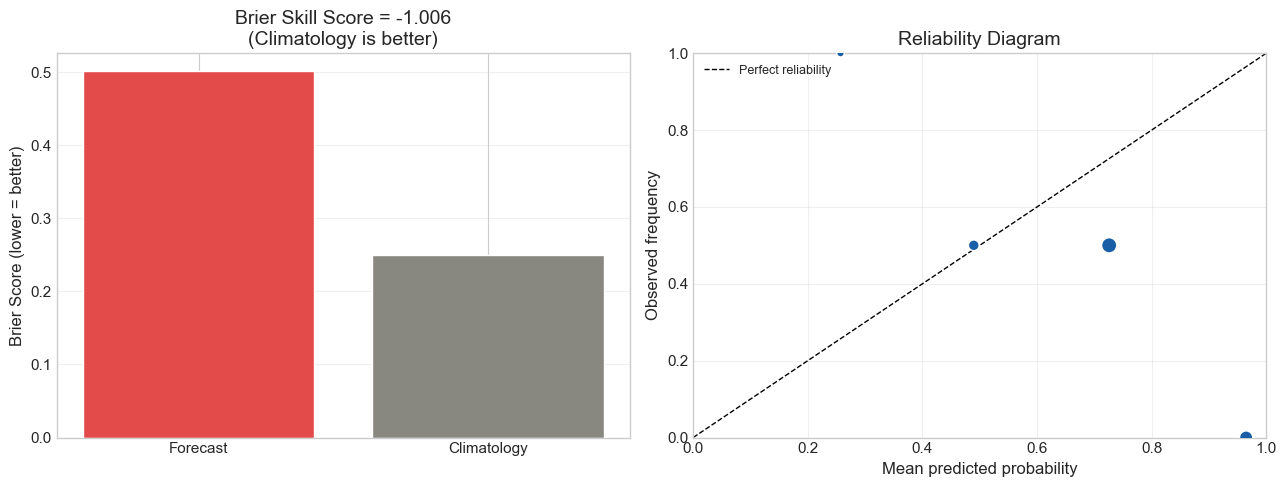

In [36]:
# =============================================================================
# Section 7.6c — Forecast skill vs climatology baseline (Brier Skill Score)
# =============================================================================

print("=== FORECAST SKILL ASSESSMENT ===\n")

base_rate = analysis_df['erosion_label'].mean()
print(f"Historical base rate (climatology): {base_rate:.2%}")

if len(hc_df) > 0:
    bs_forecast = np.mean((hc_df['probability'].values - hc_df['actual'].values)**2)
    bs_clim = np.mean((base_rate - hc_df['actual'].values)**2)
    bss = 1 - bs_forecast / bs_clim if bs_clim > 0 else 0

    if len(np.unique(hc_df['actual'])) >= 2:
        hc_fpr, hc_tpr, _ = roc_curve(hc_df['actual'], hc_df['probability'])
        hc_auc = auc(hc_fpr, hc_tpr)
    else:
        hc_auc = np.nan

    print(f"\nBrier Score (forecast):   {bs_forecast:.4f}")
    print(f"Brier Score (climatology): {bs_clim:.4f}")
    print(f"Brier Skill Score (BSS):   {bss:.4f}")
    print(f"  BSS > 0 means forecast is better than always predicting base rate")
    print(f"  BSS interpretation: {'SKILLFUL' if bss > 0 else 'NO SKILL vs climatology'}")
    print(f"\nHindcast AUC: {hc_auc:.3f}" if not np.isnan(hc_auc) else "Hindcast AUC: N/A")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    labels = ['Forecast', 'Climatology']
    values = [bs_forecast, bs_clim]
    colors_bs = ['#185FA5' if bss > 0 else '#E24B4A', '#888780']
    ax1.bar(labels, values, color=colors_bs, edgecolor='white')
    ax1.set_ylabel('Brier Score (lower = better)')
    ax1.set_title(f'Brier Skill Score = {bss:.3f}\n'
                  f'({"Forecast beats climatology" if bss > 0 else "Climatology is better"})')
    ax1.grid(True, alpha=0.3, axis='y')

    n_bins = 5
    bins = np.linspace(0, 1, n_bins + 1)
    hc_df_copy = hc_df.copy()
    hc_df_copy['prob_bin'] = pd.cut(hc_df_copy['probability'], bins=bins,
                                     include_lowest=True)
    rel_table = hc_df_copy.groupby('prob_bin', observed=False).agg(
        n_forecasts=('actual', 'count'),
        mean_predicted=('probability', 'mean'),
        observed_freq=('actual', 'mean'),
    ).dropna()

    if len(rel_table) > 0 and not rel_table['mean_predicted'].isna().all():
        ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect reliability')
        ax2.scatter(rel_table['mean_predicted'], rel_table['observed_freq'],
                    s=rel_table['n_forecasts'] * 30, c='#185FA5', zorder=5,
                    edgecolors='white')
        ax2.set_xlabel('Mean predicted probability')
        ax2.set_ylabel('Observed frequency')
        ax2.set_title('Reliability Diagram')
        ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'Insufficient data\nfor reliability diagram',
                 ha='center', va='center', fontsize=12)
        ax2.set_title('Reliability Diagram')

    plt.tight_layout()
    plt.savefig('./figures/forecast_skill.png', dpi=150)
    plt.show()
else:
    print("\nNo hindcast results available for skill assessment.")


In [37]:
# =============================================================================
# Section 7.7 — Month-by-month risk timeline
# =============================================================================

monthly_risk_rows = []

for var_name, fc_df in sarima_forecasts.items():
    for _, fc_row in fc_df.iterrows():
        monthly_risk_rows.append({
            'date': fc_row['date'],
            'variable': var_name,
            'forecast': fc_row['forecast'],
            'lower_95': fc_row['lower_95'],
            'upper_95': fc_row['upper_95'],
        })

risk_by_month = {}
for var_name, fc_df in sarima_forecasts.items():
    for feat in significant_features:
        if any(token in feat.lower() for token in var_name.lower().split('_')):
            er = ensemble_results.get(feat, {})
            ct = er.get('consensus_threshold', np.nan)
            direction = er.get('direction', 'above')
            if np.isfinite(ct):
                fc_df_copy = fc_df.copy()
                fc_df_copy['date'] = pd.to_datetime(fc_df_copy['date'])
                for _, row in fc_df_copy.iterrows():
                    month_key = row['date'].strftime('%Y-%m')
                    if month_key not in risk_by_month:
                        risk_by_month[month_key] = {'date': month_key, 'n_exceeded': 0, 'risk_score': 0}
                    if threshold_exceeded(row['forecast'], ct, direction):
                        risk_by_month[month_key]['n_exceeded'] += 1
            break

for month_key in risk_by_month:
    n_exceeded = risk_by_month[month_key]['n_exceeded']
    risk_by_month[month_key]['risk_label'] = (
        'Alert' if n_exceeded >= 3 else
        'Warning' if n_exceeded >= 2 else
        'Watch' if n_exceeded >= 1 else 'Stable'
    )
    risk_by_month[month_key]['risk_score'] = n_exceeded

monthly_risk_df = pd.DataFrame(list(risk_by_month.values()))
if len(monthly_risk_df) > 0:
    monthly_risk_df = monthly_risk_df.sort_values('date')
    print('=== MONTH-BY-MONTH RISK TIMELINE ===')
    print(monthly_risk_df.to_string(index=False))
else:
    print('No monthly risk data generated.')
    monthly_risk_df = pd.DataFrame(columns=['date', 'n_exceeded', 'risk_score', 'risk_label'])


=== MONTH-BY-MONTH RISK TIMELINE ===
   date  n_exceeded  risk_score risk_label
2024-03          15          15      Alert
2024-04          13          13      Alert
2024-05          12          12      Alert
2024-06          11          11      Alert
2024-07          11          11      Alert
2024-08          11          11      Alert
2024-09          12          12      Alert
2024-10          12          12      Alert
2024-11          13          13      Alert
2024-12          13          13      Alert
2025-01          15          15      Alert
2025-02          16          16      Alert
2025-03          15          15      Alert
2025-04          13          13      Alert
2025-05          11          11      Alert
2025-06          11          11      Alert
2025-07          11          11      Alert
2025-08          11          11      Alert
2025-09          12          12      Alert
2025-10          12          12      Alert
2025-11          13          13      Alert
2025-12          

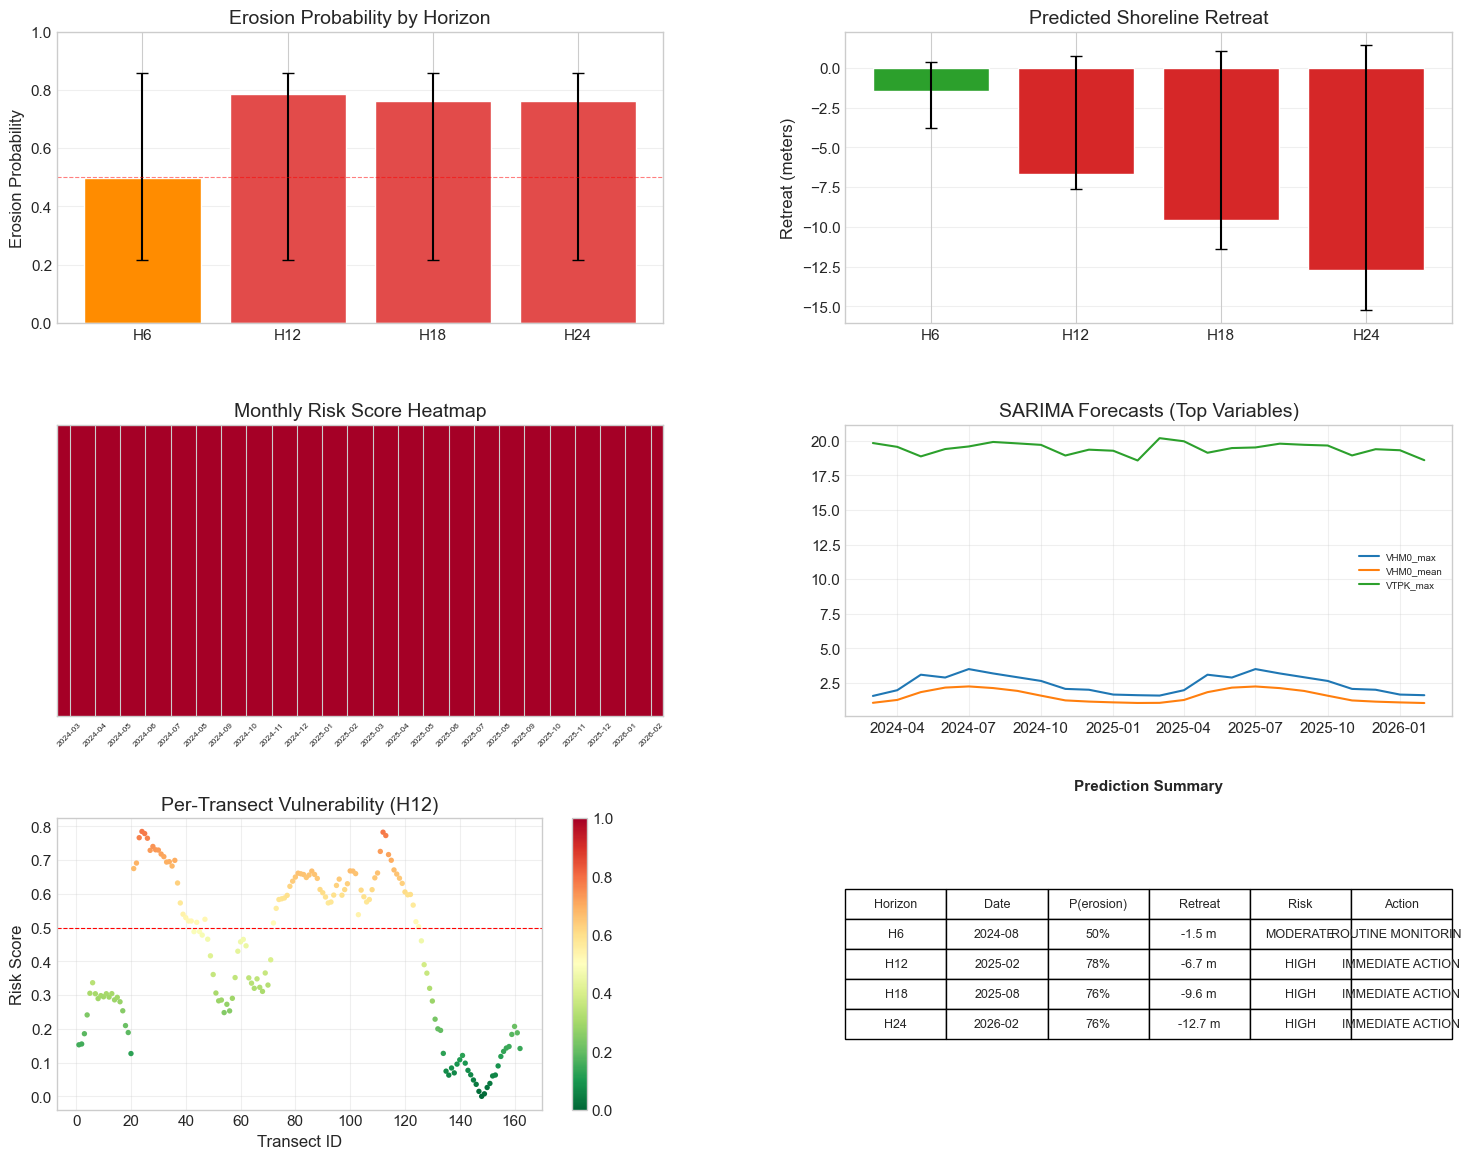

In [38]:
# =============================================================================
# Section 7.8 — Advanced Forecast Dashboard (6-panel)
# =============================================================================

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Panel 1: Erosion probability
ax1 = fig.add_subplot(gs[0, 0])
colors_mc = ['#E24B4A' if r['risk_category'] == 'HIGH'
             else '#FF8C00' if r['risk_category'] == 'MODERATE'
             else '#2ca02c' for _, r in mc_df.iterrows()]
ax1.bar(mc_df['horizon'], mc_df['mean_prob'], color=colors_mc, edgecolor='white')
yerr_lower_1 = (mc_df['mean_prob'] - mc_df['ci_lower_95']).clip(lower=0)
yerr_upper_1 = (mc_df['ci_upper_95'] - mc_df['mean_prob']).clip(lower=0)
ax1.errorbar(range(len(mc_df)), mc_df['mean_prob'],
             yerr=[yerr_lower_1, yerr_upper_1],
             fmt='none', color='black', capsize=4)
ax1.set_ylabel('Erosion Probability')
ax1.set_title('Erosion Probability by Horizon')
ax1.set_ylim(0, 1)
ax1.axhline(0.5, color='red', ls='--', lw=0.8, alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: Retreat predictions in meters
ax2 = fig.add_subplot(gs[0, 1])
action_colors = {'IMMEDIATE ACTION': '#d62728', 'ENHANCED MONITORING': '#ff7f0e',
                 'ROUTINE MONITORING': '#2ca02c', 'STANDARD OPERATIONS': '#1f77b4'}
retreat_colors = [action_colors.get(r['action_level'], '#888') for _, r in retreat_df.iterrows()]
ax2.bar(retreat_df['horizon'], retreat_df['retreat_m'], color=retreat_colors, edgecolor='white')
yerr_lower_2 = (retreat_df['retreat_m'] - retreat_df['retreat_low_95']).clip(lower=0)
yerr_upper_2 = (retreat_df['retreat_high_95'] - retreat_df['retreat_m']).clip(lower=0)
ax2.errorbar(range(len(retreat_df)), retreat_df['retreat_m'],
             yerr=[yerr_lower_2, yerr_upper_2],
             fmt='none', color='black', capsize=4)
ax2.set_ylabel('Retreat (meters)')
ax2.set_title('Predicted Shoreline Retreat')
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Monthly risk heatmap
ax3 = fig.add_subplot(gs[1, 0])
if len(monthly_risk_df) > 0:
    risk_vals = monthly_risk_df['risk_score'].values.reshape(1, -1)
    ax3.imshow(risk_vals, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=3)
    ax3.set_xticks(range(len(monthly_risk_df)))
    ax3.set_xticklabels(monthly_risk_df['date'].values, rotation=45, fontsize=6)
    ax3.set_yticks([])
    ax3.set_title('Monthly Risk Score Heatmap')
else:
    ax3.text(0.5, 0.5, 'No monthly risk data', ha='center', va='center')

# Panel 4: SARIMA forecasts with threshold
ax4 = fig.add_subplot(gs[1, 1])
for var_name, fc_df in list(sarima_forecasts.items())[:3]:
    fc_dates = pd.to_datetime(fc_df['date'])
    ax4.plot(fc_dates, fc_df['forecast'], '-', lw=1.5, label=var_name)
ax4.set_title('SARIMA Forecasts (Top Variables)')
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

# Panel 5: Per-transect vulnerability
ax5 = fig.add_subplot(gs[2, 0])
if 'risk_H12' in dsas_scored.columns:
    sc = ax5.scatter(dsas_scored['id'], dsas_scored['risk_H12'],
                     c=dsas_scored['risk_H12'], cmap='RdYlGn_r',
                     vmin=0, vmax=1, s=15, edgecolors='none')
    ax5.axhline(0.5, color='red', ls='--', lw=0.8)
    plt.colorbar(sc, ax=ax5)
ax5.set_xlabel('Transect ID')
ax5.set_ylabel('Risk Score')
ax5.set_title('Per-Transect Vulnerability (H12)')
ax5.grid(True, alpha=0.3)

# Panel 6: Summary table
ax6 = fig.add_subplot(gs[2, 1])
ax6.axis('off')
table_data = []
for _, r in retreat_df.iterrows():
    table_data.append([
        r['horizon'], r['target_date'],
        f"{r['erosion_probability']:.0%}",
        f"{r['retreat_m']:.1f} m",
        r['risk_category'], r['action_level']
    ])
tbl = ax6.table(cellText=table_data,
                colLabels=['Horizon', 'Date', 'P(erosion)', 'Retreat', 'Risk', 'Action'],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 1.8)
ax6.set_title('Prediction Summary', fontsize=11, fontweight='bold', pad=20)

plt.savefig('./figures/forecast_dashboard_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# =============================================================================
# Section 7.9 — Final prediction summary
# =============================================================================

print("=" * 60)
print("  ANALYSIS COMPLETE")
print("=" * 60)

print("\n" + "=" * 60)
print("  PREDICTION SUMMARY")
print("=" * 60)
for _, r in retreat_df.iterrows():
    print(f"  {r['horizon']} ({r['target_date']}): "
          f"P(erosion)={r['erosion_probability']:.0%}, "
          f"Retreat={r['retreat_m']:.1f}m, "
          f"Action: {r['action_level']}")

  ANALYSIS COMPLETE

  PREDICTION SUMMARY
  H6 (2024-08): P(erosion)=50%, Retreat=-1.5m, Action: ROUTINE MONITORING
  H12 (2025-02): P(erosion)=78%, Retreat=-6.7m, Action: IMMEDIATE ACTION
  H18 (2025-08): P(erosion)=76%, Retreat=-9.6m, Action: IMMEDIATE ACTION
  H24 (2026-02): P(erosion)=76%, Retreat=-12.7m, Action: IMMEDIATE ACTION


## Section 8 — Research-Grade Five-Class Monthly Threshold Workflow

This section supersedes the earlier annual binary erosion workflow.

The redesigned workflow now:

1. Uses the shoreline CSV **file name year** as the authoritative shoreline interval key.
2. Keeps the shoreline target in the full **five-class** form: `eroded_high`, `eroded_low`, `stable`, `accreted_low`, `accreted_high`.
3. Learns **monthly abnormal-pattern signatures** inside each shoreline interval instead of collapsing forcing into annual driver aggregates.
4. Estimates **erosion-side and accretion-side threshold ranges** with ordered five-class transition models.
5. Forecasts **future threshold ranges directly from historical threshold trajectories**, rather than forecasting driver values first.

Interpretation note: if a class is absent in the historical annual shoreline target, the notebook keeps that class in the ordered framework but reports its threshold as structurally unavailable rather than inventing unsupported values.

In [42]:
# =============================================================================
# Section 8.1 — Five-class monthly forcing signatures per shoreline interval
# =============================================================================

from scipy.stats import kruskal, spearmanr
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression, TheilSenRegressor
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.miscmodels.ordinal_model import OrderedModel

FIVE_CLASS_ORDER = ['eroded_high', 'eroded_low', 'stable', 'accreted_low', 'accreted_high']
CLASS_TO_CODE = {label: idx for idx, label in enumerate(FIVE_CLASS_ORDER)}
CODE_TO_CLASS = {idx: label for label, idx in CLASS_TO_CODE.items()}
MIN_INTERVAL_MONTHS = 8
SEASON_SPLIT_MONTHS = 6


def longest_run(mask):
    best = 0
    current = 0
    for flag in mask:
        if bool(flag):
            current += 1
            best = max(best, current)
        else:
            current = 0
    return int(best)


monthly_combined = monthly_combined.copy()
year_month_series = monthly_combined['year_month']
if pd.api.types.is_period_dtype(year_month_series):
    year_month_series = year_month_series.dt.to_timestamp(how='start')
else:
    year_month_series = pd.to_datetime(year_month_series).dt.to_period('M').dt.to_timestamp()
monthly_combined['year_month'] = year_month_series
monthly_combined = monthly_combined.sort_values('year_month').reset_index(drop=True)

shoreline_annual = shoreline_annual.copy()
shoreline_annual['Change_Class'] = pd.Categorical(
    shoreline_annual['Change_Class'],
    categories=FIVE_CLASS_ORDER,
    ordered=True,
)
shoreline_annual['class_code'] = shoreline_annual['Change_Class'].map(CLASS_TO_CODE).astype(int)
shoreline_annual['shoreline_score'] = shoreline_annual['class_code'] - 2

monthly_feature_cols = [
    column
    for column in monthly_combined.columns
    if column not in ['monsoon_year', 'year_month']
    and pd.api.types.is_numeric_dtype(monthly_combined[column])
]

monthly_climatology = {}
for feature_name in monthly_feature_cols:
    climatology = monthly_combined[['year_month', feature_name]].copy()
    climatology['calendar_month'] = climatology['year_month'].dt.month
    monthly_climatology[feature_name] = (
        climatology.groupby('calendar_month')[feature_name]
        .agg(mean='mean', std='std', q10=lambda series: series.quantile(0.10), q90=lambda series: series.quantile(0.90))
        .replace({'std': {0.0: np.nan}})
    )

interval_feature_rows = []
interval_month_lookup = {}

for shoreline_row in shoreline_annual.sort_values('year').itertuples(index=False):
    monsoon_year = int(shoreline_row.year)
    window_start = pd.Timestamp(f'{monsoon_year}-04-01')
    window_end = pd.Timestamp(f'{monsoon_year + 1}-03-01')
    interval_window = monthly_combined[
        monthly_combined['year_month'].between(window_start, window_end)
    ].copy()

    if len(interval_window) < MIN_INTERVAL_MONTHS:
        print(
            f"[SKIPPED] {shoreline_row.interval_label}: only {len(interval_window)} monthly records available"
        )
        continue

    interval_window = interval_window.sort_values('year_month').reset_index(drop=True)
    interval_month_lookup[monsoon_year] = interval_window.copy()

    feature_row = {
        'monsoon_year': monsoon_year,
        'interval_label': shoreline_row.interval_label,
        'n_months': int(len(interval_window)),
        'Change_Class': shoreline_row.Change_Class,
        'class_code': int(shoreline_row.class_code),
        'shoreline_score': int(shoreline_row.shoreline_score),
        'annual_NSM': float(shoreline_row.annual_NSM),
        'NSM_count': int(shoreline_row.NSM_count),
    }

    for feature_name in monthly_feature_cols:
        values = interval_window[feature_name].astype(float).to_numpy()
        if np.all(np.isnan(values)):
            continue

        calendar_months = interval_window['year_month'].dt.month.to_numpy()
        climatology = monthly_climatology[feature_name].reindex(calendar_months)
        climatology_mean = climatology['mean'].to_numpy(dtype=float)
        climatology_std = climatology['std'].to_numpy(dtype=float)

        anomalies = np.divide(
            values - climatology_mean,
            climatology_std,
            out=np.zeros_like(values, dtype=float),
            where=np.isfinite(climatology_std) & (climatology_std > 0),
        )
        anomalies = np.where(np.isfinite(anomalies), anomalies, 0.0)

        half_window = min(SEASON_SPLIT_MONTHS, max(len(values) // 2, 1))
        early_values = values[:half_window]
        late_values = values[-half_window:]
        time_index = np.arange(len(values), dtype=float)

        slope = 0.0
        if len(values) >= 2 and np.nanstd(values) > 0:
            slope = float(np.polyfit(time_index, values, 1)[0])

        feature_row[f'{feature_name}__p10'] = float(np.nanpercentile(values, 10))
        feature_row[f'{feature_name}__p50'] = float(np.nanpercentile(values, 50))
        feature_row[f'{feature_name}__p90'] = float(np.nanpercentile(values, 90))
        feature_row[f'{feature_name}__iqr'] = float(
            np.nanpercentile(values, 75) - np.nanpercentile(values, 25)
        )
        feature_row[f'{feature_name}__anom_mean'] = float(np.nanmean(anomalies))
        feature_row[f'{feature_name}__anom_peak_pos'] = float(np.nanmax(anomalies))
        feature_row[f'{feature_name}__anom_peak_neg'] = float(np.nanmin(anomalies))
        feature_row[f'{feature_name}__anom_abs_sum'] = float(np.nansum(np.abs(anomalies)))
        feature_row[f'{feature_name}__anom_pos_months'] = int(np.sum(anomalies >= 1.0))
        feature_row[f'{feature_name}__anom_neg_months'] = int(np.sum(anomalies <= -1.0))
        feature_row[f'{feature_name}__run_pos'] = longest_run(anomalies >= 1.0)
        feature_row[f'{feature_name}__run_neg'] = longest_run(anomalies <= -1.0)
        feature_row[f'{feature_name}__late_minus_early'] = float(
            np.nanmean(late_values) - np.nanmean(early_values)
        )
        feature_row[f'{feature_name}__slope'] = slope

    interval_feature_rows.append(feature_row)

analysis_df = pd.DataFrame(interval_feature_rows).sort_values('monsoon_year').reset_index(drop=True)
pattern_df = analysis_df.copy()

print('=== FIVE-CLASS MONTHLY PATTERN DATASET ===')
print(f'Intervals retained: {len(pattern_df)} / {len(shoreline_annual)}')
print(f'Monthly feature inputs: {len(monthly_feature_cols)}')
print(f'Pattern feature columns: {pattern_df.shape[1] - 8}')
print('\nClass counts:')
print(pattern_df['Change_Class'].value_counts().reindex(FIVE_CLASS_ORDER, fill_value=0).to_string())
print('\nInterval coverage:')
print(pattern_df[['monsoon_year', 'interval_label', 'n_months', 'Change_Class', 'annual_NSM']].to_string(index=False))

=== FIVE-CLASS MONTHLY PATTERN DATASET ===
Intervals retained: 12 / 12
Monthly feature inputs: 21
Pattern feature columns: 294

Class counts:
Change_Class
eroded_high      2
eroded_low       4
stable           3
accreted_low     3
accreted_high    0

Interval coverage:
 monsoon_year interval_label  n_months Change_Class  annual_NSM
         2012      2012-2013        12   eroded_low   -2.677923
         2013      2013-2014        12  eroded_high   -6.502348
         2014      2014-2015        12 accreted_low    4.247188
         2015      2015-2016        12   eroded_low   -3.300930
         2016      2016-2017        12 accreted_low    3.720458
         2017      2017-2018        12 accreted_low    1.870692
         2018      2018-2019        12   eroded_low   -4.807674
         2019      2019-2020        12   eroded_low   -3.760938
         2020      2020-2021        12       stable    1.629167
         2021      2021-2022        12       stable    1.731679
         2022      2022-20

In [44]:
# =============================================================================
# Section 8.2 — Five-class monthly pattern screening and recognition models
# =============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut

PATTERN_META_COLS = [
    'monsoon_year',
    'interval_label',
    'n_months',
    'Change_Class',
    'class_code',
    'shoreline_score',
    'annual_NSM',
    'NSM_count',
]
MAX_FEATURES_PER_DRIVER = 2
MAX_SELECTED_FEATURES = 14

pattern_feature_cols = [column for column in pattern_df.columns if column not in PATTERN_META_COLS]
present_class_codes = sorted(pattern_df['class_code'].unique())
present_class_labels = [CODE_TO_CLASS[code] for code in present_class_codes]

feature_screening_rows = []
mi_input = pattern_df[pattern_feature_cols].copy()
mi_input = mi_input.replace([np.inf, -np.inf], np.nan)
mi_input = mi_input.fillna(mi_input.median(numeric_only=True))
mi_scores = mutual_info_classif(
    mi_input,
    pattern_df['class_code'],
    random_state=42,
    discrete_features=False,
)
mi_lookup = dict(zip(pattern_feature_cols, mi_scores))

for feature_name in pattern_feature_cols:
    feature_values = pattern_df[feature_name].astype(float)
    valid_mask = feature_values.notna()
    if valid_mask.sum() < 6 or feature_values.nunique(dropna=True) < 3:
        continue

    rho, rho_p = spearmanr(
        feature_values[valid_mask],
        pattern_df.loc[valid_mask, 'shoreline_score'],
        nan_policy='omit',
    )
    if not np.isfinite(rho):
        rho, rho_p = 0.0, 1.0

    class_groups = []
    for class_label in present_class_labels:
        group_values = pattern_df.loc[pattern_df['Change_Class'] == class_label, feature_name].dropna().values
        if len(group_values) > 0:
            class_groups.append(group_values)

    if len(class_groups) >= 2:
        kw_stat, kw_p = kruskal(*class_groups)
    else:
        kw_stat, kw_p = np.nan, 1.0

    composite_score = (
        2.0 * abs(float(rho))
        + float(mi_lookup.get(feature_name, 0.0))
        + max(0.0, -np.log10(float(kw_p) + 1e-12))
    )

    feature_screening_rows.append({
        'feature': feature_name,
        'driver': feature_name.split('__')[0],
        'spearman_rho': float(rho),
        'spearman_p': float(rho_p) if np.isfinite(rho_p) else 1.0,
        'kruskal_h': float(kw_stat) if np.isfinite(kw_stat) else np.nan,
        'kruskal_p': float(kw_p) if np.isfinite(kw_p) else 1.0,
        'mutual_info': float(mi_lookup.get(feature_name, 0.0)),
        'composite_score': float(composite_score),
    })

screening_df = (
    pd.DataFrame(feature_screening_rows)
    .sort_values(['composite_score', 'mutual_info', 'kruskal_h'], ascending=[False, False, False])
    .reset_index(drop=True)
)

selected_features = []
driver_feature_counts = {}
for screening_row in screening_df.itertuples(index=False):
    driver_name = screening_row.driver
    if driver_feature_counts.get(driver_name, 0) >= MAX_FEATURES_PER_DRIVER:
        continue
    selected_features.append(screening_row.feature)
    driver_feature_counts[driver_name] = driver_feature_counts.get(driver_name, 0) + 1
    if len(selected_features) >= min(MAX_SELECTED_FEATURES, len(screening_df)):
        break

if len(selected_features) < 6:
    selected_features = screening_df.head(min(6, len(screening_df)))['feature'].tolist()

feature_matrix = pattern_df[selected_features].replace([np.inf, -np.inf], np.nan)
feature_matrix = feature_matrix.fillna(feature_matrix.median(numeric_only=True))
X_pattern = feature_matrix.to_numpy(dtype=float)
y_pattern = pattern_df['class_code'].to_numpy(dtype=int)

loo = LeaveOneOut()
loo_rows = []
confusion_labels = present_class_codes
confusion_names = [CODE_TO_CLASS[code] for code in confusion_labels]


def aligned_probabilities(model, x_test):
    probabilities = np.zeros(len(FIVE_CLASS_ORDER), dtype=float)
    if hasattr(model, 'predict_proba'):
        model_probabilities = model.predict_proba(x_test)[0]
        for class_code, class_probability in zip(model.classes_, model_probabilities):
            probabilities[int(class_code)] = float(class_probability)
    else:
        predicted_code = int(model.predict(x_test)[0])
        probabilities[predicted_code] = 1.0
    return probabilities


for train_index, test_index in loo.split(X_pattern):
    X_train = X_pattern[train_index]
    X_test = X_pattern[test_index]
    y_train = y_pattern[train_index]
    y_test = y_pattern[test_index]

    models_to_average = []

    logistic_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            solver='lbfgs',
            max_iter=4000,
            C=0.75,
            random_state=42,
        )),
    ])
    try:
        logistic_model.fit(X_train, y_train)
        models_to_average.append(aligned_probabilities(logistic_model, X_test))
    except Exception:
        pass

    forest_model = RandomForestClassifier(
        n_estimators=500,
        max_depth=4,
        min_samples_leaf=1,
        class_weight='balanced_subsample',
        random_state=42,
    )
    try:
        forest_model.fit(X_train, y_train)
        models_to_average.append(aligned_probabilities(forest_model, X_test))
    except Exception:
        pass

    if not models_to_average:
        fallback_probabilities = np.zeros(len(FIVE_CLASS_ORDER), dtype=float)
        fallback_probabilities[int(pd.Series(y_train).mode().iloc[0])] = 1.0
        models_to_average.append(fallback_probabilities)

    mean_probabilities = np.mean(models_to_average, axis=0)
    predicted_code = int(np.argmax(mean_probabilities))

    loo_rows.append({
        'monsoon_year': int(pattern_df.iloc[test_index[0]]['monsoon_year']),
        'actual_code': int(y_test[0]),
        'predicted_code': predicted_code,
        'actual_class': CODE_TO_CLASS[int(y_test[0])],
        'predicted_class': CODE_TO_CLASS[predicted_code],
        'correct': bool(predicted_code == int(y_test[0])),
        'top_probability': float(mean_probabilities[predicted_code]),
    })

pattern_skill_df = pd.DataFrame(loo_rows).sort_values('monsoon_year').reset_index(drop=True)
pattern_balanced_accuracy = balanced_accuracy_score(
    pattern_skill_df['actual_code'],
    pattern_skill_df['predicted_code'],
)
pattern_macro_f1 = f1_score(
    pattern_skill_df['actual_code'],
    pattern_skill_df['predicted_code'],
    average='macro',
    labels=confusion_labels,
)
pattern_confusion = confusion_matrix(
    pattern_skill_df['actual_code'],
    pattern_skill_df['predicted_code'],
    labels=confusion_labels,
)

pattern_models = {
    'multinomial_logit': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            class_weight='balanced',
            solver='lbfgs',
            max_iter=4000,
            C=0.75,
            random_state=42,
        )),
    ]),
    'random_forest': RandomForestClassifier(
        n_estimators=500,
        max_depth=4,
        min_samples_leaf=1,
        class_weight='balanced_subsample',
        random_state=42,
    ),
}

for model_name, model in pattern_models.items():
    model.fit(X_pattern, y_pattern)


def predict_pattern_probabilities(feature_frame):
    feature_frame = feature_frame[selected_features].replace([np.inf, -np.inf], np.nan)
    feature_frame = feature_frame.fillna(feature_matrix.median(numeric_only=True))
    x_values = feature_frame.to_numpy(dtype=float)
    averaged = []
    for model in pattern_models.values():
        model_probabilities = []
        if hasattr(model, 'predict_proba'):
            raw_probabilities = model.predict_proba(x_values)
            for row_probabilities in raw_probabilities:
                aligned = np.zeros(len(FIVE_CLASS_ORDER), dtype=float)
                for class_code, class_probability in zip(model.classes_, row_probabilities):
                    aligned[int(class_code)] = float(class_probability)
                model_probabilities.append(aligned)
        else:
            predicted_codes = model.predict(x_values)
            for predicted_code in predicted_codes:
                aligned = np.zeros(len(FIVE_CLASS_ORDER), dtype=float)
                aligned[int(predicted_code)] = 1.0
                model_probabilities.append(aligned)
        averaged.append(np.vstack(model_probabilities))
    return np.mean(averaged, axis=0)

significant_features = selected_features.copy()

print('=== FIVE-CLASS FEATURE SCREENING ===')
print(f'Available target classes: {present_class_labels}')
if 'accreted_high' not in present_class_labels:
    print('NOTE: No historical accreted_high interval exists in the annual shoreline target, so that extreme class can be tracked structurally but not learned directly from annual labels.')
print('\nTop screened features:')
print(screening_df.head(20).to_string(index=False))
print('\nSelected pattern features:')
for feature_name in selected_features:
    print(f'  - {feature_name}')

print('\n=== FIVE-CLASS PATTERN RECOGNITION SKILL (LOOCV) ===')
print(pattern_skill_df.to_string(index=False))
print(f'\nBalanced accuracy: {pattern_balanced_accuracy:.3f}')
print(f'Macro F1:          {pattern_macro_f1:.3f}')
print('\nConfusion matrix (rows=actual, cols=predicted):')
print(pd.DataFrame(pattern_confusion, index=confusion_names, columns=confusion_names).to_string())

=== FIVE-CLASS FEATURE SCREENING ===
Available target classes: ['eroded_high', 'eroded_low', 'stable', 'accreted_low']
NOTE: No historical accreted_high interval exists in the annual shoreline target, so that extreme class can be tracked structurally but not learned directly from annual labels.

Top screened features:
                             feature              driver  spearman_rho  spearman_p  kruskal_h  kruskal_p  mutual_info  composite_score
            VSDY_mean__anom_peak_pos           VSDY_mean     -0.901075    0.000063   9.147436   0.027394     0.414223         3.778724
                      VSDX_mean__p10           VSDX_mean      0.749086    0.005047   8.423077   0.038031     0.486604         3.404636
                  VSDX_mean__run_pos           VSDX_mean      0.559000    0.058831   7.493386   0.057729     1.030327         3.386937
                  VSDY_mean__run_pos           VSDY_mean     -0.846714    0.000512   8.190379   0.042237     0.261974         3.329711
     

In [ ]:
# =============================================================================
# Section 8.3 — Ordered five-class threshold ranges from monthly patterns
# =============================================================================

import warnings

from statsmodels.tools.sm_exceptions import ConvergenceWarning, HessianInversionWarning

BOUNDARY_NAMES = {
    (0, 1): 'severe_erosion',
    (1, 2): 'erosion_onset',
    (2, 3): 'accretion_onset',
    (3, 4): 'strong_accretion',
}
N_THRESHOLD_BOOT = 150
GRID_SIZE = 401


screening_lookup = screening_df.set_index('feature').to_dict(orient='index')


def empirical_transition_fallback(oriented_values, original_codes):
    medians = {}
    for class_code in sorted(np.unique(original_codes)):
        class_values = oriented_values[original_codes == class_code]
        if len(class_values) > 0:
            medians[int(class_code)] = float(np.nanmedian(class_values))

    thresholds = {}
    ordered_codes = sorted(medians)
    for left_code, right_code in zip(ordered_codes[:-1], ordered_codes[1:]):
        thresholds[(left_code, right_code)] = (medians[left_code] + medians[right_code]) / 2.0
    return thresholds



def estimate_ordered_thresholds_core(feature_values, class_codes):
    working_df = pd.DataFrame({'feature': feature_values, 'class_code': class_codes})
    working_df = working_df.replace([np.inf, -np.inf], np.nan).dropna()

    if len(working_df) < 8 or working_df['class_code'].nunique() < 3 or working_df['feature'].nunique() < 5:
        return None

    rho, _ = spearmanr(working_df['feature'], working_df['class_code'], nan_policy='omit')
    if not np.isfinite(rho):
        rho = 0.0

    direction = 'direct' if rho >= 0 else 'inverse'
    oriented_values = working_df['feature'].to_numpy(dtype=float)
    if direction == 'inverse':
        oriented_values = -oriented_values

    original_codes = working_df['class_code'].astype(int).to_numpy()
    unique_codes = sorted(np.unique(original_codes))
    fit_code_map = {class_code: idx for idx, class_code in enumerate(unique_codes)}
    fit_codes = np.array([fit_code_map[class_code] for class_code in original_codes], dtype=int)

    thresholds_oriented = empirical_transition_fallback(oriented_values, original_codes)
    method_used = 'empirical_midpoint'

    try:
        ordered_model = OrderedModel(
            fit_codes,
            pd.DataFrame({'feature': oriented_values}),
            distr='logit',
        )
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=HessianInversionWarning)
            warnings.filterwarnings('ignore', category=ConvergenceWarning)
            ordered_result = ordered_model.fit(method='bfgs', disp=False)

        oriented_min = float(np.nanmin(oriented_values))
        oriented_max = float(np.nanmax(oriented_values))
        oriented_range = max(oriented_max - oriented_min, 1e-6)
        grid = np.linspace(
            oriented_min - 0.20 * oriented_range,
            oriented_max + 0.20 * oriented_range,
            GRID_SIZE,
        )
        probability_grid = ordered_model.predict(
            ordered_result.params,
            exog=pd.DataFrame({'feature': grid}),
        )
        probability_grid = np.asarray(probability_grid)

        thresholds_oriented = {}
        for fit_index, (left_code, right_code) in enumerate(zip(unique_codes[:-1], unique_codes[1:])):
            difference = probability_grid[:, fit_index] - probability_grid[:, fit_index + 1]
            thresholds_oriented[(left_code, right_code)] = float(grid[int(np.argmin(np.abs(difference)))])
        method_used = 'ordered_logit'
    except Exception:
        pass

    thresholds_original = {
        boundary: (value if direction == 'direct' else -value)
        for boundary, value in thresholds_oriented.items()
    }

    class_bands = {}
    for class_label, class_code in CLASS_TO_CODE.items():
        class_values = working_df.loc[working_df['class_code'] == class_code, 'feature'].dropna().to_numpy(dtype=float)
        if len(class_values) == 0:
            class_bands[class_label] = {'count': 0, 'q25': np.nan, 'median': np.nan, 'q75': np.nan}
            continue
        class_bands[class_label] = {
            'count': int(len(class_values)),
            'q25': float(np.nanpercentile(class_values, 25)),
            'median': float(np.nanpercentile(class_values, 50)),
            'q75': float(np.nanpercentile(class_values, 75)),
        }

    return {
        'rho': float(rho),
        'direction': direction,
        'unique_codes': unique_codes,
        'thresholds': thresholds_original,
        'class_bands': class_bands,
        'method': method_used,
    }



def fit_ordered_thresholds(feature_values, class_codes, n_boot=N_THRESHOLD_BOOT, random_state=42):
    fit_result = estimate_ordered_thresholds_core(feature_values, class_codes)
    if fit_result is None:
        return None

    bootstrap_store = {boundary: [] for boundary in BOUNDARY_NAMES}
    feature_values = np.asarray(feature_values, dtype=float)
    class_codes = np.asarray(class_codes, dtype=int)
    valid_mask = np.isfinite(feature_values)
    feature_values = feature_values[valid_mask]
    class_codes = class_codes[valid_mask]

    rng = np.random.default_rng(random_state)
    for _ in range(n_boot):
        sample_index = rng.choice(len(feature_values), len(feature_values), replace=True)
        boot_result = estimate_ordered_thresholds_core(feature_values[sample_index], class_codes[sample_index])
        if boot_result is None:
            continue
        for boundary, estimate in boot_result['thresholds'].items():
            if boundary in bootstrap_store and np.isfinite(estimate):
                bootstrap_store[boundary].append(float(estimate))

    boundary_intervals = {}
    for boundary, boundary_name in BOUNDARY_NAMES.items():
        samples = bootstrap_store.get(boundary, [])
        if samples:
            boundary_intervals[boundary_name] = {
                'estimate': float(fit_result['thresholds'].get(boundary, np.nan)),
                'low_95': float(np.nanpercentile(samples, 2.5)),
                'high_95': float(np.nanpercentile(samples, 97.5)),
                'n_boot': int(len(samples)),
            }
        else:
            boundary_intervals[boundary_name] = {
                'estimate': float(fit_result['thresholds'].get(boundary, np.nan)),
                'low_95': np.nan,
                'high_95': np.nan,
                'n_boot': 0,
            }

    fit_result['boundary_intervals'] = boundary_intervals
    return fit_result


threshold_results_by_feature = {}
threshold_rows = []

for feature_name in significant_features:
    feature_fit = fit_ordered_thresholds(pattern_df[feature_name].to_numpy(dtype=float), pattern_df['class_code'].to_numpy(dtype=int))
    if feature_fit is None:
        continue

    threshold_results_by_feature[feature_name] = feature_fit
    screening_info = screening_lookup.get(feature_name, {})
    threshold_row = {
        'feature': feature_name,
        'driver': feature_name.split('__')[0],
        'screening_score': screening_info.get('composite_score', np.nan),
        'spearman_rho': feature_fit['rho'],
        'direction_to_accretion': feature_fit['direction'],
        'threshold_method': feature_fit['method'],
    }

    for boundary_name, boundary_stats in feature_fit['boundary_intervals'].items():
        threshold_row[f'{boundary_name}_threshold'] = boundary_stats['estimate']
        threshold_row[f'{boundary_name}_low_95'] = boundary_stats['low_95']
        threshold_row[f'{boundary_name}_high_95'] = boundary_stats['high_95']
        threshold_row[f'{boundary_name}_boot_n'] = boundary_stats['n_boot']

    for class_label in FIVE_CLASS_ORDER:
        band = feature_fit['class_bands'][class_label]
        threshold_row[f'{class_label}_count'] = band['count']
        threshold_row[f'{class_label}_q25'] = band['q25']
        threshold_row[f'{class_label}_median'] = band['median']
        threshold_row[f'{class_label}_q75'] = band['q75']

    threshold_rows.append(threshold_row)

threshold_ranges_df = (
    pd.DataFrame(threshold_rows)
    .sort_values(['screening_score', 'spearman_rho'], ascending=[False, False])
    .reset_index(drop=True)
)

print('=== FIVE-CLASS THRESHOLD RANGES ===')
print('Transition thresholds are estimated directly from monthly-pattern features, not from annual forcing aggregates.')
print(threshold_ranges_df[[
    'feature',
    'direction_to_accretion',
    'severe_erosion_threshold',
    'erosion_onset_threshold',
    'accretion_onset_threshold',
    'strong_accretion_threshold',
]].to_string(index=False))

print('\n=== CLASS BAND SUMMARY (Q25-MEDIAN-Q75) ===')
for threshold_row in threshold_ranges_df.itertuples(index=False):
    print(f"\n{threshold_row.feature} [{threshold_row.direction_to_accretion}]")
    for class_label in FIVE_CLASS_ORDER:
        q25 = getattr(threshold_row, f'{class_label}_q25')
        q50 = getattr(threshold_row, f'{class_label}_median')
        q75 = getattr(threshold_row, f'{class_label}_q75')
        class_count = getattr(threshold_row, f'{class_label}_count')
        if class_count == 0:
            print(f'  {class_label:15s}: no historical annual interval')
        else:
            print(f'  {class_label:15s}: n={class_count:2d}  q25={q25:9.4f}  median={q50:9.4f}  q75={q75:9.4f}')

C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
C:\Users\kanja\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
C:\Users\kanja\AppData\Roaming\Pytho

=== FIVE-CLASS THRESHOLD RANGES ===
Transition thresholds are estimated directly from monthly-pattern features, not from annual forcing aggregates.
                             feature direction_to_accretion  severe_erosion_threshold  erosion_onset_threshold  accretion_onset_threshold  strong_accretion_threshold
            VSDY_mean__anom_peak_pos                inverse                  0.286946                 2.696075                   2.696075                         NaN
                      VSDX_mean__p10                 direct                 -0.006221                 0.000467                   0.003068                         NaN
                      VMDR_mean__p50                 direct                187.259992               200.489813                 204.442626                         NaN
            VHM0_mean__anom_peak_neg                 direct                 -2.006796                -1.464250                  -0.895557                         NaN
              zos_max_

In [46]:
# =============================================================================
# Section 8.4 — Forecast future threshold ranges directly from threshold history
# =============================================================================

THRESHOLD_HISTORY_MIN_YEARS = 6
THRESHOLD_FORECAST_BOOT = 80

threshold_history_rows = []
observed_monsoon_years = sorted(pattern_df['monsoon_year'].unique())

for feature_name in significant_features:
    for end_year in observed_monsoon_years:
        subset_df = pattern_df[pattern_df['monsoon_year'] <= end_year]
        if len(subset_df) < THRESHOLD_HISTORY_MIN_YEARS or subset_df['class_code'].nunique() < 3:
            continue

        history_fit = fit_ordered_thresholds(
            subset_df[feature_name].to_numpy(dtype=float),
            subset_df['class_code'].to_numpy(dtype=int),
            n_boot=0,
        )
        if history_fit is None:
            continue

        for boundary_name, boundary_stats in history_fit['boundary_intervals'].items():
            estimate = boundary_stats['estimate']
            if not np.isfinite(estimate):
                continue
            threshold_history_rows.append({
                'feature': feature_name,
                'boundary': boundary_name,
                'end_year': int(end_year),
                'decimal_year': float(end_year) + 0.50,
                'threshold': float(estimate),
                'direction_to_accretion': history_fit['direction'],
            })

threshold_history_df = pd.DataFrame(threshold_history_rows)

forecast_anchor = pd.Timestamp(monthly_combined['year_month'].max())
threshold_horizons = {
    'H6': forecast_anchor + pd.DateOffset(months=6),
    'H12': forecast_anchor + pd.DateOffset(months=12),
    'H18': forecast_anchor + pd.DateOffset(months=18),
    'H24': forecast_anchor + pd.DateOffset(months=24),
}
forecast_decimal_years = {
    horizon: (timestamp.year + (timestamp.month - 1) / 12.0)
    for horizon, timestamp in threshold_horizons.items()
}

future_threshold_rows = []
threshold_trend_models = {}

if len(threshold_history_df) > 0:
    grouped_history = threshold_history_df.groupby(['feature', 'boundary'], sort=False)
    for (feature_name, boundary_name), history_group in grouped_history:
        history_group = history_group.sort_values('decimal_year').reset_index(drop=True)
        if len(history_group) < 4 or history_group['decimal_year'].nunique() < 3:
            continue

        x_history = history_group['decimal_year'].to_numpy(dtype=float).reshape(-1, 1)
        y_history = history_group['threshold'].to_numpy(dtype=float)
        trend_model = TheilSenRegressor(random_state=42)
        trend_model.fit(x_history, y_history)

        threshold_trend_models[(feature_name, boundary_name)] = trend_model
        x_future = np.array(list(forecast_decimal_years.values()), dtype=float).reshape(-1, 1)
        future_estimates = trend_model.predict(x_future)

        rng = np.random.default_rng(42)
        bootstrap_predictions = []
        for _ in range(THRESHOLD_FORECAST_BOOT):
            sample_index = rng.choice(len(history_group), len(history_group), replace=True)
            x_sample = x_history[sample_index]
            y_sample = y_history[sample_index]
            if np.unique(x_sample.ravel()).size < 2:
                continue
            try:
                boot_model = TheilSenRegressor(random_state=42)
                boot_model.fit(x_sample, y_sample)
                bootstrap_predictions.append(boot_model.predict(x_future))
            except Exception:
                continue

        if bootstrap_predictions:
            bootstrap_predictions = np.vstack(bootstrap_predictions)
            low_bounds = np.nanpercentile(bootstrap_predictions, 2.5, axis=0)
            high_bounds = np.nanpercentile(bootstrap_predictions, 97.5, axis=0)
        else:
            low_bounds = np.full(len(threshold_horizons), np.nan)
            high_bounds = np.full(len(threshold_horizons), np.nan)

        direction_label = history_group['direction_to_accretion'].iloc[-1]
        for forecast_index, (horizon_name, target_timestamp) in enumerate(threshold_horizons.items()):
            future_threshold_rows.append({
                'feature': feature_name,
                'boundary': boundary_name,
                'horizon': horizon_name,
                'target_date': target_timestamp.strftime('%Y-%m'),
                'predicted_threshold': float(future_estimates[forecast_index]),
                'low_95': float(low_bounds[forecast_index]) if np.isfinite(low_bounds[forecast_index]) else np.nan,
                'high_95': float(high_bounds[forecast_index]) if np.isfinite(high_bounds[forecast_index]) else np.nan,
                'direction_to_accretion': direction_label,
                'history_points': int(len(history_group)),
            })

future_threshold_forecasts_df = pd.DataFrame(future_threshold_rows)

if len(future_threshold_forecasts_df) > 0:
    future_threshold_ranges_df = (
        future_threshold_forecasts_df
        .pivot_table(
            index=['feature', 'horizon', 'target_date', 'direction_to_accretion'],
            columns='boundary',
            values='predicted_threshold',
            aggfunc='first',
        )
        .reset_index()
    )
    future_threshold_ranges_df.columns.name = None
else:
    future_threshold_ranges_df = pd.DataFrame(
        columns=['feature', 'horizon', 'target_date', 'direction_to_accretion'] + list(BOUNDARY_NAMES.values())
    )

print('=== THRESHOLD HISTORY COVERAGE ===')
if len(threshold_history_df) == 0:
    print('No threshold history could be constructed from the current five-class pattern dataset.')
else:
    history_summary = (
        threshold_history_df.groupby(['feature', 'boundary'])['end_year']
        .agg(['min', 'max', 'count'])
        .reset_index()
        .sort_values(['feature', 'boundary'])
    )
    print(history_summary.to_string(index=False))

print('\n=== FUTURE THRESHOLD FORECASTS ===')
if len(future_threshold_forecasts_df) == 0:
    print('No future threshold forecasts available. Historical threshold trajectories were too short.')
else:
    print(future_threshold_forecasts_df.to_string(index=False))

print('\n=== FUTURE THRESHOLD RANGE SUMMARY ===')
if len(future_threshold_ranges_df) == 0:
    print('No threshold range summary available.')
else:
    print(future_threshold_ranges_df.to_string(index=False))

=== THRESHOLD HISTORY COVERAGE ===
                             feature        boundary  min  max  count
                VHM0_mean__anom_mean accretion_onset 2020 2023      4
                VHM0_mean__anom_mean   erosion_onset 2020 2023      4
                VHM0_mean__anom_mean  severe_erosion 2019 2023      5
            VHM0_mean__anom_peak_neg accretion_onset 2020 2023      4
            VHM0_mean__anom_peak_neg   erosion_onset 2020 2023      4
            VHM0_mean__anom_peak_neg  severe_erosion 2019 2023      5
                      VMDR_mean__p50 accretion_onset 2020 2023      4
                      VMDR_mean__p50   erosion_onset 2020 2023      4
                      VMDR_mean__p50  severe_erosion 2019 2023      5
                      VSDX_mean__p10 accretion_onset 2020 2023      4
                      VSDX_mean__p10   erosion_onset 2020 2023      4
                      VSDX_mean__p10  severe_erosion 2019 2023      5
            VSDY_mean__anom_peak_pos accretion_onset 20

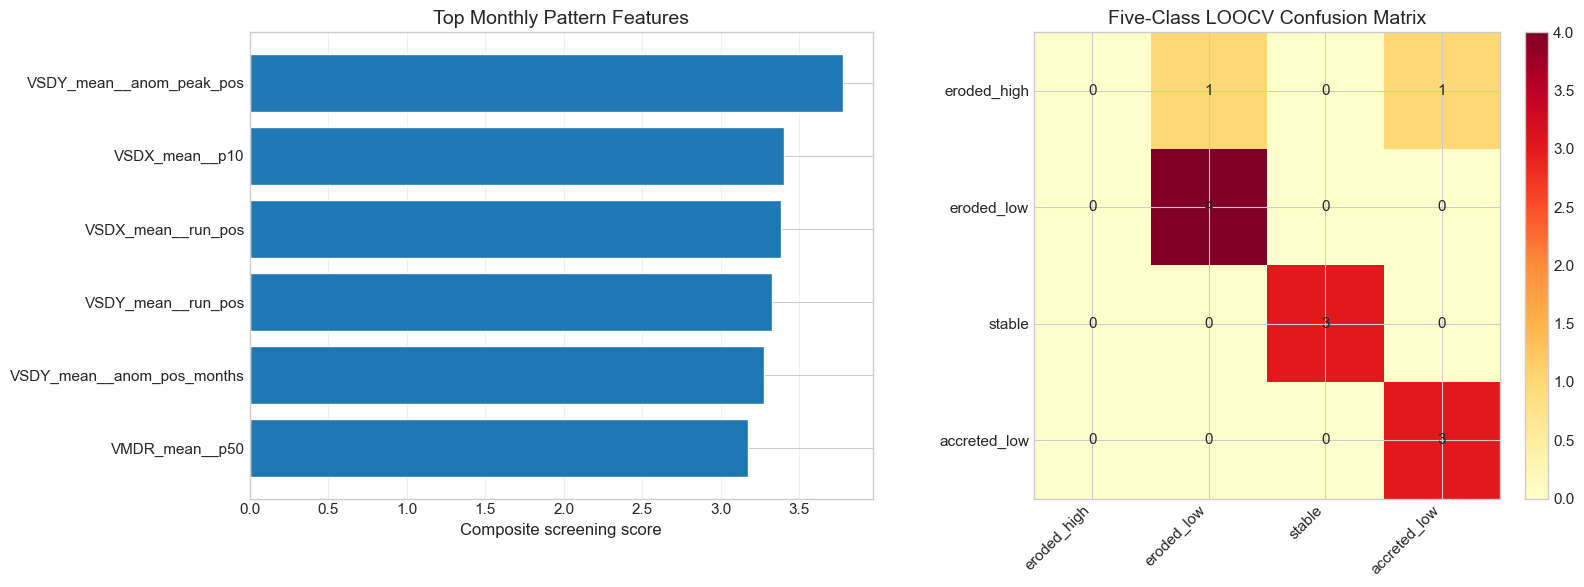

=== FIVE-CLASS MONTHLY THRESHOLD WORKFLOW COMPLETE ===
Pattern dataset rows: 12
Selected pattern features: 14
Balanced accuracy (LOOCV): 0.750
Macro F1 (LOOCV):          0.687
Forecast anchor month:     2024-02

Exported files:
  - outputs\five_class_monthly_feature_screening.csv
  - outputs\five_class_pattern_skill.csv
  - outputs\five_class_threshold_ranges.csv
  - outputs\five_class_threshold_history.csv
  - outputs\future_threshold_forecasts.csv
  - outputs\future_threshold_range_summary.csv
  - outputs\five_class_monthly_pattern_dataset.csv

Future threshold range summary (top rows):
                 feature horizon target_date direction_to_accretion  accretion_onset  erosion_onset  severe_erosion
    VHM0_mean__anom_mean     H12     2025-02                 direct         0.900536      -0.457160       -0.648412
    VHM0_mean__anom_mean     H18     2025-08                 direct         1.035151      -0.593630       -0.624269
    VHM0_mean__anom_mean     H24     2026-02            

In [47]:
# =============================================================================
# Section 8.5 — Export, visualization, and final five-class summary
# =============================================================================

from pathlib import Path

OUTPUT_DIR = Path('./outputs')
FIGURE_DIR = Path('./figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

screening_df.to_csv(OUTPUT_DIR / 'five_class_monthly_feature_screening.csv', index=False)
pattern_skill_df.to_csv(OUTPUT_DIR / 'five_class_pattern_skill.csv', index=False)
threshold_ranges_df.to_csv(OUTPUT_DIR / 'five_class_threshold_ranges.csv', index=False)
threshold_history_df.to_csv(OUTPUT_DIR / 'five_class_threshold_history.csv', index=False)
future_threshold_forecasts_df.to_csv(OUTPUT_DIR / 'future_threshold_forecasts.csv', index=False)
future_threshold_ranges_df.to_csv(OUTPUT_DIR / 'future_threshold_range_summary.csv', index=False)
pattern_df.to_csv(OUTPUT_DIR / 'five_class_monthly_pattern_dataset.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_features = screening_df.head(min(6, len(screening_df)))['feature'].tolist()
plot_scores = screening_df.head(min(6, len(screening_df)))['composite_score'].to_numpy(dtype=float)
axes[0].barh(plot_features[::-1], plot_scores[::-1], color='#1f77b4', edgecolor='white')
axes[0].set_title('Top Monthly Pattern Features')
axes[0].set_xlabel('Composite screening score')
axes[0].grid(True, alpha=0.3, axis='x')

if len(pattern_confusion) > 0:
    im = axes[1].imshow(pattern_confusion, cmap='YlOrRd')
    axes[1].set_xticks(range(len(confusion_names)))
    axes[1].set_xticklabels(confusion_names, rotation=45, ha='right')
    axes[1].set_yticks(range(len(confusion_names)))
    axes[1].set_yticklabels(confusion_names)
    axes[1].set_title('Five-Class LOOCV Confusion Matrix')
    for row_index in range(pattern_confusion.shape[0]):
        for col_index in range(pattern_confusion.shape[1]):
            axes[1].text(col_index, row_index, int(pattern_confusion[row_index, col_index]), ha='center', va='center')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
else:
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'five_class_monthly_workflow_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== FIVE-CLASS MONTHLY THRESHOLD WORKFLOW COMPLETE ===')
print(f'Pattern dataset rows: {len(pattern_df)}')
print(f'Selected pattern features: {len(significant_features)}')
print(f'Balanced accuracy (LOOCV): {pattern_balanced_accuracy:.3f}')
print(f'Macro F1 (LOOCV):          {pattern_macro_f1:.3f}')
print(f'Forecast anchor month:     {forecast_anchor.strftime("%Y-%m")}')
print('\nExported files:')
print(f'  - {OUTPUT_DIR / "five_class_monthly_feature_screening.csv"}')
print(f'  - {OUTPUT_DIR / "five_class_pattern_skill.csv"}')
print(f'  - {OUTPUT_DIR / "five_class_threshold_ranges.csv"}')
print(f'  - {OUTPUT_DIR / "five_class_threshold_history.csv"}')
print(f'  - {OUTPUT_DIR / "future_threshold_forecasts.csv"}')
print(f'  - {OUTPUT_DIR / "future_threshold_range_summary.csv"}')
print(f'  - {OUTPUT_DIR / "five_class_monthly_pattern_dataset.csv"}')

print('\nFuture threshold range summary (top rows):')
if len(future_threshold_ranges_df) == 0:
    print('  No future threshold ranges could be forecast from the available historical threshold trajectories.')
else:
    print(future_threshold_ranges_df.head(20).to_string(index=False))

if 'accreted_high' not in present_class_labels:
    print('\nMethod note: the annual shoreline target has no accreted_high interval, so strong accretion thresholds remain unsupported by annual training data and are left blank instead of being guessed.')